dane są pozmieniane ale nie są przygotowane do treningu (poprzerzucać wartości kolumn do meczy bo jest teraz wiersz z emczem-kursami na niego i wynikiem meczu i statystyk po tym meczu)

# 1. Initial setup

Import of libraries, global parameters.

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import json

In [94]:
df1 = pd.read_csv(r"..\data\extracted_data\20_21_final.csv")
df2 = pd.read_csv(r"..\data\extracted_data\21_22_final.csv")
df3 = pd.read_csv(r"..\data\extracted_data\22_23_final.csv")
df4 = pd.read_csv(r"..\data\extracted_data\23_24_final.csv")

df_list = [df1, df2, df3, df4]

In [95]:
joined_df = pd.concat(df_list, ignore_index=True)

# 2. Data exploration

## General overview

In this chapter, we take an initial look at the football match data that forms the foundation of our analysis. We'll explore the structure of the dataset, review the types of information it contains, and highlight key statistics. This overview sets the stage for deeper analytical work in the following chapters by helping us understand the basic characteristics and quality of the data.

Leagues in the collected dataset

In [96]:
for league in joined_df['league'].unique():
    print(f"{league}: " , joined_df.loc[joined_df['league'] == league].shape[0])

Tipico Bundesliga:  192
PKO BP Ekstraklasa:  1158
Eredivisie:  1224
Jupiler League:  1302
LaLiga:  1520
Ligue 1:  1446
Premier Liga:  960
Premiership:  912
Primeira Liga:  306
Serie A:  1520
Super League:  768
Super Lig:  1522
Bundesliga:  576
Liga Portugal:  918


In [97]:
for df in df_list:
    for league in df['league'].unique():
        print(f"{league}: " , df.loc[df['league'] == league].shape[0])
    print('==============')

Tipico Bundesliga:  192
PKO BP Ekstraklasa:  240
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Primeira Liga:  306
Serie A:  380
Super League:  180
Super Lig:  420
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  180
Super Lig:  380
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  330
LaLiga:  380
Ligue 1:  380
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  180
Super Lig:  342
Bundesliga:  192
PKO BP Ekstraklasa:  306
Eredivisie:  306
Jupiler League:  312
LaLiga:  380
Ligue 1:  306
Premier Liga:  240
Premiership:  228
Liga Portugal:  306
Serie A:  380
Super League:  228
Super Lig:  380


Dataset characteristics

In [98]:
season_labels = ['20_21', '21_22', '22_23', '23_24']
total_matches = sum(len(df) for df in df_list)
total_columns = df1.shape[1]
leagues = df1['league'].unique()

print("="*60)
print("Data characteristics")
print("="*60)
print(f"Number of all matches: {total_matches}")
print(f"Number of seasons: {len(df_list)}")
print(f"Number of leagues: {len(leagues)}")
print(f"Leagues: {', '.join(leagues)}")
print(f"Column number: {total_columns}")
print("\nSchedule of matches per season:")
for label, df in zip(season_labels, df_list):
    print(f"  {label}: {len(df)} matches")

Data characteristics
Number of all matches: 14324
Number of seasons: 4
Number of leagues: 12
Leagues: Tipico Bundesliga, PKO BP Ekstraklasa, Eredivisie, Jupiler League, LaLiga, Ligue 1, Premier Liga, Premiership, Primeira Liga, Serie A, Super League, Super Lig
Column number: 113

Schedule of matches per season:
  20_21: 3582 matches
  21_22: 3608 matches
  22_23: 3570 matches
  23_24: 3564 matches


Matches per season and league

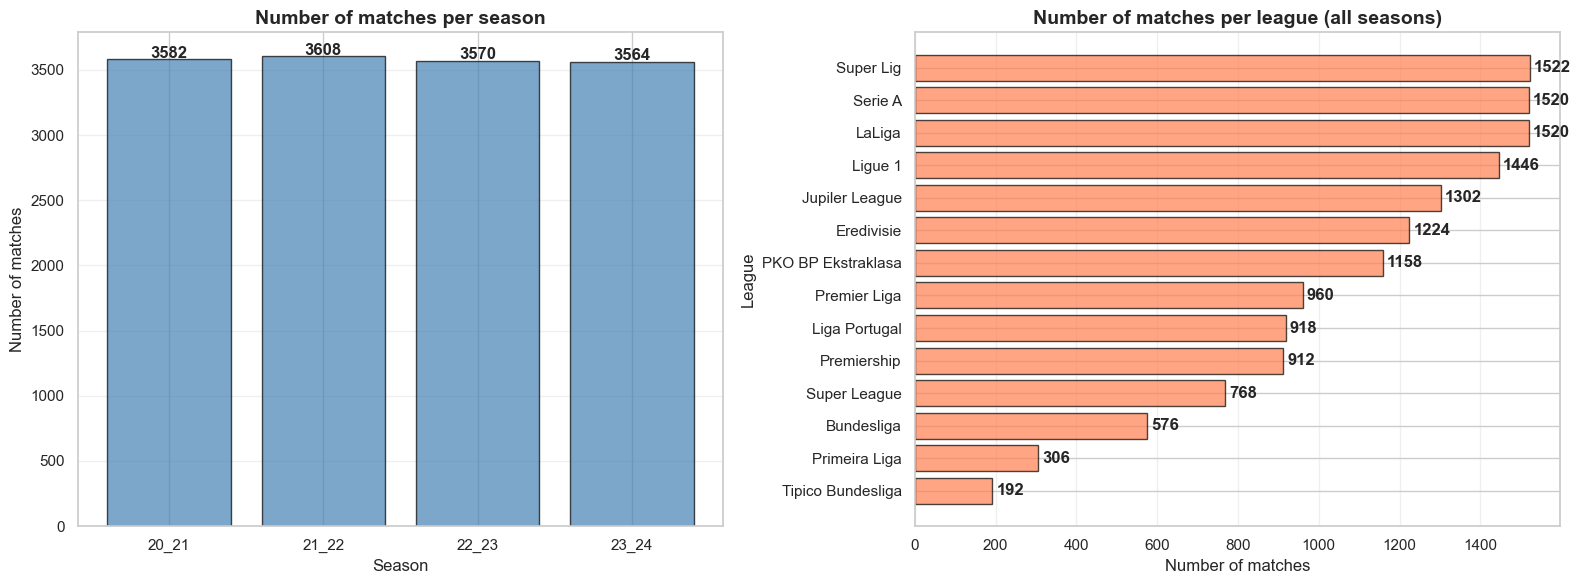

In [99]:
# Visualization: number of matches per season and league
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Matches per season
season_counts = [len(df) for df in df_list]
axes[0].bar(season_labels, season_counts, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Number of matches per season', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=12)
axes[0].set_ylabel('Number of matches', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(season_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 2: Matches per league (aggregated across all seasons)
all_leagues = pd.concat([df['league'] for df in df_list])
league_counts = all_leagues.value_counts().sort_values(ascending=True)
axes[1].barh(league_counts.index, league_counts.values, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Number of matches per league (all seasons)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of matches', fontsize=12)
axes[1].set_ylabel('League', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)
for i, (idx, v) in enumerate(league_counts.items()):
    axes[1].text(v + 10, i, str(v), va='center', fontweight='bold')

plt.tight_layout()
plt.show()

Primeira Liga seems suspicious so we need take a closer look

In [100]:
joined_df['team_1'].loc[joined_df['league'] == 'Primeira Liga'].unique()
joined_df['team_1'].loc[joined_df['league'] == 'Tipico Bundesliga'].unique()

array(['RB Salzburg', 'Rapid Wiedeń', 'Wolfsberger', 'Admira', 'Ried',
       'St. Polten', 'LASK', 'Sturm Graz', 'Tirol', 'Altach',
       'Austria Wiedeń', 'Hartberg', 'SK Rapid'], dtype=object)

After comparing with other leagues it seems that Pripeira Liga is Portugal league. So we perform hotfix

In [101]:
for df in df_list:
    df.loc[df['league'] == 'Primeira Liga', 'league'] = 'Liga Portugal'
    df.loc[df['league'] == 'Bundesliga', 'league'] = 'Tipico Bundesliga'

We should ensure there is consistent naming in the teams - best suited will be plot, rather than numbers to compare (at this stage)

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


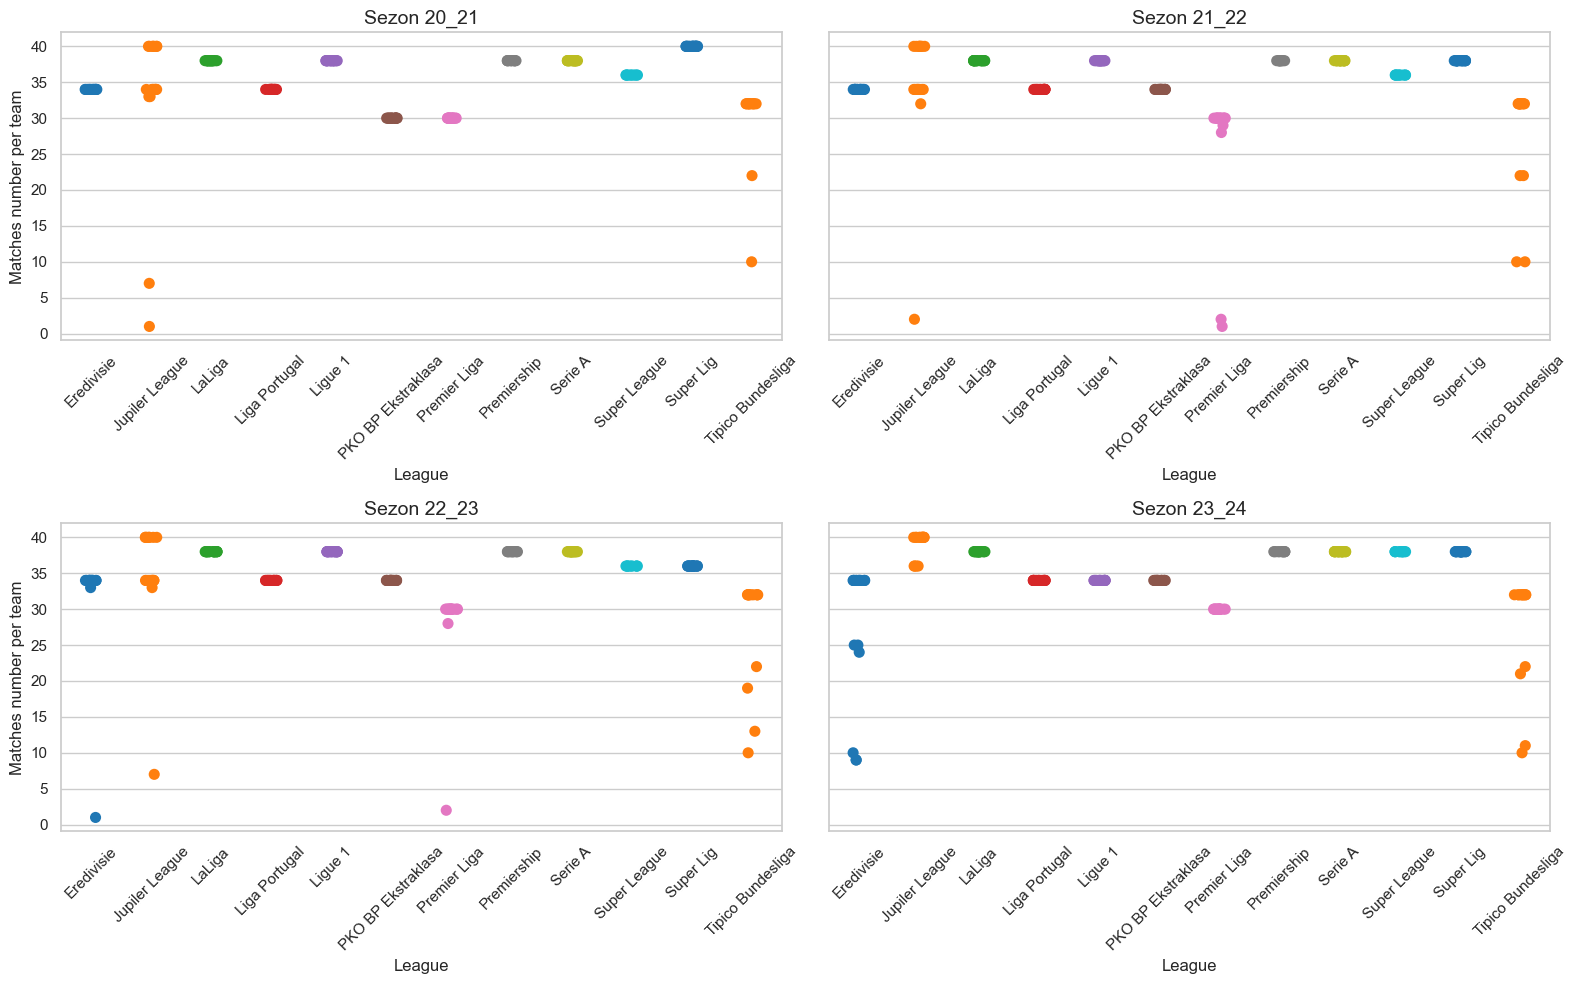

In [102]:
sns.set(style="whitegrid")

num_seasons = len(df_list)
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
axes = axes.flatten()

for i, df in enumerate(df_list):
    all_results = []

    for league_name, group in df.groupby('league'):
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        all_results.append(counts)

    season_df = pd.concat(all_results, ignore_index=True)

    sns.stripplot(
        x='league', y='count', data=season_df,
        jitter=True, size=8, palette="tab10", ax=axes[i]
    )

    axes[i].set_title(f'Sezon {season_labels[i]}', fontsize=14)
    axes[i].set_xlabel('League', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    if i % 2 == 0:
        axes[i].set_ylabel('Matches number per team', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

non-numeric columns include:
-	 match_id
-	 date
-	 league
-	 team_X
-    possession (due to % symbol at the end)
-	 team_X_formation
-	 team_X_line_Y

Note X represents 1 and 2, Y ranges from 1 to 5

In [103]:
for col in joined_df.columns:
    if joined_df[col].dtype != float: 
        print('\t', col)

	 match_id
	 date
	 league
	 team_1
	 team_2
	 possession_1
	 possession_2
	 team_1_formation
	 team_2_formation
	 team_1_line_1
	 team_1_line_2
	 team_1_line_3
	 team_2_line_1
	 team_2_line_2
	 team_2_line_3
	 team_2_line_4
	 team_1_line_4
	 team_1_line_5
	 team_2_line_5


In [104]:
home_wins = ((joined_df['goals_1'] > joined_df['goals_2'])).sum()
draws = ((joined_df['goals_1'] == joined_df['goals_2'])).sum()
away_wins = ((joined_df['goals_1'] < joined_df['goals_2'])).sum()

total_matches = len(joined_df)

print(f"Total matches:     {total_matches}")
print(f"Home wins:         {home_wins}")
print(f"Draws:             {draws}")
print(f"Away wins:         {away_wins}")


Total matches:     14324
Home wins:         6142
Draws:             3667
Away wins:         4515


We have access to standard match statistics:

In [105]:
joined_df[[col for col in joined_df.columns if not (col.startswith('bet_') or col.startswith('team_'))]].columns

Index(['match_id', 'date', 'league', 'turn', 'goals_1', 'goals_2', 'winner',
       'possession_1', 'possession_2', 'goal_chances_1', 'goal_chances_2',
       'shots_on_target_1', 'shots_on_target_2', 'shots_off_target_1',
       'shots_off_target_2', 'blocked_shots_1', 'blocked_shots_2',
       'offsides_1', 'offsides_2', 'goalkeeper_saves_1', 'goalkeeper_saves_2',
       'fouls_1', 'fouls_2', 'attacks_1', 'attacks_2', 'dangerous_attacks_1',
       'dangerous_attacks_2', 'red_cards_1', 'red_cards_2', 'free_kicks_1',
       'free_kicks_2', 'throw_ins_1', 'throw_ins_2', 'expected_goals_1',
       'expected_goals_2'],
      dtype='object')

In [106]:
joined_df[[col for col in joined_df.columns if not (col.startswith('bet_') or col.startswith('team_') or col == 'turn')]].describe().round(2)

,goals_1,goals_2,winner,goal_chances_1,goal_chances_2,shots_on_target_1,shots_on_target_2,shots_off_target_1,shots_off_target_2,blocked_shots_1,...,dangerous_attacks_1,dangerous_attacks_2,red_cards_1,red_cards_2,free_kicks_1,free_kicks_2,throw_ins_1,throw_ins_2,expected_goals_1,expected_goals_2
count,14324.00,14324.00,14324.00,14287.00,14287.00,14287.00,14287.00,14287.00,14287.00,12086.00,...,10906.00,10906.00,2923.00,2923.00,10509.00,10509.00,9102.00,9102.00,4116.00,4116.00
mean,1.52,1.25,1.06,13.36,11.30,4.78,4.01,5.73,4.89,3.36,...,54.25,47.55,0.54,0.61,13.89,13.96,20.98,20.07,1.46,1.17
std,1.29,1.17,0.75,5.40,4.89,2.59,2.38,3.16,2.85,2.31,...,20.96,19.62,0.57,0.57,4.78,4.72,6.33,6.14,0.86,0.76
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,0.00,0.00,9.00,8.00,3.00,2.00,3.00,3.00,2.00,...,39.00,33.00,0.00,0.00,11.00,11.00,17.00,16.00,0.82,0.60
50%,1.00,1.00,1.00,13.00,11.00,4.00,4.00,5.00,4.00,3.00,...,52.00,45.00,1.00,1.00,13.00,14.00,21.00,20.00,1.32,1.03
75%,2.00,2.00,2.00,17.00,14.00,6.00,5.00,7.00,6.00,5.00,...,67.00,59.00,1.00,1.00,17.00,17.00,25.00,24.00,1.94,1.58
max,9.00,13.00,2.00,46.00,45.00,23.00,23.00,29.00,25.00,18.00,...,163.00,171.00,3.00,3.00,45.00,39.00,51.00,53.00,6.41,5.61


In [107]:
df_temp = joined_df.copy()

df_temp['possession_1'] = df_temp['possession_1'].str.replace('%', '').astype(float)
df_temp['possession_2'] = df_temp['possession_2'].str.replace('%', '').astype(float)

metrics = [
    'goals',
    'possession',
    'goal_chances',
    'shots_on_target',
    'shots_off_target',
    'blocked_shots',
    'offsides',
    'goalkeeper_saves',
    'fouls',
    'attacks',
    'dangerous_attacks',
    'red_cards',
    'free_kicks',
    'throw_ins',
    'expected_goals'
]

for m in metrics:
    col_1 = f'{m}_1'
    col_2 = f'{m}_2'
    
    
    if col_1 in df_temp.columns and col_2 in df_temp.columns:
        
        df_temp[col_1] = pd.to_numeric(df_temp[col_1], errors='coerce')
        df_temp[col_2] = pd.to_numeric(df_temp[col_2], errors='coerce')
        
        df_temp[f'{m}'] = df_temp[col_1] + df_temp[col_2]

# usunięcie surowych kolumn
cols_to_drop = []
for m in metrics:
    cols_to_drop += [f'{m}_1', f'{m}_2']

df_temp = df_temp.drop(columns=[c for c in cols_to_drop if c in df_temp.columns])

df_temp[[col for col in df_temp.columns if not (col.startswith('bet_') or col.startswith('team_') or col == 'turn')]].describe().round(2)

,winner,goals,possession,goal_chances,shots_on_target,shots_off_target,blocked_shots,offsides,goalkeeper_saves,fouls,attacks,dangerous_attacks,red_cards,free_kicks,throw_ins,expected_goals
count,14324.00,14324.00,14275.00,14287.00,14287.00,14287.00,12086.00,14238.00,14287.00,14239.00,10905.00,10906.00,2923.00,10509.00,9102.00,4116.00
mean,1.06,2.77,100.00,24.66,8.80,10.63,6.20,3.56,6.05,24.94,202.16,101.81,1.16,27.84,41.05,2.63
std,0.75,1.67,0.01,6.07,3.23,4.12,2.89,2.16,2.71,6.11,31.73,26.91,0.44,7.56,9.85,1.05
min,0.00,0.00,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,3.00,0.00
25%,0.00,2.00,100.00,20.00,6.00,8.00,4.00,2.00,4.00,21.00,185.00,83.00,1.00,23.00,34.00,1.87
50%,1.00,3.00,100.00,24.00,9.00,10.00,6.00,3.00,6.00,25.00,205.00,97.00,1.00,27.00,41.00,2.54
75%,2.00,4.00,100.00,29.00,11.00,13.00,8.00,5.00,8.00,29.00,223.00,118.00,1.00,32.00,47.00,3.26
max,2.00,13.00,101.00,51.00,24.00,34.00,20.00,17.00,23.00,53.00,381.00,242.00,5.00,71.00,85.00,7.44


We also have team lineups with individual player ratings, stored in the columns team_X_line_Y

In [108]:
print(joined_df['team_2_formation'].unique().size)
joined_df['team_1_formation'].unique()

33


array(['4 - 3 - 3', '3 - 4 - 1 - 2', '4 - 3 - 1 - 2', '5 - 4 - 1',
       '3 - 4 - 2 - 1', '3 - 4 - 3', '4 - 4 - 2', '4 - 2 - 3 - 1',
       '5 - 3 - 2', '4 - 1 - 4 - 1', '4 - 1 - 2 - 1 - 2', '4 - 1 - 3 - 2',
       '4 - 4 - 1 - 1', '3 - 5 - 2', '4 - 5 - 1', '3 - 1 - 4 - 2',
       '4 - 2 - 2 - 2', '4 - 3 - 2 - 1', '3 - 2 - 4 - 1', '5 - 2 - 3',
       '4 - 2 - 1 - 3', '3 - 3 - 2 - 2', '3 - 5 - 1 - 1', '4 - 1 - 2 - 3',
       nan, '4 - 1 - 2 - 2 - 1', '5 - 3 - 1 - 1', '3 - 3 - 1 - 3',
       '3 - 3 - 3 - 1'], dtype=object)

In [109]:
lineup_cols = [f"team_1_line_{i}" for i in range(6)]
joined_df[lineup_cols].head()

,team_1_line_0,team_1_line_1,team_1_line_2,team_1_line_3,team_1_line_4,team_1_line_5
0,7.1,6.8-7.4-6.9-7.7,8.3-8.5-7.7,7.6-9.4-7.3,NaN,NaN
1,7.2,7.5-7.6-7.4,7.4-7.1-7.0-7.4,7.3,6.7-8.1,NaN
2,7.9,6.4-6.4-6.6-6.0,6.3-6.4-6.0,6.6,4.6-7.3,NaN
3,7.0,6.7-6.9-7.0-7.3-7.9,6.1-7.3-6.8-7.0,7.0,NaN,NaN
4,6.6,6.9-6.9-6.9,6.7-6.7-7.6-7.0,8.4-7.6,7.8,NaN


## Bet overwiev

This section provides a visual overview of the betting-related columns (those starting with *bet_*). To enable a clear and informative presentation of the data, minimal preprocessing was applied to the dataframe — such as handling missing or invalid odds. The goal is to understand the structure, availability, and basic characteristics of the betting data before deeper analysis.

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter

For some odds there maybe incorrect values/placecholders

In [111]:
def clean_bet_columns(df, name="df"):
    
    bet_cols = [col for col in df.columns if col.startswith('bet_')]
    
    print(f"\n=== Processing {name} ===")

    for col in bet_cols:
        
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
        bad_values = df.loc[df[col] < 1, col].dropna().unique()
        
        if len(bad_values) > 0:
            print(f"\nColumn: {col}")
            print("Values < 1.00:", bad_values)
            
            df.loc[df[col] < 1, col] = np.nan
    
    return df

In [112]:
# dla listy DF
df_list = [clean_bet_columns(df, f"df_{i}") for i, df in enumerate(df_list)]

# dla joined_df
joined_df = clean_bet_columns(joined_df, "joined_df")


=== Processing df_0 ===

Column: bet_below_0.5
Values < 1.00: [-1.]

Column: bet_below_1.5
Values < 1.00: [-1.]

Column: bet_below_4.5
Values < 1.00: [-1.]

Column: bet_below_5.5
Values < 1.00: [-1.]

Column: bet_below_6.5
Values < 1.00: [-1.]

Column: bet_handicap-_2
Values < 1.00: [-1.]

Column: bet_below_7.5
Values < 1.00: [-1.]

Column: bet_below_8.5
Values < 1.00: [-1.]

Column: bet_handicap-2_2
Values < 1.00: [-1.]

Column: bet_handicap-1.5_2
Values < 1.00: [-1.]

Column: bet_handicap-1_2
Values < 1.00: [-1.]

Column: bet_handicap+1_2
Values < 1.00: [-1.]

Column: bet_handicap+1.5_2
Values < 1.00: [-1.]

Column: bet_handicap+2_2
Values < 1.00: [-1.]

Column: bet_below_1
Values < 1.00: [-1.]

Column: bet_handicap-2.5_2
Values < 1.00: [-1.]

Column: bet_handicap+2.5_2
Values < 1.00: [-1.]

Column: bet_handicap-3_2
Values < 1.00: [-1.]

Column: bet_below_5
Values < 1.00: [-1.]

Column: bet_below_6
Values < 1.00: [-1.]

Column: bet_handicap-3.5_2
Values < 1.00: [-1.]

Column: bet_ha

General overwiev - distribution of odds

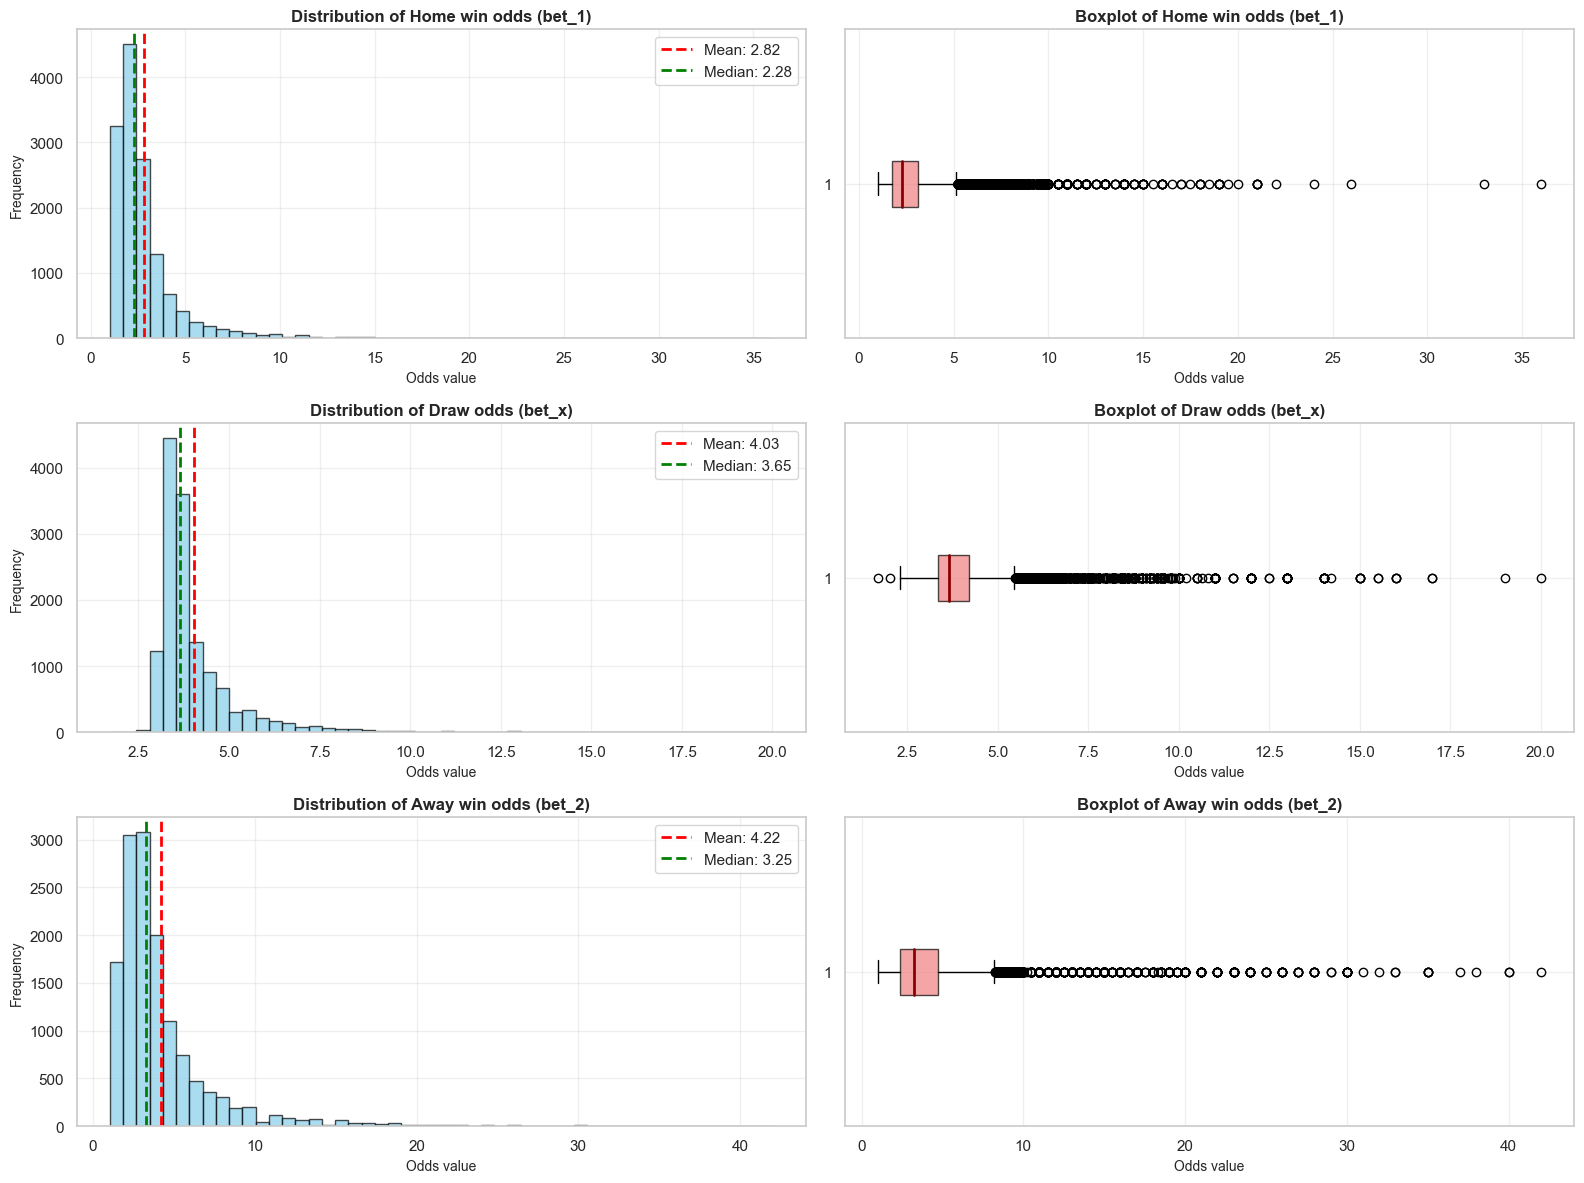


Statistics of betting odds:
          bet_1     bet_x     bet_2
count  13962.00  13962.00  13962.00
mean       2.82      4.03      4.22
std        1.94      1.25      3.41
min        1.02      1.71      1.04
25%        1.75      3.35      2.35
50%        2.28      3.65      3.25
75%        3.10      4.20      4.70
max       36.00     20.00     42.00


In [113]:
# Distribution of betting odds
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

bet_cols = ['bet_1', 'bet_x', 'bet_2']
bet_labels = [
    'Home win odds (bet_1)',
    'Draw odds (bet_x)',
    'Away win odds (bet_2)'
]

for i, (col, label) in enumerate(zip(bet_cols, bet_labels)):
    
    # Histogram
    axes[2*i].hist(joined_df[col].dropna(), bins=50, color='skyblue', alpha=0.7, edgecolor='black')
    axes[2*i].set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
    axes[2*i].set_xlabel('Odds value', fontsize=10)
    axes[2*i].set_ylabel('Frequency', fontsize=10)
    axes[2*i].axvline(joined_df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {joined_df[col].mean():.2f}')
    axes[2*i].axvline(joined_df[col].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {joined_df[col].median():.2f}')
    axes[2*i].legend()
    axes[2*i].grid(alpha=0.3)
    
    # Boxplot
    axes[2*i + 1].boxplot(joined_df[col].dropna(), vert=False, patch_artist=True,
                          boxprops=dict(facecolor='lightcoral', alpha=0.7),
                          medianprops=dict(color='darkred', linewidth=2))
    axes[2*i + 1].set_title(f'Boxplot of {label}', fontsize=12, fontweight='bold')
    axes[2*i + 1].set_xlabel('Odds value', fontsize=10)
    axes[2*i + 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nStatistics of betting odds:")
print(joined_df[bet_cols].describe().round(2))

On the website, unavailable bets were marked with a value of -1. In such cases, we replace these values with NaN to ensure a clear and accurate overview of the data

In [114]:
for df in df_list:
    bet_cols = [col for col in df.columns if col.startswith('bet_')]
    for col in bet_cols:
        df[col] = df[col].apply(lambda x: np.nan if pd.notna(x) and x < 0 else x)


Minor renaming was applied to prevent errors related to the handicap bet columns.

In [115]:
for _df in df_list:
    new_cols = {}
    for col in _df.columns:
        if col.startswith('bet_handicap-_'):
            new_col = col.replace('bet_handicap-_', 'bet_handicap-0_')
            new_cols[col] = new_col
    _df.rename(columns=new_cols, inplace=True)

Global search for the best-performing ranges in specified bet types (excluding 'above/below' and handicap due to their different structure). While this analysis could be performed per league, doing so would result in few hundreds lines of data to process. Therefore, we start with a global overview, followed by an automated algorithm to filter out 2–4 leagues with lower consistency

In [116]:
def calculate_profits_for_bet_column(df, bet_col, winning_values):
    original_values = []
    profits = []

    for _, row in df.iterrows():
        odds = row[bet_col]
        winner = float(row['winner'])
        original_values.append(odds)

        if winner in winning_values:
            profits.append(round(odds - 1, 2))
        else:
            profits.append(-1)

    return original_values, profits

In [117]:
def simple_bet_range(df, _range=1.0, bet_types=None, range_min=None, range_max=None):
    bet_winner = {
        'bet_1': {1.0},
        'bet_2': {2.0},
        'bet_x': {0.0},
        'bet_1x': {1.0, 0.0},
        'bet_12': {1.0, 2.0},
        'bet_x2': {0.0, 2.0}
    }

    if bet_types is None:
        bet_types = list(bet_winner.keys())

    results = []

    for bet_col in bet_types:
        if bet_col not in df.columns:
            continue

        filtered_df = df.copy()

        if range_min is not None:
            filtered_df = filtered_df[filtered_df[bet_col] >= range_min]
        if range_max is not None:
            filtered_df = filtered_df[filtered_df[bet_col] <= range_max]

        if filtered_df.empty or len(filtered_df) < 2:
            continue

        sorted_df = filtered_df.sort_values(by=bet_col)
        original_vals, profit_vals = calculate_profits_for_bet_column(
            sorted_df, bet_col, bet_winner[bet_col]
        )

        range_size = int(len(profit_vals) * _range)

        if range_size < 2:
            continue

        # Sliding window
        range_avg_profit = []
        for i in range(len(profit_vals) - range_size + 1):
            avg = round(sum(profit_vals[i:i + range_size]) / range_size, 3)
            range_avg_profit.append(avg)

        if not range_avg_profit:
            continue

        max_avg_profit = max(range_avg_profit)
        best_index = range_avg_profit.index(max_avg_profit)
        best_range = (
            original_vals[best_index],
            original_vals[best_index + range_size - 1]
        )

        print(f"Bet: {bet_col}")
        print(f"Highest expected value: {max_avg_profit}, Bet range: {best_range}")
        print("---------------------------------------------------------------")

        results.append({
            "bet": bet_col,
            "max_avg_profit": max_avg_profit,
            "range": best_range
        })

    return results


In [118]:
simple_bet_range(joined_df, _range=0.2)

Bet: bet_1
Highest expected value: -0.002, Bet range: (1.02, 1.66)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: 0.02, Bet range: (1.3, 2.24)
---------------------------------------------------------------
Bet: bet_x
Highest expected value: 0.043, Bet range: (3.45, 3.7)
---------------------------------------------------------------
Bet: bet_1x
Highest expected value: -0.005, Bet range: (1.22, 1.36)
---------------------------------------------------------------
Bet: bet_12
Highest expected value: -0.025, Bet range: (1.07, 1.23)
---------------------------------------------------------------
Bet: bet_x2
Highest expected value: 0.001, Bet range: (1.03, 1.36)
---------------------------------------------------------------


[{'bet': 'bet_1', 'max_avg_profit': -0.002, 'range': (1.02, 1.66)},
 {'bet': 'bet_2', 'max_avg_profit': 0.02, 'range': (1.3, 2.24)},
 {'bet': 'bet_x', 'max_avg_profit': 0.043, 'range': (3.45, 3.7)},
 {'bet': 'bet_1x', 'max_avg_profit': -0.005, 'range': (1.22, 1.36)},
 {'bet': 'bet_12', 'max_avg_profit': -0.025, 'range': (1.07, 1.23)},
 {'bet': 'bet_x2', 'max_avg_profit': 0.001, 'range': (1.03, 1.36)}]

Because this process is not yet automated, we manually copy the results into the *ranges* variable. Our goal is to identify the leagues with the poorest data quality or least reliable patterns for further analysis.

In [119]:
ranges = {
    'bet_1': [1.02, 1.66],
    'bet_2': [1.3, 2.24],
    'bet_x': [3.45, 3.7],
    'bet_1x': [1.23, 1.37],
    'bet_12': [1.07, 1.23],
    'bet_x2': [1.04, 1.36]
}
bet_types = list(ranges.keys())

all_results = {bet: [] for bet in bet_types}
leagues = joined_df['league'].unique()

for league in leagues:
    league_df = joined_df[joined_df['league'] == league]

    for bet_type in bet_types:
        range_min, range_max = ranges[bet_type]

        results = simple_bet_range(
            league_df,
            bet_types=[bet_type],
            range_min=range_min,
            range_max=range_max
        )

        for res in results:
            all_results[bet_type].append({
                "league": league,
                "max_avg_profit": res["max_avg_profit"],
                "range": res["range"]
            })


for bet_type in bet_types:
    print(f"\n=== Worst leagues: {bet_type} ===")
    sorted_leagues = sorted(all_results[bet_type], key=lambda x: x["max_avg_profit"])
    for entry in sorted_leagues[:3]:
        print(f"League: {entry['league']}, Average profit: {entry['max_avg_profit']}, Range: {entry['range']}")


Bet: bet_1
Highest expected value: -0.05, Bet range: (1.05, 1.65)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: 0.057, Bet range: (1.3, 2.23)
---------------------------------------------------------------
Bet: bet_x
Highest expected value: 0.136, Bet range: (3.45, 3.7)
---------------------------------------------------------------
Bet: bet_1x
Highest expected value: 0.036, Bet range: (1.23, 1.37)
---------------------------------------------------------------
Bet: bet_12
Highest expected value: -0.065, Bet range: (1.07, 1.23)
---------------------------------------------------------------
Bet: bet_x2
Highest expected value: 0.045, Bet range: (1.06, 1.36)
---------------------------------------------------------------
Bet: bet_1
Highest expected value: 0.046, Bet range: (1.18, 1.66)
---------------------------------------------------------------
Bet: bet_2
Highest expected value: -0.089, Bet range: (1.36, 2.24)
---------------------

Selecting/finding the three leagues with the poorest performance

In [120]:
worst_counter = Counter()

for bet_type in bet_types:
    sorted_leagues = sorted(all_results[bet_type], key=lambda x: x["max_avg_profit"])
    worst_3 = sorted_leagues[:3]

    for entry in worst_3:
        worst_counter[entry["league"]] += 1

for league, count in worst_counter.most_common():
    print(f"League: {league}, Counter: {count}")

League: Premier Liga, Counter: 4
League: Jupiler League, Counter: 3
League: Super League, Counter: 3
League: Eredivisie, Counter: 2
League: Bundesliga, Counter: 1
League: Tipico Bundesliga, Counter: 1
League: Premiership, Counter: 1
League: Primeira Liga, Counter: 1
League: Liga Portugal, Counter: 1
League: Ligue 1, Counter: 1


In [121]:
leagues_to_exclude = ['Premier Liga', 'Jupiler League', 'Super League']

Having identified the leagues with the worst performance, we can exclude them from the analysis. This should improve the overall data quality for our basic analysis. As a result, charts will be generated both including all leagues and excluding the filtered ones. This will allow us to compare the impact of removing these leagues on the analysis outcomes.

In [122]:
def base_bet_condition(winner, winner_type):
    if winner_type == '1':
        return winner == 1.0
    elif winner_type == '2':
        return winner == 2.0
    elif winner_type == 'x':
        return winner == 0.0
    elif winner_type == '1x':
        return winner in [1.0, 0.0]
    elif winner_type == '12':
        return winner in [1.0, 2.0]
    elif winner_type == 'x2':
        return winner in [0.0, 2.0]
    else:
        return False

In [123]:
def plot_base_bets(bet_type, range_min=1.0, range_max=3.0, step=0.2, nameprefix='', df_list=df_list):
    season_years = {
        0: '2020-2021',
        1: '2021-2022',
        2: '2022-2023',
        3: '2023-2024'
    }
    
    winner_type = str(bet_type).split('_')[1]
    bins = np.arange(range_min, range_max + step, step)
    labels = [f"{round(b, 2)}–{round(b+step, 2)}" for b in bins[:-1]]

    num_plots = len(df_list)
    fig, axes = plt.subplots(num_plots, 1, figsize=(12, 6 * num_plots))

    if num_plots == 1:
        axes = [axes]

    for i, df in enumerate(df_list):
        df = df.copy()
        df['bin'] = pd.cut(df[bet_type], bins=bins, labels=labels, include_lowest=True)

        hits = df['winner'].apply(lambda x: base_bet_condition(x, winner_type))
        green = df[hits].groupby('bin').size().reindex(labels, fill_value=0)
        red = df[~hits].groupby('bin').size().reindex(labels, fill_value=0)

        def avg_profit(grupa):
            hits = grupa['winner'].apply(lambda x: base_bet_condition(x, winner_type))
            score = ((grupa[bet_type] - 1).where(hits, -1)).sum()
            return score / len(grupa) if len(grupa) > 0 else 0

        profit = df.groupby('bin').apply(avg_profit).reindex(labels, fill_value=0)

        x = np.arange(len(labels))
        width = 0.35

        ax1 = axes[i]
        ax1.bar(x - width / 2, green, width=width, color='green', label='Win')
        ax1.bar(x + width / 2, red, width=width, color='red', label='Lost')
        ax1.set_ylabel('Number of bets')
        ax1.set_title(f'DF {i} — {bet_type} vs winner')
        ax1.set_title(f'Season {season_years[i]} — Zakłady typu: {bet_type}')

        ax2 = ax1.twinx()
        ax2.bar(x, profit, width=width / 2, color='blue', alpha=0.5, label='Average profit')
        ax2.axhline(y=0, color='black', linewidth=2, linestyle='--')

        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=45)
        ax1.grid(True, alpha=0.4)

        h1, l1 = ax1.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax1.legend(h1 + h2, l1 + l2, loc='best')

        # plt.tight_layout()
        plt.savefig(f"../charts/{nameprefix}{bet_type}_{range_min}_to_{range_max}_step{step}.png", dpi=400, bbox_inches='tight')
    plt.show()

In [124]:
def plot_joined_bets(bet_type, range_min=1.0, range_max=3.0, step=0.2, nameprefix='', df=joined_df):
    
    winner_type = str(bet_type).split('_')[1]
    
    bins = np.arange(range_min, range_max + step, step)
    labels = [f"{round(b, 2)}–{round(b+step, 2)}" for b in bins[:-1]]

    df = df.copy()
    df['bin'] = pd.cut(df[bet_type], bins=bins, labels=labels, include_lowest=True)

    hits = df['winner'].apply(lambda x: base_bet_condition(x, winner_type))

    green = df[hits].groupby('bin').size().reindex(labels, fill_value=0)
    red = df[~hits].groupby('bin').size().reindex(labels, fill_value=0)

    def avg_profit(grupa):
        hits_local = grupa['winner'].apply(lambda x: base_bet_condition(x, winner_type))
        score = ((grupa[bet_type] - 1).where(hits_local, -1)).sum()
        return score / len(grupa) if len(grupa) > 0 else 0

    profit = df.groupby('bin').apply(avg_profit).reindex(labels, fill_value=0)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    x = np.arange(len(labels))
    width = 0.35

    ax1.bar(x - width / 2, green, width=width, color='green', label='Win')
    ax1.bar(x + width / 2, red, width=width, color='red', label='Loss')

    ax1.set_ylabel('Number of bets')
    ax1.set_title(f'{bet_type} — Win/Loss distribution (joined dataset)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45)
    ax1.grid(alpha=0.4)

    ax2 = ax1.twinx()
    ax2.bar(x, profit, width=width / 2, color='blue', alpha=0.4, label='Avg profit')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1)

    # legend merge
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best')

    plt.tight_layout()

    plt.savefig(
        f"../charts/{nameprefix}{bet_type}_{range_min}_to_{range_max}_step{step}.png",
        dpi=400,
        bbox_inches='tight'
    )

    plt.show()

Here we run the plotting function and modify commented lines to view or save the plots. We repeat this process for the bet types: *bet_1*, *bet_x*, *bet_2*, *bet_1x*, *bet_12*, and *bet_x2*.

In [125]:
# plot_joined_bets('bet_12', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_1',  1.0, 2.4, 0.2)
# plot_joined_bets('bet_2',  1.0, 2.4, 0.2)
# plot_joined_bets('bet_x2', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_1x', 1.0, 2.4, 0.2)
# plot_joined_bets('bet_x',  2.4, 3.8, 0.2)

In [126]:
filtered_df_list = []
for df in df_list:
    filtered_df = df[~df['league'].isin(leagues_to_exclude)].copy()
    filtered_df_list.append(filtered_df)

# plot_base_bets('bet_12', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_1', 1.0, 3.0, 0.2, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_2', 1.0, 3.0, 0.2, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_x2', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_1x', 1.0, 1.6, 0.05, nameprefix='filtered_', df_list=filtered_df_list)
# plot_base_bets('bet_x', 2.6, 4.6, 0.2, nameprefix='filtered_', df_list=filtered_df_list)

Now let’s take a closer look at the bet types: above, below, and handicap

In [127]:
def advanced_bet_condition(col_name, goals_1, goals_2) -> bool:
    if 'handicap' in col_name:
        try:
            suffix = col_name.replace('bet_handicap', '')
            additional_goals_str, winner_str = suffix.split('_')
            
            if additional_goals_str in ["-", "", "+", " "]:
                additional_goals = 0.0
            else:
                additional_goals = float(additional_goals_str)
    
            winner = int(winner_str)
            not_winner = 1 if winner == 2 else 2

            goals_map = {1: goals_1, 2: goals_2}
            return (goals_map[winner] + additional_goals) > goals_map[not_winner]

        except:
            return False
    
    if 'above' in col_name:
        try:
            value = float(col_name.split("_")[-1])
        except:
            return False
        
        return (goals_1 + goals_2) > value
    
    if 'below' in col_name:
        try:
            value = float(col_name.split("_")[-1])
        except:
            return False
        
        return (goals_1 + goals_2) < value
    
    return False

In [128]:
def plot_bet_results_by_type(prefix, handicap_team=1, save=True):
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 5), constrained_layout=True)

    bet_cols = [col for col in joined_df.columns if col.startswith(prefix)]
    if prefix == 'bet_handicap':
        bet_cols = [col for col in bet_cols if col.endswith(f"_{handicap_team}")]

    stats = {}
    results = defaultdict(list)

    for col in bet_cols:
        if prefix != 'bet_handicap':
            bet_value = col.split('_')[-1]
        else:
            raw = col.replace(prefix, "").split('_')[0]
            try:
                bet_value = float(raw)
            except:
                bet_value = '0.0'

        for _, row in joined_df.iterrows():
            if pd.isna(row[col]):
                continue
            val = pd.to_numeric(row[col], errors='coerce')
            if pd.isna(val):
                continue
            res = advanced_bet_condition(col, row['goals_1'], row['goals_2'])
            profit = val - 1 if res else -1
            results[bet_value].append(profit)


    for bet_value, profit_list in results.items():
        if not profit_list:
            continue

        green = sum(1 for p in profit_list if p > 0)
        red = profit_list.count(-1)
        avg_profit = sum(profit_list) / len(profit_list)
        stats[bet_value] = {'green': green, 'red': red, 'profit': avg_profit}


    def safe_sort_key(x):
        try:
            return float(str(x).replace('+', ''))
        except:
            return 0.0

    labels = sorted(stats.keys(), key=safe_sort_key)

    # labels = sorted(stats.keys(), key=lambda x: float(x.replace('+', '')) if x not in ['-', '', None] else 0.0)
    green_vals = [stats[label]['green'] for label in labels]
    red_vals = [stats[label]['red'] for label in labels]
    blue_vals = [stats[label]['profit'] for label in labels]

    x = np.arange(len(labels))
    width = 0.35

    # Left axis - total matches
    ax1.bar(x - width / 2, green_vals, width=width, color='green', label='Win')
    ax1.bar(x + width / 2, red_vals, width=width, color='red', label='Lost')
    ax1.set_ylabel('Number of bets')
    ax1.set_xlabel('Bet value')
    ax1.set_title(f'Zakłady typu: {prefix}')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, rotation=45)
    ax1.grid(True, alpha=0.3)

    # Right axis - profits
    ax2 = ax1.twinx()
    ax2.axhline(y=0, color='black', linewidth=2, linestyle='--')
    ax2.bar(x, blue_vals, width=width / 2, color='blue', alpha=0.5, label='Average profit')

    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc='best')

    if save:
        prefix = f'{prefix}_{handicap_team}' if prefix == 'bet_handicap' else prefix
        os.makedirs("charts", exist_ok=True)
        plt.savefig(f"../charts/{prefix}.png", dpi=400, bbox_inches='tight')

    plt.show()

In [129]:
# plot_bet_results_by_type('bet_above')

In [130]:
# plot_bet_results_by_type('bet_below')

In [131]:
# plot_bet_results_by_type('bet_handicap', 1)

In [132]:
# plot_bet_results_by_type('bet_handicap', 2)

As observed, there is an issue with the *handicap* bets. After reviewing the CSV data and comparing it to the website, we discovered data leakage. Therefore, we will exclude handicap bets from our analysis until this issue is resolved, for example, by re-downloading the data.

## Time and Seasonality Analysis

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day_of_week'] = df['date'].dt.dayofweek
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['month'] = df['date'].dt.month
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1668739428.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider join

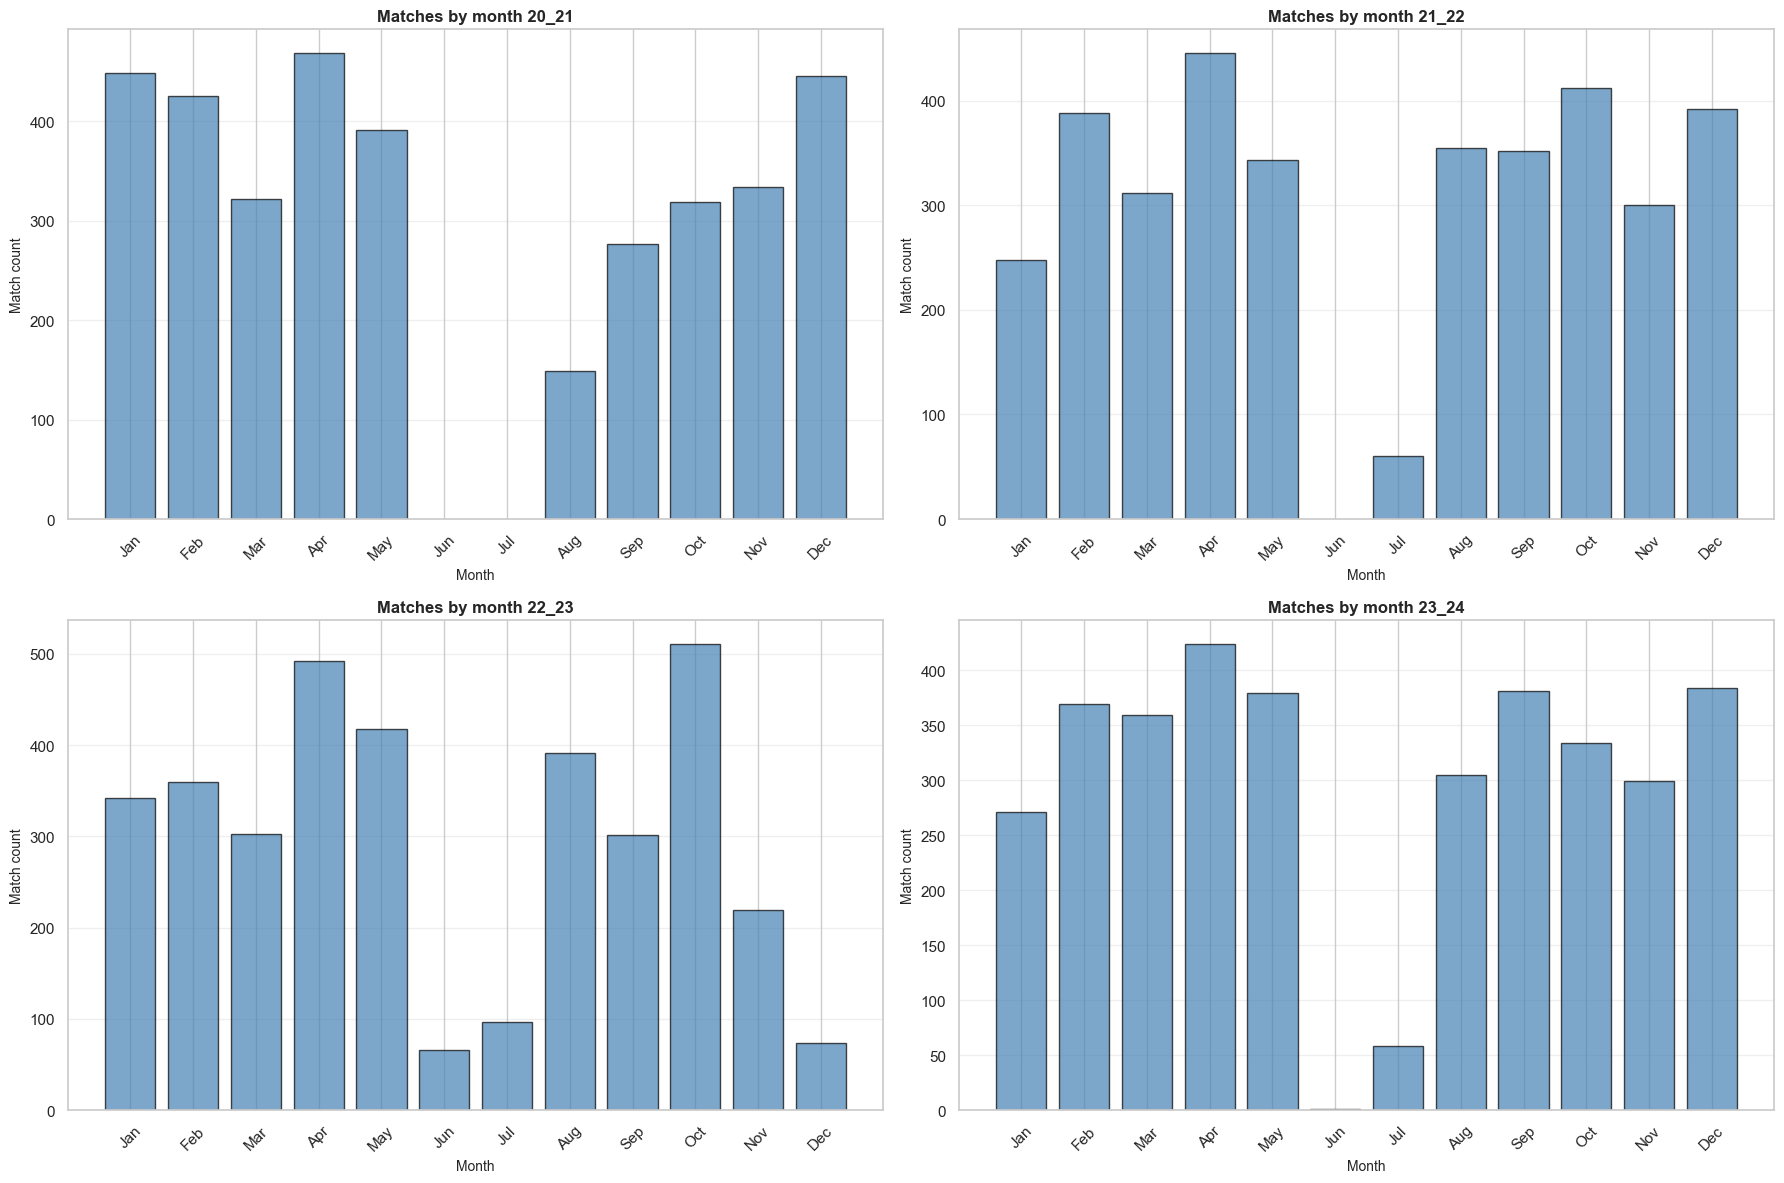

In [133]:
for df in df_list:
    df['date'] = pd.to_datetime(df['date'], format="%d.%m.%Y %H:%M")
    df['month'] = df['date'].dt.month
    df['day_of_week'] = df['date'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, (df, label) in enumerate(zip(df_list, season_labels)):
    month_counts = df['month'].value_counts().sort_index()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    axes[i].bar(month_counts.index, month_counts.values, 
                color='steelblue', alpha=0.7, edgecolor='black')
    axes[i].set_title(f'Matches by month {label}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Month', fontsize=10)
    axes[i].set_ylabel('Match count', fontsize=10)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels([month_names[m-1] for m in range(1, 13)], rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Small feature engineering and formatting

In [134]:
for df in df_list:
    df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
    df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']
    df['possession_1'] = df['possession_1'].str.replace('%','').astype(float)
    df['possession_2'] = df['possession_2'].str.replace('%','').astype(float)

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3760346085.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

In [135]:
df[['shots_1', 'shots_off_target_1', 'shots_on_target_1']].mean()

shots_1               11.134999
shots_off_target_1     6.278978
shots_on_target_1      4.856020
dtype: float64

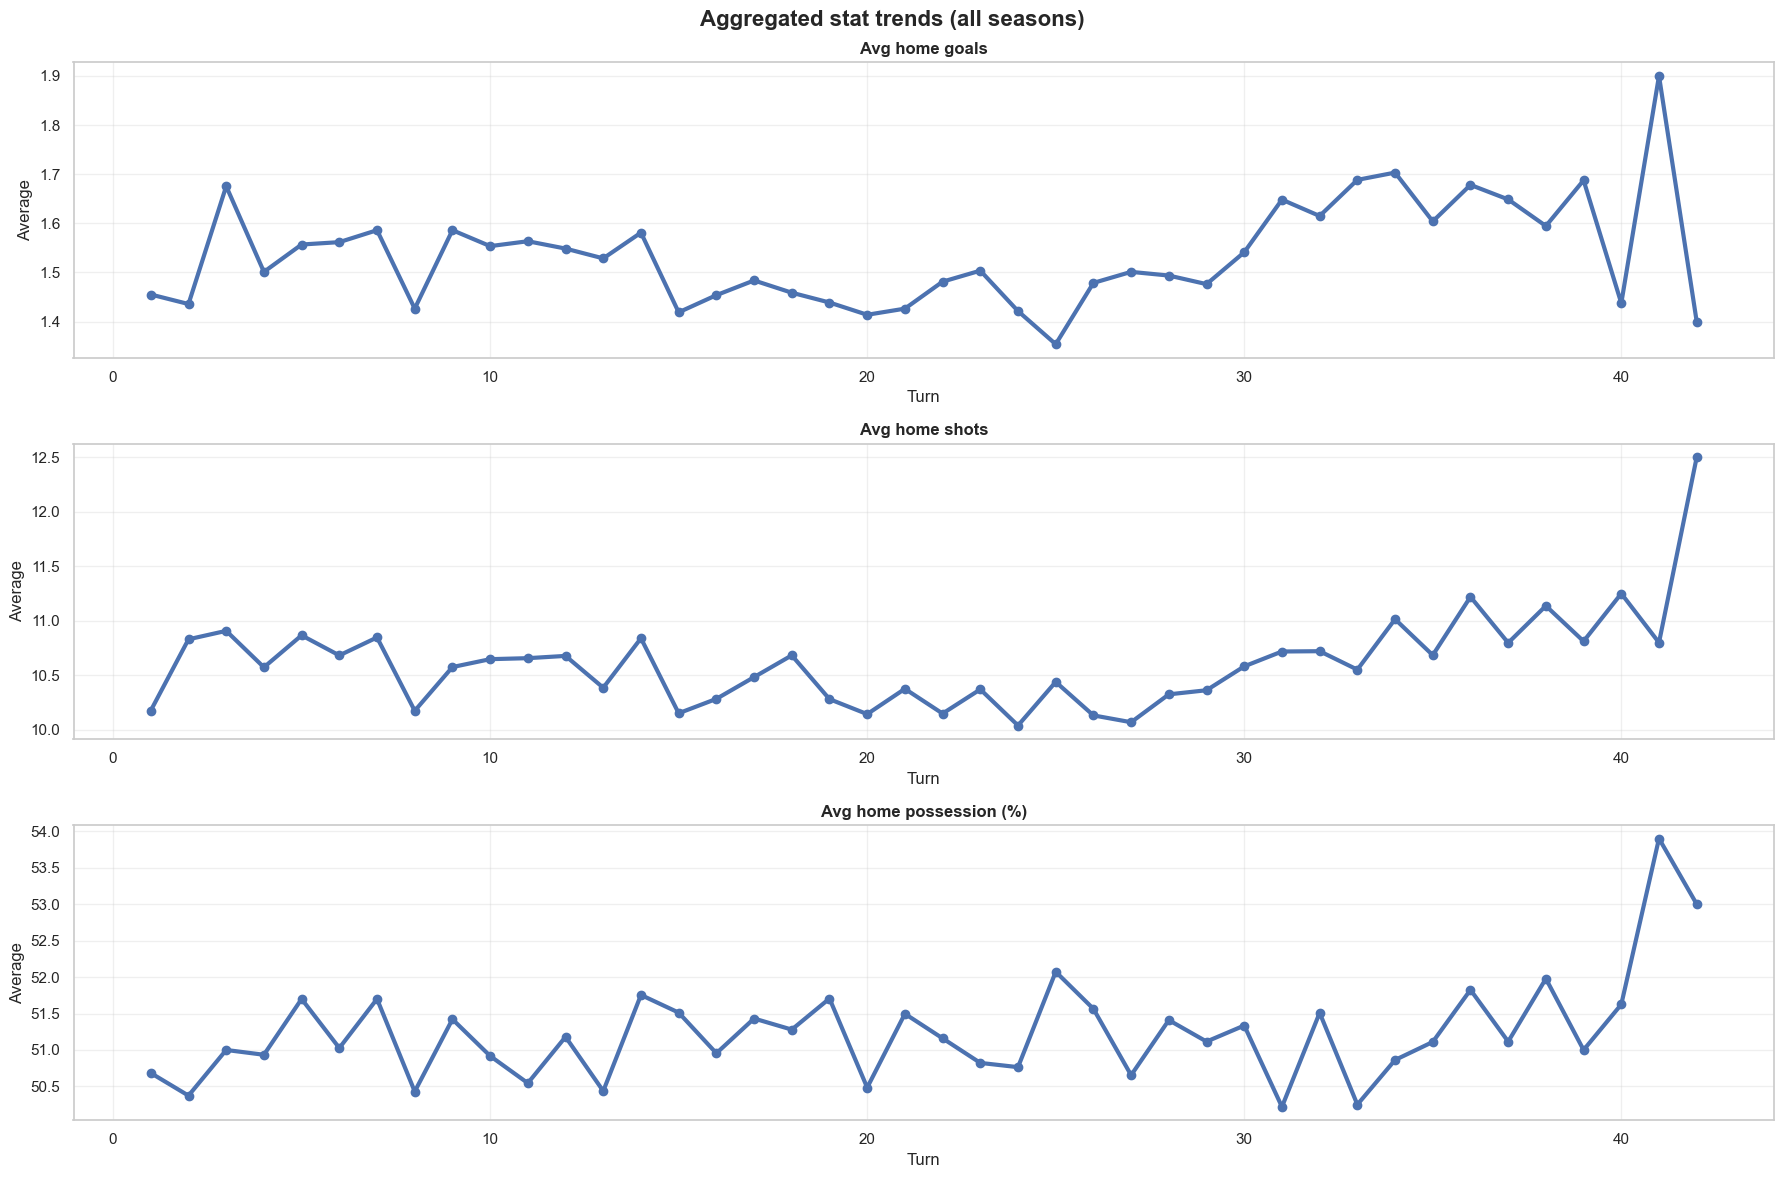

In [136]:
df_all = pd.concat(df_list)

stats_to_plot = ['goals_1', 'shots_1', 'possession_1']
stat_labels = ['Avg home goals', 'Avg home shots',
               'Avg home possession (%)']

fig, axes = plt.subplots(3, 1, figsize=(18, 12))

for i, (stat, stat_label) in enumerate(zip(stats_to_plot, stat_labels)):
    temp = df_all.copy()
    temp[stat] = pd.to_numeric(temp[stat], errors='coerce')

    trend = temp.groupby('turn')[stat].mean()

    axes[i].plot(trend.index, trend.values, marker='o', linewidth=3)

    axes[i].set_title(stat_label, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Turn')
    axes[i].set_ylabel('Average')
    axes[i].grid(alpha=0.3)

plt.suptitle('Aggregated stat trends (all seasons)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

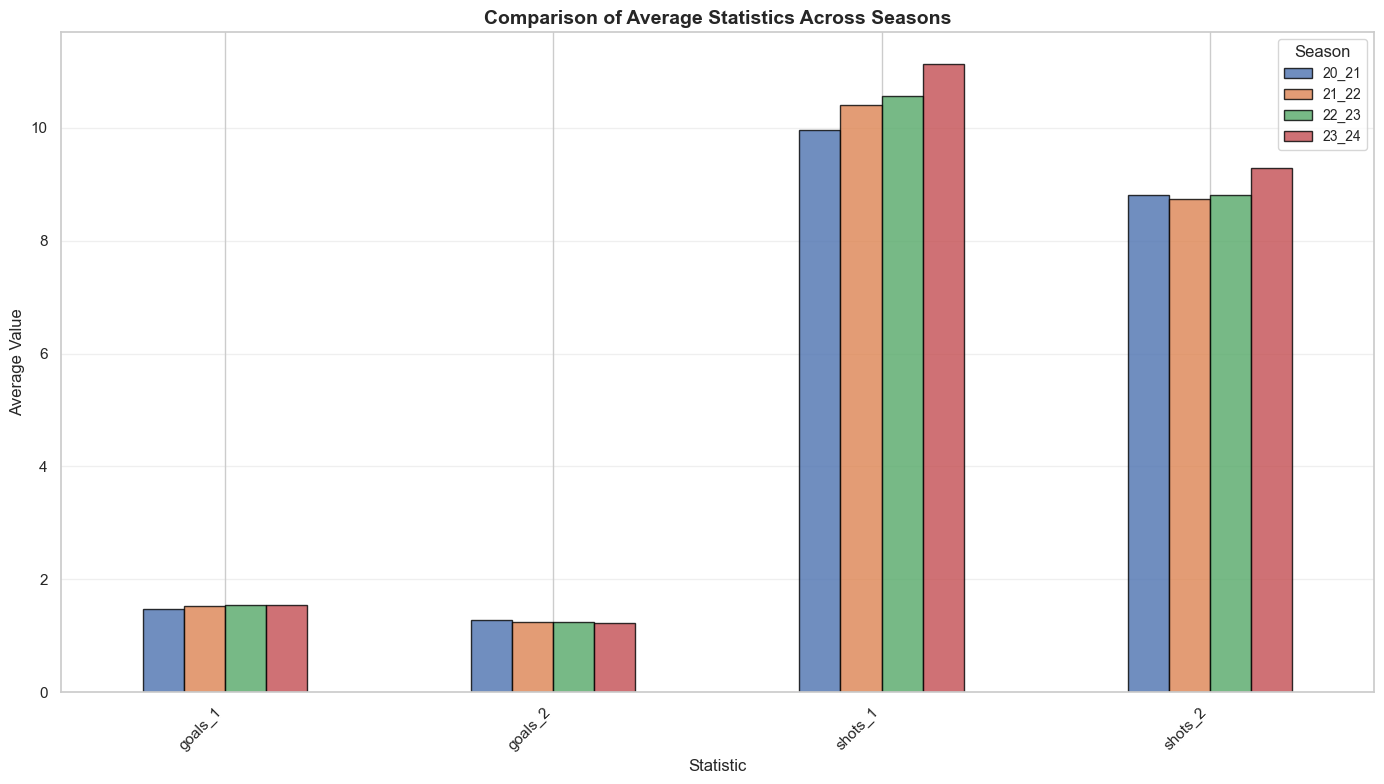


Average values per season:
        goals_1  goals_2  shots_1  shots_2
season                                    
20_21      1.47     1.28     9.96     8.81
21_22      1.52     1.24    10.41     8.73
22_23      1.55     1.25    10.57     8.80
23_24      1.54     1.23    11.13     9.29


In [137]:
comparison_stats = ['goals_1', 'goals_2', 'shots_1', 'shots_2']
comparison_stats = [col for col in comparison_stats if col in df_all.columns]

season_means = []
for df, label in zip(df_list, season_labels):
    means = df[comparison_stats].mean()
    means['season'] = label
    season_means.append(means)

season_means_df = pd.DataFrame(season_means)
season_means_df = season_means_df.set_index('season')

fig, ax = plt.subplots(figsize=(14, 8))
season_means_df.T.plot(kind='bar', ax=ax, alpha=0.8, edgecolor='black')

ax.set_title('Comparison of Average Statistics Across Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Statistic', fontsize=12)
ax.set_ylabel('Average Value', fontsize=12)

ax.legend(title='Season', fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nAverage values per season:")
print(season_means_df.round(2))

# 3. Missing data handling

After running *quality.ipynb*, most of the data has been filled. However, some specific values might still be missing due to their absence on the source web page. Let's now proceed with filling in the missing values.

Let's assume that in some cases of a match statistic are NaN (e.g., red cards), it means that the event did not occur. Therefore, some cases will be filled with 0.

Important: match header data — date, teams, and goals — are always provided.

## Match statistics

In [138]:
def check_nans_by_columns(columns: list, threshold=0.2):
    for i, _df in enumerate(df_list):
        print(f'\n===== DATAFRAME {i} =====')
        total_rows = len(_df)

        for _col in columns:
            for suffix in ['_1', '_2', '']:
                col_name = f'{_col}{suffix}' if suffix else _col
                
                if col_name in _df.columns:
                    na_count = _df[col_name].isna().sum()
                    
                    if na_count == 0:
                        continue
                    
                    na_pct = na_count / total_rows * 100
                    flag = ' >20%' if na_pct > threshold * 100 else ''
                    
                    print(f'{col_name:<25} | NA: {na_count:<5} | {na_pct:>6.2f}% {flag}')

In [139]:
# chunk 1 info
check_nans_by_columns(['match_id','date','league','turn','team_1','team_2','goals_1','goals_2','winner'])


===== DATAFRAME 0 =====

===== DATAFRAME 1 =====

===== DATAFRAME 2 =====

===== DATAFRAME 3 =====


In [140]:
# chunk 2 info
check_nans_by_columns(['shots','expected_goals','possession','goal_chances','shots_on_target','shots_off_target','blocked_shots', 'free_kicks','offsides','throw_ins','goalkeeper_saves','fouls', 'red_cards','attacks','dangerous_attacks'])


===== DATAFRAME 0 =====
shots_1                   | NA: 4     |   0.11% 
shots_2                   | NA: 4     |   0.11% 
possession_1              | NA: 11    |   0.31% 
possession_2              | NA: 11    |   0.31% 
goal_chances_1            | NA: 4     |   0.11% 
goal_chances_2            | NA: 4     |   0.11% 
shots_on_target_1         | NA: 4     |   0.11% 
shots_on_target_2         | NA: 4     |   0.11% 
shots_off_target_1        | NA: 4     |   0.11% 
shots_off_target_2        | NA: 4     |   0.11% 
blocked_shots_1           | NA: 605   |  16.89% 
blocked_shots_2           | NA: 605   |  16.89% 
free_kicks_1              | NA: 1479  |  41.29%  >20%
free_kicks_2              | NA: 1479  |  41.29%  >20%
offsides_1                | NA: 11    |   0.31% 
offsides_2                | NA: 11    |   0.31% 
throw_ins_1               | NA: 2939  |  82.05%  >20%
throw_ins_2               | NA: 2939  |  82.05%  >20%
goalkeeper_saves_1        | NA: 4     |   0.11% 
goalkeeper_saves_2      

Filling match statistics

In [141]:
def fill_missing_by_team_mean(df, team_col, value_col, default_value=0):
    team_avg = df.groupby(team_col)[value_col].mean()

    def fill_func(row):
        if pd.isna(row[value_col]):
            return team_avg.get(row[team_col], default_value)
        else:
            return row[value_col]
    
    df[value_col] = df.apply(fill_func, axis=1)

def adjust_possession(row):
    p1 = row['possession_1']
    p2 = row['possession_2']
    
    if pd.isna(p1) and pd.isna(p2):
        return pd.Series([50, 50])
    if pd.isna(p1):
        p1 = 100 - p2
    if pd.isna(p2):
        p2 = 100 - p1

    total = p1 + p2
    if total == 0:
        return pd.Series([50, 50])
    
    factor = 100 / total
    p1_scaled = round(p1 * factor)
    p2_scaled = 100 - p1_scaled

    return pd.Series([p1_scaled, p2_scaled])

In [142]:
for _df in df_list:    
    # possession
    fill_missing_by_team_mean(_df, team_col='team_1', value_col='possession_1', default_value=50)
    fill_missing_by_team_mean(_df, team_col='team_2', value_col='possession_2', default_value=50)
    # scaling possession
    _df[['possession_1', 'possession_2']] = _df.apply(adjust_possession, axis=1)

    # fouls
    _df['fouls_1'] = _df['fouls_1'].fillna(_df.groupby('team_1')['fouls_1'].transform('median')).fillna(0)
    _df['fouls_2'] = _df['fouls_2'].fillna(_df.groupby('team_2')['fouls_2'].transform('median')).fillna(0)
    
    # offsides (spalone)
    _df['offsides_1'] = _df['offsides_1'].fillna(_df.groupby('team_1')['offsides_1'].transform('median')).fillna(0)
    _df['offsides_2'] = _df['offsides_2'].fillna(_df.groupby('team_2')['offsides_2'].transform('median')).fillna(0)

    # red cards
    _df['red_cards_1'].fillna(0, inplace=True)
    _df['red_cards_2'].fillna(0, inplace=True)


In [143]:
for _df in df_list:
    for _col in ['goal_chances', 'shots_on_target', 'shots_off_target', 'goalkeeper_saves', 'attacks', 'dangerous_attacks']:
        _df[f'{_col}_1'] = _df[f'{_col}_1'].fillna(_df.groupby('team_1')[f'{_col}_1'].transform('median')).fillna(0)
        _df[f'{_col}_2'] = _df[f'{_col}_2'].fillna(_df.groupby('team_2')[f'{_col}_2'].transform('median')).fillna(0)

Below removed columns due to excessive missing values; filling NAs would not be accurate. Resolving this issue requires a different scraper and data source.

In [144]:
for _df in df_list:
    _df.drop(columns=['expected_goals_1', 'expected_goals_2', 'throw_ins_1', 'throw_ins_2', 'free_kicks_1', 'free_kicks_2', 'blocked_shots_1', 'blocked_shots_2'], axis=1, inplace=True, errors='ignore')

Refresh shots column

In [145]:
for df in df_list:
    df['shots_1'] = df['shots_on_target_1'] + df['shots_off_target_1']
    df['shots_2'] = df['shots_on_target_2'] + df['shots_off_target_2']

Ensure the filling process went correctly

In [146]:
# chunk 2 info
check_nans_by_columns(['shots','expected_goals','possession','goal_chances','shots_on_target','shots_off_target','blocked_shots', 'free_kicks','offsides','throw_ins','goalkeeper_saves','fouls', 'red_cards','attacks','dangerous_attacks'])


===== DATAFRAME 0 =====

===== DATAFRAME 1 =====

===== DATAFRAME 2 =====

===== DATAFRAME 3 =====


## Team setups and player ratings

Checking for NANs in team formations

In [147]:
for _df in df_list:
    print('=================')
    print(_df['team_1_formation'].isna().sum())
    print(_df['team_2_formation'].isna().sum())

2
2
2
2
36
36
1
0


Filling missing values with the most popular formation for each team

In [148]:
for _df in df_list:
    _df['team_1_formation'] = _df['team_1_formation'].fillna(
        _df.groupby('team_1')['team_1_formation'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )
    _df['team_2_formation'] = _df['team_2_formation'].fillna(
        _df.groupby('team_2')['team_2_formation'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    )

In [149]:
for _df in df_list:
    print('=================')
    print(_df['team_1_formation'].isna().sum())
    print(_df['team_2_formation'].isna().sum())

0
0
0
0
0
0
0
0


Handling player ratings stored as line-format strings (e.g., "6.2-6.7-4.3") is inconvenient. A better approach is to aggregate these ratings into a single value, categorize them into defense/support/offense ratings, or split them into separate ratings for each player. The most flexible solution is the last one—splitting the ratings per player. Therefore, we will transform the DataFrame accordingly and handle missing values in one centralized step.

In [150]:
def extract_scores(row, prefix, formation):
    scores = []
    val = row.get(f'{prefix}_line_0')

    if pd.isna(val):
        return [np.nan] * 11

    try:
        scores.append(float(val))
    except:
        scores.append(0.0)

    for i, expected_count in enumerate(formation, start=1):
        val = row.get(f'{prefix}_line_{i}')
        if pd.isna(val):
            line_scores = [0.0] * expected_count
        else:
            parts = []
            for p in str(val).split('-'):
                try:
                    parts.append(float(p.strip()))
                except:
                    pass

            if len(parts) < expected_count:
                insert_pos = len(parts) // 2
                parts.insert(insert_pos, 0.0)
            line_scores = parts

        scores.extend(line_scores)

    return scores

In [151]:
for _df in df_list:
    for index, row in _df.iterrows():
        try:
            formation_1 = [int(x.strip()) for x in str(row['team_1_formation']).split('-')]
            formation_2 = [int(x.strip()) for x in str(row['team_2_formation']).split('-')]
        except:
            continue

        scores_1 = extract_scores(row, 'team_1', formation_1)
        scores_2 = extract_scores(row, 'team_2', formation_2)

        if len(scores_1) != 11:
            print('team_1 problem (match_id):', _df.at[index, 'match_id'], '| found:', len(scores_1))
        if len(scores_2) != 11:
            print('team_2 problem (match_id):', _df.at[index, 'match_id'], '| found:', len(scores_2))

        for i in range(11):
            value = scores_1[i] if i < len(scores_1) else 0.0
            _df.at[index, f'player_{i}_team_1'] = value

            value = scores_2[i] if i < len(scores_2) else 0.0
            _df.at[index, f'player_{i}_team_2'] = value

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _df.at[index, f'player_{i}_team_2'] = value
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  _df.at[index, f'player_{i}_team_1'] = value
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\1555587034.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  

In [152]:
# check case - 1 example
# team_1_player_3 should have 0.0 value
row = df1[df1['match_id'] == 'ju20wXAg']
if not row.empty:
    print(row[[f'player_{i}_team_1' for i in range(11)]])
else:
    print("Brak meczu o podanym match_id")

    player_0_team_1  player_1_team_1  player_2_team_1  player_3_team_1  \
34              6.9              7.1              7.8              0.0   

    player_4_team_1  player_5_team_1  player_6_team_1  player_7_team_1  \
34              6.6              6.7              6.7              7.3   

    player_8_team_1  player_9_team_1  player_10_team_1  
34              6.6              8.1               7.0  


Review of missing player ratings

In [153]:
for _df in df_list:
    print(_df['player_0_team_1'].isna().sum())
    print("===========")

241
245
40
1


Fills missing player ratings with team-winner group averages.

In [154]:
for _df in df_list:
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            group_col = f'team_{team}'

            mean_vals = _df.groupby([group_col, 'winner'])[col].mean()

            for idx, row in _df[_df[col].isna()].iterrows():
                key = (row[group_col], row['winner'])
                if key in mean_vals:
                    _df.at[idx, col] = mean_vals[key]


In [155]:
for i, _df in enumerate(df_list):
    print(f"DataFrame #{i}")
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            mask = _df[col].isna()
            missing = mask.sum()
            if missing > 0:
                leagues_with_nan = _df.loc[mask, 'league'].dropna().unique().tolist()
                print(f"  {col} -> missing: {missing} \tleagues: {leagues_with_nan}")
    print("===========")

DataFrame #0
  player_0_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_1_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_2_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_3_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_4_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_5_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_6_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_7_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_8_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_9_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_10_team_1 -> missing: 240 	leagues: ['Premier Liga']
  player_0_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_1_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_2_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_3_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_4_team_2 -> missing: 240 	leagues: ['Premier Liga']
  player_5

In [156]:
for df in df_list:
    print(f"Premier Liga: " , df.loc[df['league'] == 'Premier Liga'].shape[0])

Premier Liga:  240
Premier Liga:  240
Premier Liga:  240
Premier Liga:  240


`Premier Liga` is missing all team player ratings. Because of this, we can either drop the league or fill these missing values using global patterns. A simple approach would be to fill missing ratings with the median plus some noise based on match outcome (win/draw/lose). A more accurate—but potentially overly complex—solution would involve integrating team ratings into the dataset, which we haven’t done yet (this could be addressed after feature engineering).

In summary, I will apply a simple filling method with small noise for now.

Ultimately, we may decide to either exclude player ratings from model training, find and integrate data from another source, fill missing values (currently about 7% of data is missing), or drop the league entirely from further analysis and modeling.

In [157]:
rating_noise_choices = np.arange(-0.3, 0.4, 0.1)

for df in df_list:
    for team in [1, 2]:
        for i in range(11):
            col = f'player_{i}_team_{team}'
            group_cols = ['winner', 'goals_1', 'goals_2']

            mask_nan = df[col].isna()

            most_common = df.groupby(group_cols)[col].transform(
                lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
            )

            df[col] = df[col].fillna(most_common)

            noise_mask = mask_nan & df[col].notna()
            noise = np.random.choice(rating_noise_choices, size=noise_mask.sum())
            df.loc[noise_mask, col] += noise
            df[col] = df[col].clip(0, 10)

            # during this process one match isn't filled so we use this to slove the problem
            if df[col].isna().any():
                df[col].fillna(df[col].median(), inplace=True)

Double check

In [158]:
for i, _df in enumerate(df_list):
    print(f"DataFrame #{i}")
    for team in [1, 2]:
        for player_idx in range(11):
            col = f'player_{player_idx}_team_{team}'
            mask = _df[col].isna()
            missing = mask.sum()
            if missing > 0:
                leagues_with_nan = _df.loc[mask, 'league'].dropna().unique().tolist()
                print(f"  {col} -> missing: {missing} \tleagues: {leagues_with_nan}")
    print("===========")

DataFrame #0
DataFrame #1
DataFrame #2
DataFrame #3


## Bets missing values

In some cases (especially in certain leagues), not all data is available or provided (e.g., bet types, match results, team ratings). Note: Within each data chunk, there may be instances where some columns contain missing (NaN) values.

In betting, decimal odds represent the inverse of the bookmaker's estimated probability of an event — typically with an included margin (profit):

$$
\text{odds} = \frac{1}{\text{probability} \cdot (1 + \text{margin})}
$$

For example, if the fair (true) probability of a team winning is 0.5, and the bookmaker's margin is 5%, then the offered odds would be:

$$
\text{odds} = \frac{1}{0.5 \cdot (1 + 0.05)} = \frac{1}{0.525} \approx 1.90
$$

---

Some bets are combinations of outcomes:

- `1X`: either Team 1 wins or it's a Draw
- `12`: either Team 1 or Team 2 wins (no draw)
- `X2`: either Draw or Team 2 wins

Assuming independence and fair odds (ignoring margin), we can estimate combined odds using probabilities:

$$
\frac{1}{\text{bet\_1X}} = \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_X}}
, 
\frac{1}{\text{bet\_X2}} = \frac{1}{\text{bet\_X}} + \frac{1}{\text{bet\_2}}
, 
\frac{1}{\text{bet\_12}} = \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_2}}
$$

Then, to solve for the missing single odds:

$$
\text{bet\_1} = \left( \frac{1}{\text{bet\_1X}} - \frac{1}{\text{bet\_X}} \right)^{-1}
, 
\text{bet\_X} = \left( \frac{1}{\text{bet\_1X}} - \frac{1}{\text{bet\_1}} \right)^{-1}
, 
\text{bet\_2} = \left( \frac{1}{\text{bet\_X2}} - \frac{1}{\text{bet\_X}} \right)^{-1}
$$

Likewise, to infer missing combined bets from basic odds:

$$
\text{bet\_1X} = \left( \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_X}} \right)^{-1}
, 
\text{bet\_X2} = \left( \frac{1}{\text{bet\_X}} + \frac{1}{\text{bet\_2}} \right)^{-1}
, 
\text{bet\_12} = \left( \frac{1}{\text{bet\_1}} + \frac{1}{\text{bet\_2}} \right)^{-1}
$$

These formulas assume *no margin*, but they are suitable for estimating or filling missing values where precision is not critical.

---

Bookmakers always apply a margin, so these formulas may not precisely reconstruct offered odds.

In [159]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 101
Bets 12, 1x, x2	 39
Bets 1, 2, x		 159
Bets 12, 1x, x2	 4
31
8
Bets 1, 2, x		 29
Bets 12, 1x, x2	 35
59
37
Bets 1, 2, x		 73
Bets 12, 1x, x2	 1257
1284
1259


Coś nie pykło, poniżej druga funkcja gites działa, jeszcze raz uruchomić i sprawdzić

In [160]:
def odds_inverse(x):
    return 1.0 / x

def odds_from_inverse(x):
    return round(1.0 / x, 2) if x > 0 else np.nan

for df in df_list:
    for idx, row in df.iterrows():
        b1, bx, b2 = row['bet_1'], row['bet_x'], row['bet_2']
        b1x, b12, bx2 = row['bet_1x'], row['bet_12'], row['bet_x2']
        # fill 1x, x2, 12 using 1, x, 2
        try:
            if pd.isna(b1x) and not pd.isna(b1) and not pd.isna(bx):
                df.at[idx, 'bet_1x'] = odds_from_inverse(odds_inverse(b1) + odds_inverse(bx))
            if pd.isna(bx2) and not pd.isna(b2) and not pd.isna(bx):
                df.at[idx, 'bet_x2'] = odds_from_inverse(odds_inverse(b2) + odds_inverse(bx))
            if pd.isna(b12) and not pd.isna(b1) and not pd.isna(b2):
                df.at[idx, 'bet_12'] = odds_from_inverse(odds_inverse(b1) + odds_inverse(b2))
        except:
            pass


In [161]:
def solve_odds(b1x, b12, bx2):
    if b1x == 0 or b12 == 0 or bx2 == 0:
        return np.nan, np.nan, np.nan
    if pd.isna(b1x) or pd.isna(b12) or pd.isna(bx2):
        return np.nan, np.nan, np.nan
    
    A = 1.0 / b1x
    B = 1.0 / b12
    C = 1.0 / bx2
    
    # A = 1/b1 + 1/bx
    # B = 1/b1 + 1/b2
    # C = 1/bx + 1/b2
    
    # (1/b1 + 1/bx) + (1/bx + 1/b2) = A + C
    # (1/b1 + 2/bx + 1/b2) = A + C
    # x = 1/b1, y = 1/bx, z = 1/b2
    
    # x + y = A
    # x + z = B
    # y + z = C
    
    # (x+y)+(x+z)= A + B => 2x + y + z = A + B
    # y + z = C
    # 2x + C = A + B => x = (A + B - C)/2
    x = (A + B - C) / 2
    y = A - x
    z = B - x
    
    bet_1 = 1 / x if x > 0 else np.nan
    bet_x = 1 / y if y > 0 else np.nan
    bet_2 = 1 / z if z > 0 else np.nan
    
    return round(bet_1, 2), round(bet_x, 2), round(bet_2, 2)

In [162]:
for df in df_list:
    for idx, row in df.iterrows():
        b1, bx, b2 = row['bet_1'], row['bet_x'], row['bet_2']
        b1x, b12, bx2 = row['bet_1x'], row['bet_12'], row['bet_x2']

        if pd.isna(b1) or pd.isna(bx) or pd.isna(b2):
            if not pd.isna(b1x) and not pd.isna(b12) and not pd.isna(bx2):
                b1_new, bx_new, b2_new = solve_odds(b1x, b12, bx2)
                if pd.isna(b1):
                    df.at[idx, 'bet_1'] = b1_new
                if pd.isna(bx):
                    df.at[idx, 'bet_x'] = bx_new
                if pd.isna(b2):
                    df.at[idx, 'bet_2'] = b2_new


In [96]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 1
Bets 12, 1x, x2	 1
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 29
Bets 12, 1x, x2	 29
Bets 1, 2, x		 30
Bets 12, 1x, x2	 29
30


As we can see, we have mostly filled the missing values using the correct algorithm. The bets *bet_1*, *bet_x*, and *bet_2* will be used as input data for training the algorithm.  Now let's fill missing data with grouping and mean (not perfect solution but size of each dataframe is ~3500rows, that gives <1% filled data)

In [163]:
for df in df_list:
    for team_col in ['team_1', 'team_2']:
        for col in ['bet_1', 'bet_x', 'bet_2', 'bet_1x', 'bet_12', 'bet_x2']:
            team_avg = df.groupby(team_col)[col].mean()
            mask = df[col].isna()
            df.loc[mask, col] = df.loc[mask, team_col].map(team_avg)


In [164]:
for _df in df_list:
    print('=================')
    bet_na_counter = _df[['bet_1', 'bet_2', 'bet_x']].isna().all(axis=1).sum()
    print("Bets 1, 2, x\t\t", bet_na_counter)
    if _df['bet_1'].isna().sum() != bet_na_counter:
        print(_df['bet_1'].isna().sum())
    if _df['bet_x'].isna().sum() != bet_na_counter:
        print(_df['bet_x'].isna().sum())
    if _df['bet_2'].isna().sum() != bet_na_counter:
        print(_df['bet_2'].isna().sum())
    
    bet_na_counter = _df[['bet_12', 'bet_x2', 'bet_1x']].isna().all(axis=1).sum()
    print('Bets 12, 1x, x2\t', bet_na_counter)
    if _df['bet_1x'].isna().sum() != bet_na_counter:
        print(_df['bet_1x'].isna().sum())
    if _df['bet_x2'].isna().sum() != bet_na_counter:
        print(_df['bet_x2'].isna().sum())
    if _df['bet_12'].isna().sum() != bet_na_counter:
        print(_df['bet_12'].isna().sum())

Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0
Bets 1, 2, x		 0
Bets 12, 1x, x2	 0


The bets above and below will be used after the AI models for bet-building purposes. As mentioned earlier, handicap bets will be removed. Therefore, in the end, we will not fill missing values in the *above*, *below*, and *handicap* columns.

In [165]:
def check_bet_v1(df, x=3):

    handicap_cols = [col for col in df.columns if col.startswith('bet_handicap')]
    above_cols = [col for col in df.columns if col.startswith('bet_above')]

    df['handicap_count'] = df[handicap_cols].notna().sum(axis=1)
    df['above_count'] = df[above_cols].notna().sum(axis=1)

    print('==============')
    print("Missing data in handicap:", (df['handicap_count'] < x).sum())
    print("Missing data in above/below:", (df['above_count'] < x).sum())
    
for _df in df_list:
    check_bet_v1(_df, 3)

Missing data in handicap: 2538
Missing data in above/below: 1
Missing data in handicap: 964
Missing data in above/below: 61
Missing data in handicap: 223
Missing data in above/below: 86
Missing data in handicap: 222
Missing data in above/below: 1488


C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['handicap_count'] = df[handicap_cols].notna().sum(axis=1)
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['above_count'] = df[above_cols].notna().sum(axis=1)
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\900436675.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which h

# 4. Data cleaning and transformation

## Cleaning and transformation

This stage includes removing unnecessary or irrelevant columns (such as redundant identifiers or columns with too many missing values) and transforming features into formats suitable for modeling

### Columns drop and cleaning

**FOR NOW: Removing BET ABOVE  and BELOW as bet above seems incorrect. Need to research this topic**. Removing of support columns for couting missing data

In [166]:
for df in df_list:
    df.drop([col for col in df.columns if 'bet_above' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_below' in col], axis = 1, inplace = True)
    df.drop(['above_count'], axis = 1, inplace = True)

Removing handicap from our dataframes

In [167]:
for df in df_list:
    df.drop([col for col in df.columns if 'handicap' in col], axis=1, inplace=True)

In chapter 3- team setups and player ratings we made new column based on player lines. Now we remove those lines.

In [168]:
for df in df_list:
    df.drop([col for col in df.columns if 'team_1_line' in col], axis=1, inplace=True)
    df.drop([col for col in df.columns if 'team_2_line' in col], axis=1, inplace=True)

In [183]:
for df in df_list:
    df.drop([col for col in df.columns if 'bet_1x' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_12' in col], axis = 1, inplace = True)
    df.drop([col for col in df.columns if 'bet_x2' in col], axis = 1, inplace = True)

In [103]:
# for df in df_list:
#     df.drop(columns=['match_id'], axis=1, inplace=True)

For model that won't be LSTM or something similar beneficial would be providing data from earlier matches. Based on general info provided at the internet we can try:

- making scores/memory of win/lose/draw in last 5 matches                               
- team/player rathing from last 5 or so matches (like previous for temporary team condition)
- making table with team points in each season
- cumulative columns of wins, loses and draws in each season
- making cumulative player rating from last few matches (preffered grouping for defence, offensive, support or whole team)
- providing previous and current team place at the end of a season

Note: not evry idea will be included

In [169]:
for i, df in enumerate(df_list):
    nan_counts = df.isna().sum()
    nan_counts = nan_counts[nan_counts > 0]
    if not nan_counts.empty:
        print(f"\ndf_list[{i}] NAN count:")
        print(nan_counts)


At the end we need to ensure team names are consistent. For this case data will be saved to temporary files to take a look and compare names

In [170]:
temp_counter = 1

for df in df_list:
    all_results = []
    
    for league_name, group in df.groupby('league'):
        
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        
        all_results.append(counts)
    
    season_df = pd.concat(all_results, ignore_index=True)
    season_df = season_df[['league', 'team', 'count']]
    season_df.to_csv(f"teams_counts_{temp_counter}.csv", index=False)
    
    temp_counter += 1

Observed outliers were put to `name_map` to adjust names

In [171]:
name_map = {
    'SK Rapid': 'Rapid Wiedeń',
    'Austria Klagenfurt': 'A. Klagenfurt',
    'Standard Liege': 'St. Liege',
    'OH Leuven': 'Leuven',
    'Zulte Waregem': 'Waregem',
    'Lokomotiw Moskwa': 'Lok. Moskwa',
    'Dynamo Moskwa': 'Dyn. Moskwa',
    'NEC Nijmegen': 'Nijmegen',
    'Fortuna Sittard': 'Sittard',
    'RKC Waalwijk': 'Waalwijk',
}


for df in df_list:
    df['team_1'] = df['team_1'].replace(name_map)
    df['team_2'] = df['team_2'].replace(name_map)

Review of the changes:

C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(
C:\Users\Prezes\AppData\Local\Temp\ipykernel_19412\3987532727.py:19: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


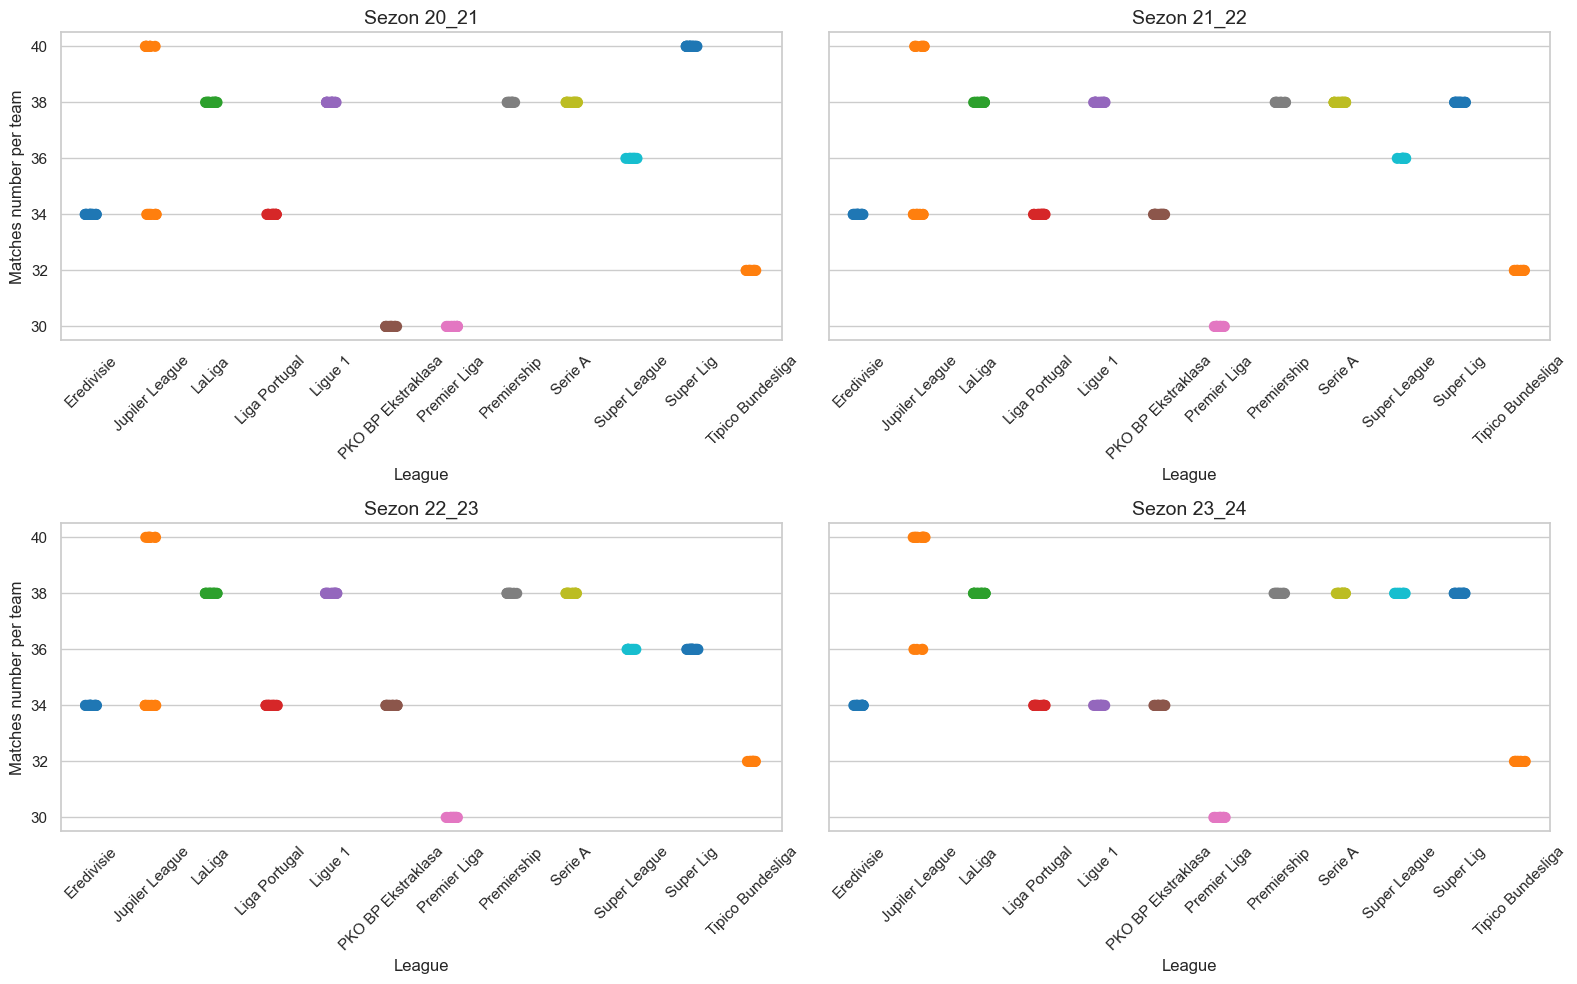

In [173]:
sns.set(style="whitegrid")

num_seasons = len(df_list)
fig, axes = plt.subplots(2, 2, figsize=(16,10), sharey=True)
axes = axes.flatten()

for i, df in enumerate(df_list):
    all_results = []

    for league_name, group in df.groupby('league'):
        teams = pd.concat([group['team_1'], group['team_2']])
        counts = teams.value_counts().reset_index()
        counts.columns = ['team', 'count']
        counts['league'] = league_name
        all_results.append(counts)

    season_df = pd.concat(all_results, ignore_index=True)

    sns.stripplot(
        x='league', y='count', data=season_df,
        jitter=True, size=8, palette="tab10", ax=axes[i]
    )

    axes[i].set_title(f'Sezon {season_labels[i]}', fontsize=14)
    axes[i].set_xlabel('League', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    if i % 2 == 0:
        axes[i].set_ylabel('Matches number per team', fontsize=12)
    else:
        axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

### Time series (approach 2)

to trzeba dokonczyc, dla 3 i 5 meczy w tyl srednie arytmeyczne tych roznych kolumn
potem z tego zrobic df'a do treningu gdzie dane WE beda z 1,3,5 ostatnich meczy - do time series modeli

In [184]:
print(df1.columns)

Index(['match_id', 'date', 'league', 'turn', 'team_1', 'team_2', 'goals_1',
       'goals_2', 'winner', 'possession_1', 'possession_2', 'goal_chances_1',
       'goal_chances_2', 'shots_on_target_1', 'shots_on_target_2',
       'shots_off_target_1', 'shots_off_target_2', 'offsides_1', 'offsides_2',
       'goalkeeper_saves_1', 'goalkeeper_saves_2', 'fouls_1', 'fouls_2',
       'attacks_1', 'attacks_2', 'dangerous_attacks_1', 'dangerous_attacks_2',
       'team_1_formation', 'team_2_formation', 'bet_1', 'bet_x', 'bet_2',
       'red_cards_1', 'red_cards_2', 'month', 'day_of_week', 'shots_1',
       'shots_2', 'player_0_team_1', 'player_0_team_2', 'player_1_team_1',
       'player_1_team_2', 'player_2_team_1', 'player_2_team_2',
       'player_3_team_1', 'player_3_team_2', 'player_4_team_1',
       'player_4_team_2', 'player_5_team_1', 'player_5_team_2',
       'player_6_team_1', 'player_6_team_2', 'player_7_team_1',
       'player_7_team_2', 'player_8_team_1', 'player_8_team_2',
       

In [174]:
def time_series(df: pd.DataFrame, timestamp): # -> pd.DataFrame:
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], format="%d.%m.%Y %H:%M")
    
    results = {}
    # columns that won't be taken for time series
    excluded_columns = ['date', 'league', 'turn', 'team_1', 'team_2', 'winner',
                        'bet_1x', 'bet_12', 'bet_x2', 'bet_1', 'bet_x', 'bet_2']
    
    for ligue, group_df in df.groupby('league'):
        group_df = group_df.sort_values('date').reset_index(drop=True)
        
        base_names = set()
        for col in group_df.columns:
            if col not in excluded_columns:
                # remove sufix _1, _2
                base_name = re.sub(r'_[12]$', '', col)
                # player_3_team_1 -> player_3
                base_name = re.sub(r'_team$', '', base_name)
                # team_1_formation -> formation
                base_name = re.sub(r'^team_[12]_formation$', 'formation', base_name)
                # player_x_team_y to player_x
                base_name = re.sub(r'(player_\d+)_team_[12]', r'\1', base_name)
                base_names.add(base_name)
        
        for team in group_df['team_1'].unique():
            results[team] = {name: [] for name in base_names}
        
        for idx, row in group_df.iterrows():
            team_1 = row['team_1']
            team_2 = row['team_2']
            
            for col in group_df.columns:
                if col in excluded_columns:
                    continue

                # team_1
                if re.search(r'(_1$|_team_1$|_formation$)', col):
                    if col in ['team_1_formation', 'team_2_formation']:
                        base_name = 'formation'
                    else:
                        base_name = re.sub(r'(_team_1|_1)$', '', col)
                        base_name = re.sub(r'(player_\d+)_team_1', r'\1', base_name)
                    value = row[col]
                    results[team_1].setdefault(base_name, []).append(value)

                elif re.search(r'(_2$|_team_2$|_formation$)', col):
                    if col in ['team_1_formation', 'team_2_formation']:
                        base_name = 'formation'
                    else:
                        base_name = re.sub(r'(_team_2|_2)$', '', col)
                        base_name = re.sub(r'(player_\d+)_team_2', r'\1', base_name)
                    value = row[col]
                    results[team_2].setdefault(base_name, []).append(value)
                # elif re.search(r'(_2$|_team_2$)', col):
                #     base_name = re.sub(r'(_team_2|_2)$', '', col)
                #     value = row[col]
                #     results[team_2].setdefault(base_name, []).append(value)

    return results

In [175]:
def time_series_skeleton(df: pd.DataFrame):
    df = df.copy()
    
    excluded_columns = [
        'date', 'league', 'turn', 'team_1', 'team_2', 'winner',
        'bet_1x', 'bet_12', 'bet_x2', 'bet_1', 'bet_x', 'bet_2',
        'match_id']

    results = {}

    for league_name, group_df in df.groupby('league'):
        all_teams = pd.concat([group_df['team_1'], group_df['team_2']]).unique()
        
        # skeleton
        base_names = set()
        for col in group_df.columns:
            if col in excluded_columns:
                continue
            m = re.match(r'(player_\d+)_team_[12]', col)
            if m:
                base_names.add(m.group(1))
                continue
            if col in ['team_1_formation', 'team_2_formation']:
                base_names.add('formation')
                continue
            if col.endswith('_1') or col.endswith('_2'):
                base_names.add(col[:-2])
                continue
            base_names.add(col)

        for team in all_teams:
            if team not in results:
                results[team] = {name: [] for name in base_names}

        # kolumny statystyk (suffix _1 / _2)
        stat_cols = [
            c for c in group_df.columns
            if c not in excluded_columns
            and c not in ['team_1_formation', 'team_2_formation']
            and not re.match(r'player_\d+_team_[12]', c)
            and (c.endswith('_1') or c.endswith('_2'))
        ]
        player_nums = sorted(set(
            re.match(r'(player_\d+)_team_[12]', c).group(1)
            for c in group_df.columns
            if re.match(r'(player_\d+)_team_[12]', c)
        ))

        for _, row in group_df.iterrows():
            for side, team in [('1', row['team_1']), ('2', row['team_2'])]:
                entry = {}

                # statystyki: fouls, goals, possession itd.
                for col in stat_cols:
                    if col.endswith(f'_{side}'):
                        base = col[:-2]
                        entry[base] = row[col]

                # formacja
                entry['formation'] = row[f'team_{side}_formation']

                # gracze
                for p in player_nums:
                    entry[p] = row[f'{p}_team_{side}']

                # dopisz do historii zespołu
                for key, val in entry.items():
                    results[team][key].append(val)

    return results

In [176]:
def all_teams_report(res: dict, df: pd.DataFrame):
    """Raport dla wszystkich drużyn: wypisuje tylko metryki niepełne (skrócona wersja)."""
    for team in sorted(res.keys()):
        expected = int(((df['team_1'] == team) | (df['team_2'] == team)).sum())
        # jeżeli drużyna nie występuje w df, pomin
        if expected == 0:
            print(f"{team}: 0 matches -> skipped")
            continue
        # sprawdź metryki, czy wszystkie mają expected długości
        bad = []
        for metric, values in res[team].items():
            if len(values) != expected:
                bad.append((metric, len(values)))
        if bad:
            print(f"\n{team} (expected={expected}) - {len(bad)} incomplete metrics:")
            for m, l in bad:
                print(f"  {m:30} {l}/{expected}")

for df in df_list:
    res = time_series_skeleton(df)
    all_teams_report(res, df)


AC Milan (expected=38) - 2 incomplete metrics:
  month                          0/38
  day_of_week                    0/38

AS Roma (expected=38) - 2 incomplete metrics:
  month                          0/38
  day_of_week                    0/38

Aberdeen (expected=38) - 2 incomplete metrics:
  month                          0/38
  day_of_week                    0/38

Achmat Grozny (expected=30) - 2 incomplete metrics:
  month                          0/30
  day_of_week                    0/30

Admira (expected=32) - 2 incomplete metrics:
  month                          0/32
  day_of_week                    0/32

Ajax (expected=34) - 2 incomplete metrics:
  month                          0/34
  day_of_week                    0/34

Alanyaspor (expected=40) - 2 incomplete metrics:
  month                          0/40
  day_of_week                    0/40

Alaves (expected=38) - 2 incomplete metrics:
  month                          0/38
  day_of_week                    0/38

Alkmaar (

## Save progress

The dataset has undergone significant transformation. It's recommended to save the transformed version.

The data we will work with is now cleaned and ready. However, additional preparation will be needed to convert it into a format suitable for model training. Currently, each row contains the betting odds for a match along with post-match information such as team ratings and statistics.

For training purposes, we need to restructure the dataset so that each row represents the context before a match — including the upcoming match, the odds for that match, and relevant statistics derived from previous games. This format will enable the model to learn from historical performance and betting patterns to make accurate predictions.

In [185]:
season = {
    0: '20_21',
    1: '21_22',
    2: '22_23',
    3: '23_24'
}

for i, df in enumerate(df_list):
    df.to_csv(f'../data/transformed_data/{season[i]}_transformed.csv', index=False)

In [186]:
def save_time_series(results: dict, season_label: str, output_dir: str = "../data/processed"):
    os.makedirs(output_dir, exist_ok=True)
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(results, f, ensure_ascii=False, indent=2)
    print(f"Saved: {path} ({len(results)} teams)")

season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']

for df, label in zip(df_list, season_labels):
    results = time_series_skeleton(df)
    save_time_series(results, label)

Saved: ../data/processed\season_2020_21.json (201 teams)
Saved: ../data/processed\season_2021_22.json (202 teams)
Saved: ../data/processed\season_2022_23.json (201 teams)
Saved: ../data/processed\season_2023_24.json (200 teams)


In [189]:
joined_df = pd.concat(df_list, ignore_index=True)

In [190]:
joined_df.shape

(14324, 60)

In [191]:
joined_df.columns

Index(['match_id', 'date', 'league', 'turn', 'team_1', 'team_2', 'goals_1',
       'goals_2', 'winner', 'possession_1', 'possession_2', 'goal_chances_1',
       'goal_chances_2', 'shots_on_target_1', 'shots_on_target_2',
       'shots_off_target_1', 'shots_off_target_2', 'offsides_1', 'offsides_2',
       'goalkeeper_saves_1', 'goalkeeper_saves_2', 'fouls_1', 'fouls_2',
       'attacks_1', 'attacks_2', 'dangerous_attacks_1', 'dangerous_attacks_2',
       'team_1_formation', 'team_2_formation', 'bet_1', 'bet_x', 'bet_2',
       'red_cards_1', 'red_cards_2', 'month', 'day_of_week', 'shots_1',
       'shots_2', 'player_0_team_1', 'player_0_team_2', 'player_1_team_1',
       'player_1_team_2', 'player_2_team_1', 'player_2_team_2',
       'player_3_team_1', 'player_3_team_2', 'player_4_team_1',
       'player_4_team_2', 'player_5_team_1', 'player_5_team_2',
       'player_6_team_1', 'player_6_team_2', 'player_7_team_1',
       'player_7_team_2', 'player_8_team_1', 'player_8_team_2',
       

# 5. Models (in progress)

## Preparation

In [18]:
import pandas as pd
import numpy as np
import json
import os
import re
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_is_fitted

In [2]:
df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

df_list = [df1, df2, df3, df4]

In [3]:
def make_winner_scorer(threshold):
    def betting_profit_winner(estimator, X, y_true):
        proba      = estimator.predict_proba(X)
        classes    = estimator.classes_
        confidence = proba.max(axis=1)
        predicted  = classes[proba.argmax(axis=1)]

        X_reset = X.reset_index(drop=True)
        y_reset = np.array(y_true)

        profits = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            if conf < threshold:
                continue
            bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
            if bet_col not in X_reset.columns:
                continue  # brak kursu — pomiń zamiast crashować
            odds = X_reset.iloc[i][bet_col]
            profits.append((odds - 1) if pred == true else -1)

        return np.sum(profits) if profits else np.nan  # ← nan zamiast 0.0
    return betting_profit_winner

def betting_profit_goals(estimator, X, y_true):
    """
    Profit scorer dla modelu goli.
    Przewidujemy goals_1 i goals_2, różnica wskazuje typ zakładu:
      goals_1 > goals_2  → bet_1
      goals_1 < goals_2  → bet_2
      goals_1 == goals_2 → bet_x
    Zwrot: (kurs - 1) za trafienie, -1 za pudło.
    """
    pred  = np.round(estimator.predict(X)).astype(int)
    y_arr = np.array(y_true)

    profits = []
    for i, (p_row, t_row) in enumerate(zip(pred, y_arr)):
        p1, p2 = p_row[0], p_row[1]
        t1, t2 = t_row[0], t_row[1]

        # decyzja na podstawie przewidywanych goli
        if p1 > p2:
            bet_col      = 'bet_1'
            true_outcome = 1
        elif p1 < p2:
            bet_col      = 'bet_2'
            true_outcome = 2
        else:
            bet_col      = 'bet_x'
            true_outcome = 0

        # prawdziwy wynik
        if t1 > t2:
            actual_outcome = 1
        elif t1 < t2:
            actual_outcome = 2
        else:
            actual_outcome = 0

        odds = X.iloc[i][bet_col]
        profits.append((odds - 1) if true_outcome == actual_outcome else -1)

    return np.sum(profits)

## Benchmarks

### Benchmark - expected goals

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# WCZYTANIE DANYCH
# ═══════════════════════════════════════════════════════════════════════════

df_train = pd.concat([df1, df2, df3], ignore_index=True)
df_test = df4.copy()

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA PRZYGOTOWANIA DANYCH
# ═══════════════════════════════════════════════════════════════════════════
def get_Xy(df, targets):
    """Wyciąga X (kursy) i y (cele) z df, usuwa NaNy."""
    df = df.dropna(subset=BET_COLS + (targets if isinstance(targets, list) else [targets]))
    X = df[BET_COLS]
    y = df[targets]
    return X, y, df

# ═══════════════════════════════════════════════════════════════════════════
# SCORER DLA CROSS-VALIDATION Z THRESHOLDEM
# ═══════════════════════════════════════════════════════════════════════════
def make_goals_scorer(draw_threshold):
    """
    Tworzy scorer dla CV.
    Logika:
      - Jeśli |predicted_goals_1 - predicted_goals_2| < draw_threshold → obstawiamy REMIS (bet_x)
      - W przeciwnym razie obstawiamy zwycięzcę (bet_1 lub bet_2)
    """
    def betting_profit_goals_thresh(estimator, X, y_true):
        pred = np.round(estimator.predict(X)).astype(int)
        y_arr = np.array(y_true)
        profits = []
        
        for i, (p_row, t_row) in enumerate(zip(pred, y_arr)):
            p1, p2 = p_row[0], p_row[1]
            t1, t2 = t_row[0], t_row[1]
            diff = abs(p1 - p2)
            
            # Decyzja o zakładzie na podstawie threshold
            if diff < draw_threshold:
                bet_col, pred_out = 'bet_x', 0
            else:
                if p1 > p2:
                    bet_col, pred_out = 'bet_1', 1
                else:
                    bet_col, pred_out = 'bet_2', 2
            
            # Rzeczywisty wynik
            if t1 > t2:
                true_out = 1
            elif t1 < t2:
                true_out = 2
            else:
                true_out = 0
            
            odds = X.iloc[i][bet_col]
            profits.append((odds - 1) if pred_out == true_out else -1)
        
        return np.sum(profits)
    
    return betting_profit_goals_thresh

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA EWALUACJI (dla pełnego datasetu, np. training lub test)
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_goals_predictions(model, X, y, threshold):
    """
    Ewaluuje model na całym zbiorze danych.
    Zwraca: profit, liczba_zakładów, procent_obstawionych, skuteczność
    """
    pred = np.round(model.predict(X)).astype(int)
    profits = []
    placed = 0
    won = 0
    
    for i, (p_row, t_row) in enumerate(zip(pred, y.values)):
        p1, p2 = p_row
        t1, t2 = t_row
        diff = abs(p1 - p2)
        
        # Decyzja o zakładzie
        if diff < threshold:
            bet_col, pred_out = 'bet_x', 0
        else:
            if p1 > p2:
                bet_col, pred_out = 'bet_1', 1
            else:
                bet_col, pred_out = 'bet_2', 2
        
        # Rzeczywisty wynik
        if t1 > t2:
            true_out = 1
        elif t1 < t2:
            true_out = 2
        else:
            true_out = 0
        
        placed += 1
        odds = X.iloc[i][bet_col]
        
        if pred_out == true_out:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# PRZYGOTOWANIE DANYCH I MODELU
# ═══════════════════════════════════════════════════════════════════════════
X_train, y_train, _ = get_Xy(df_train, TARGET_G)
X_test, y_test, _ = get_Xy(df_test, TARGET_G)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# Model: DecisionTree z tymi samymi parametrami
model_goals = MultiOutputRegressor(
    DecisionTreeRegressor(max_depth=4, min_samples_leaf=200, random_state=42)
)

# Cross-validation setup
cv_splits = KFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════
# ITERACJA PO THRESHOLDACH - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
draw_thresholds = np.round(np.arange(0.1, 3.1, 0.1), 2)
cv_results = []

print("\n" + "="*80)
print("CROSS-VALIDATION (5-fold) - TRAINING DATA")
print("="*80)
print(f"{'Threshold':>10} | {'CV profit':>12} | {'CV avg/fold':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 80)

for t in draw_thresholds:
    # Cross-validation z danym thresholdem
    scorer = make_goals_scorer(t)
    cv_scores = cross_val_score(model_goals, X_train, y_train, cv=cv_splits, scoring=scorer)
    
    # Fit na całym train i ewaluacja (dla statystyk)
    m_tmp = clone(model_goals)
    m_tmp.fit(X_train, y_train)
    profit, placed, pct, acc = evaluate_goals_predictions(m_tmp, X_train, y_train, t)
    
    cv_results.append({
        'threshold': t,
        'cv_profit_sum': cv_scores.sum(),
        'cv_profit_avg': cv_scores.mean(),
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{t:>10.2f} | {cv_scores.sum():>12.2f} | {cv_scores.mean():>12.2f} | "
          f"{placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold z CV
best_cv = max(cv_results, key=lambda x: x['cv_profit_sum'])
BEST_THRESHOLD_CV = best_cv['threshold']
print(f"\n✓ Najlepszy threshold (CV): {BEST_THRESHOLD_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")


Train shape: (10760, 3), Test shape: (3564, 3)

CROSS-VALIDATION (5-fold) - TRAINING DATA
 Threshold |    CV profit |  CV avg/fold |   Placed |    % Bet |   Accuracy
--------------------------------------------------------------------------------
      0.10 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.20 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.30 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.40 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.50 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.60 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.70 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.80 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      0.90 |      -222.92 |       -44.58 |    10760 |   100.0% |      47.5%
      1.00 |      -222.92 |       -44.58 |    10760 |   100.0% |     

In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUACJA NA DANYCH TESTOWYCH (df4)
# ═══════════════════════════════════════════════════════════════════════════
# Trenuj finalny model na całym train
model_goals.fit(X_train, y_train)

test_results = []

print("\n" + "="*80)
print(f"TEST DATA (df4) - {len(X_test)} matches")
print("="*80)
print(f"{'Threshold':>10} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 80)

for t in draw_thresholds:
    profit, placed, pct, acc = evaluate_goals_predictions(model_goals, X_test, y_test, t)
    
    test_results.append({
        'threshold': t,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{t:>10.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold na teście
best_test = max(test_results, key=lambda x: x['profit'])
BEST_THRESHOLD_TEST = best_test['threshold']
print(f"\n✓ Najlepszy threshold (TEST): {BEST_THRESHOLD_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Threshold z CV był:          {BEST_THRESHOLD_CV}")



TEST DATA (df4) - 3564 matches
 Threshold |       Profit |   Placed |    % Bet |   Accuracy
--------------------------------------------------------------------------------
      0.10 |       125.68 |     3564 |   100.0% |      49.4%
      0.20 |       125.68 |     3564 |   100.0% |      49.4%
      0.30 |       125.68 |     3564 |   100.0% |      49.4%
      0.40 |       125.68 |     3564 |   100.0% |      49.4%
      0.50 |       125.68 |     3564 |   100.0% |      49.4%
      0.60 |       125.68 |     3564 |   100.0% |      49.4%
      0.70 |       125.68 |     3564 |   100.0% |      49.4%
      0.80 |       125.68 |     3564 |   100.0% |      49.4%
      0.90 |       125.68 |     3564 |   100.0% |      49.4%
      1.00 |       125.68 |     3564 |   100.0% |      49.4%
      1.10 |       125.29 |     3564 |   100.0% |      31.1%
      1.20 |       125.29 |     3564 |   100.0% |      31.1%
      1.30 |       125.29 |     3564 |   100.0% |      31.1%
      1.40 |       125.29 |     3

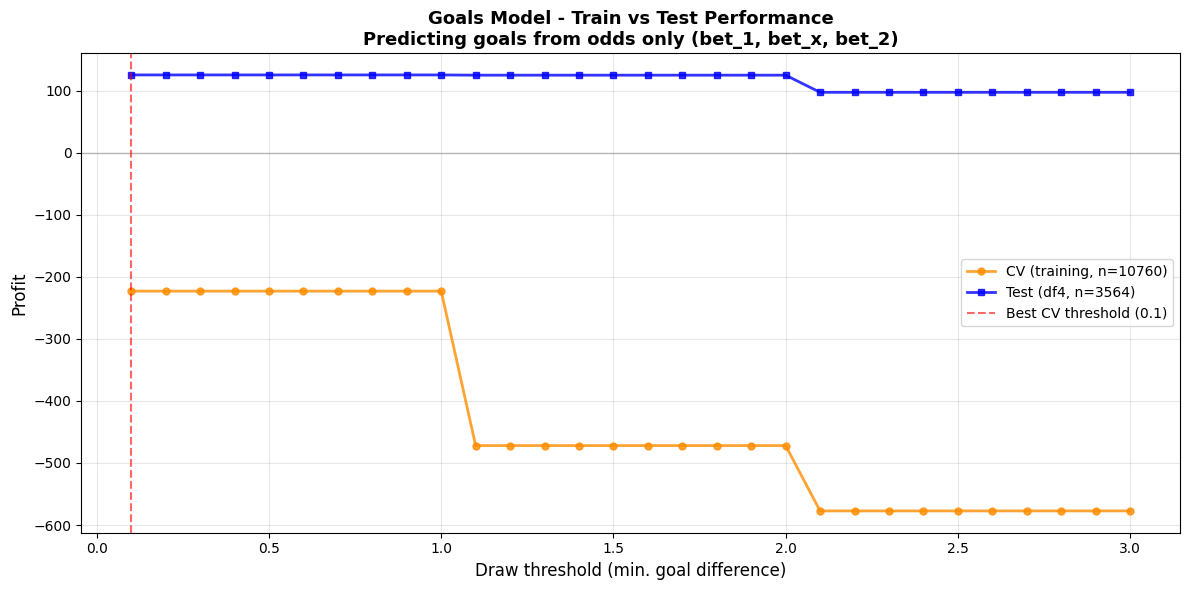

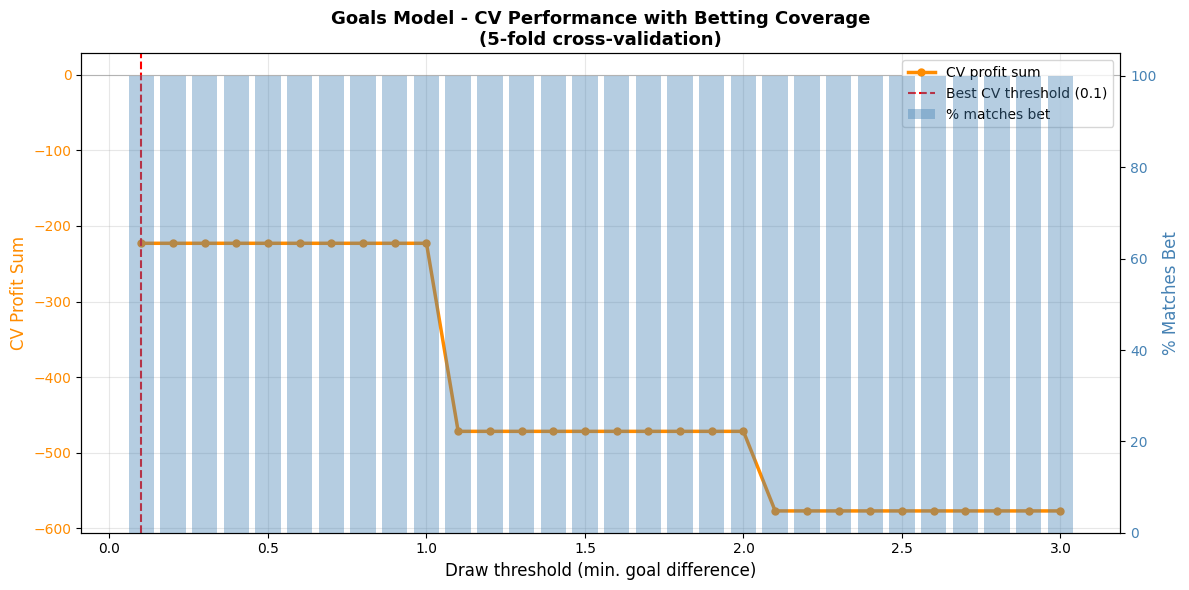

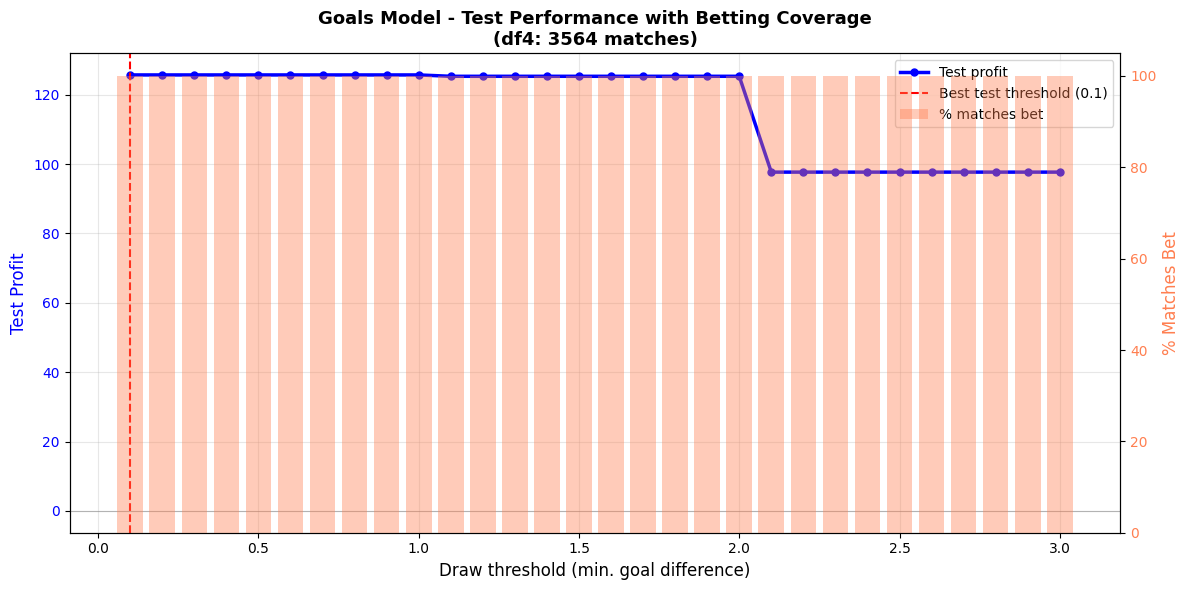


GOTOWE! Zapisane wykresy:
  - goals_cv_vs_test_sidebyside.png
  - goals_train_vs_test_overlay.png
  - goals_cv_with_coverage.png
  - goals_test_with_coverage.png


In [ ]:

# ═══════════════════════════════════════════════════════════════════════════
# WYKRESY
# ═══════════════════════════════════════════════════════════════════════════

# Dane do wykresów
thresholds_cv = [r['threshold'] for r in cv_results]
profits_cv = [r['cv_profit_sum'] for r in cv_results]
pct_cv = [r['pct'] for r in cv_results]

thresholds_test = [r['threshold'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]


# ────────────────────────────────────────────────────────────────────────────
# WYKRES 2: OVERLAY - oba na jednym wykresie
# ────────────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plt.plot(thresholds_cv, profits_cv, marker='o', markersize=5, 
         color='darkorange', linewidth=2, label=f'CV (training, n={len(X_train)})', alpha=0.8)
plt.plot(thresholds_test, profits_test, marker='s', markersize=5, 
         color='blue', linewidth=2, label=f'Test (df4, n={len(X_test)})', alpha=0.8)
plt.axhline(0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
plt.axvline(BEST_THRESHOLD_CV, color='red', linestyle='--', 
            alpha=0.6, linewidth=1.5, label=f'Best CV threshold ({BEST_THRESHOLD_CV})')
plt.xlabel('Draw threshold (min. goal difference)', fontsize=12)
plt.ylabel('Profit', fontsize=12)
plt.title('Goals Model - Train vs Test Performance\nPredicting goals from odds only (bet_1, bet_x, bet_2)', 
          fontsize=13, fontweight='bold')
plt.xticks(np.arange(0, 3.5, 0.5))
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────────────────
# WYKRES 3: CV z dwoma osiami (profit + % obstawionych)
# ────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))

# Lewa oś: profit
color_profit = 'darkorange'
ax1.plot(thresholds_cv, profits_cv, marker='o', markersize=5, 
         color=color_profit, linewidth=2.5, label='CV profit sum')
ax1.axvline(BEST_THRESHOLD_CV, color='red', linestyle='--', linewidth=1.5,
            label=f'Best CV threshold ({BEST_THRESHOLD_CV})')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Draw threshold (min. goal difference)', fontsize=12)
ax1.set_ylabel('CV Profit Sum', color=color_profit, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_profit)
ax1.set_xticks(np.arange(0, 3.5, 0.5))
ax1.grid(True, alpha=0.3)

# Prawa oś: % obstawionych
ax2 = ax1.twinx()
color_pct = 'steelblue'
ax2.bar(thresholds_cv, pct_cv, width=0.08, alpha=0.4, color=color_pct, label='% matches bet')
ax2.set_ylabel('% Matches Bet', color=color_pct, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pct)
ax2.set_ylim(0, 105)

# Tytuł i legendy
ax1.set_title('Goals Model - CV Performance with Betting Coverage\n(5-fold cross-validation)', 
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────────────────
# WYKRES 4: TEST z dwoma osiami (profit + % obstawionych)
# ────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 6))

# Lewa oś: profit
color_profit = 'blue'
ax1.plot(thresholds_test, profits_test, marker='o', markersize=5, 
         color=color_profit, linewidth=2.5, label='Test profit')
ax1.axvline(BEST_THRESHOLD_TEST, color='red', linestyle='--', linewidth=1.5,
            label=f'Best test threshold ({BEST_THRESHOLD_TEST})')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax1.set_xlabel('Draw threshold (min. goal difference)', fontsize=12)
ax1.set_ylabel('Test Profit', color=color_profit, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_profit)
ax1.set_xticks(np.arange(0, 3.5, 0.5))
ax1.grid(True, alpha=0.3)

# Prawa oś: % obstawionych
ax2 = ax1.twinx()
color_pct = 'coral'
ax2.bar(thresholds_test, pct_test, width=0.08, alpha=0.4, color=color_pct, label='% matches bet')
ax2.set_ylabel('% Matches Bet', color=color_pct, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_pct)
ax2.set_ylim(0, 105)

# Tytuł i legendy
ax1.set_title(f'Goals Model - Test Performance with Betting Coverage\n(df4: {len(X_test)} matches)', 
              fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("GOTOWE! Zapisane wykresy:")
print("  - goals_cv_vs_test_sidebyside.png")
print("  - goals_train_vs_test_overlay.png")
print("  - goals_cv_with_coverage.png")
print("  - goals_test_with_coverage.png")
print("="*80)

### Benchmark - win/draw/lose

In [8]:
df_train = pd.concat([df1, df2, df3], ignore_index=True)
df_test = df4.copy()

BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'

def get_Xy(df, target):
    """Wyciąga X (kursy) i y (target) z df, usuwa NaNy."""
    df = df.dropna(subset=BET_COLS + [target])
    X = df[BET_COLS]
    y = df[target]
    return X, y, df

# ═══════════════════════════════════════════════════════════════════════════
# SCORER DLA CROSS-VALIDATION Z CONFIDENCE THRESHOLD
# ═══════════════════════════════════════════════════════════════════════════
def make_winner_scorer(confidence_threshold):
    """
    Tworzy scorer dla CV.
    Logika:
      - Jeśli max(proba) < confidence_threshold → POMIJAMY zakład (continue)
      - W przeciwnym razie → obstawiamy klasę z najwyższym prawdopodobieństwem
    
    Zwraca sumę profitów.
    """
    def betting_profit_winner(estimator, X, y_true):
        proba = estimator.predict_proba(X)
        classes = estimator.classes_
        confidence = proba.max(axis=1)
        predicted = classes[proba.argmax(axis=1)]
        
        X_reset = X.reset_index(drop=True)
        y_reset = np.array(y_true)
        
        profits = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            # Jeśli pewność < threshold → pomijamy zakład
            if conf < confidence_threshold:
                continue
            
            # Mapowanie predykcji na kolumnę kursu
            bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
            odds = X_reset.iloc[i][bet_col]
            
            # Profit
            profits.append((odds - 1) if pred == true else -1)
        
        return np.sum(profits) if profits else 0.0
    
    return betting_profit_winner

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA EWALUACJI (dla pełnego datasetu)
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    """
    Ewaluuje model klasyfikacji zwycięzcy na całym zbiorze danych.
    Zwraca: profit, liczba_zakładów, procent_obstawionych, skuteczność
    """
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        # Jeśli pewność < threshold → pomijamy zakład
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        # Mapowanie predykcji na kolumnę kursu
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        odds = X_reset.iloc[i][bet_col]
        
        # Profit
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# PRZYGOTOWANIE DANYCH I MODELU
# ═══════════════════════════════════════════════════════════════════════════
X_train, y_train, _ = get_Xy(df_train, TARGET_W)
X_test, y_test, _ = get_Xy(df_test, TARGET_W)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts()}")
print(f"Test target distribution:\n{y_test.value_counts()}")

# Model: DecisionTree classifier z tymi samymi parametrami co w wersji regresji
model_winner = DecisionTreeClassifier(
    max_depth=4, 
    min_samples_leaf=200, 
    random_state=42
)

# Cross-validation setup
cv_splits = KFold(n_splits=5, shuffle=True, random_state=42)

Train shape: (10760, 3), Test shape: (3564, 3)
Train target distribution:
winner
1.0    4594
2.0    3465
0.0    2701
Name: count, dtype: int64
Test target distribution:
winner
1.0    1548
2.0    1050
0.0     966
Name: count, dtype: int64


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
# ITERACJA PO CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
# Threshold = minimalna pewność modelu aby obstawić zakład
# 0.33 = losowe (równe prawdopodobieństwa dla 3 klas)
# 0.50 = model musi być pewny przynajmniej 50%
# 0.80 = bardzo pewne predykcje
confidence_thresholds = np.round(np.arange(0.33, 0.95, 0.02), 2)
cv_results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TRAINING DATA - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'CV avg/fold':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    # Cross-validation z danym thresholdem
    scorer = make_winner_scorer(conf_threshold)
    cv_scores = cross_val_score(model_winner, X_train, y_train, cv=cv_splits, scoring=scorer)
    
    # Fit na całym train i ewaluacja (dla statystyk)
    m_tmp = clone(model_winner)
    m_tmp.fit(X_train, y_train)
    profit, placed, pct, acc = evaluate_winner_predictions(m_tmp, X_train, y_train, conf_threshold)
    
    cv_results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': cv_scores.sum(),
        'cv_profit_avg': cv_scores.mean(),
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {cv_scores.sum():>12.2f} | {cv_scores.mean():>12.2f} | "
          f"{placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold z CV
best_cv = max(cv_results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\n✓ Najlepszy confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")



CROSS-VALIDATION (5-fold) - TRAINING DATA - WINNER CLASSIFICATION
 Confidence |    CV profit |  CV avg/fold |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |       -98.57 |       -19.71 |    10760 |   100.0% |      53.4%
       0.35 |       -98.57 |       -19.71 |    10760 |   100.0% |      53.4%
       0.37 |      -128.22 |       -25.64 |    10760 |   100.0% |      53.4%
       0.39 |      -126.35 |       -25.27 |     9115 |    84.7% |      56.1%
       0.41 |       -70.56 |       -14.11 |     7833 |    72.8% |      58.6%
       0.43 |       -35.20 |        -7.04 |     7833 |    72.8% |      58.6%
       0.45 |       -63.81 |       -12.76 |     6450 |    59.9% |      61.6%
       0.47 |       -18.22 |        -3.64 |     6450 |    59.9% |      61.6%
       0.49 |       -45.02 |        -9.00 |     5662 |    52.6% |      63.4%
       0.51 |       -52.58 |       -10.52 |     4611 |    42.9% |      6

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUACJA NA DANYCH TESTOWYCH (df4)
# ═══════════════════════════════════════════════════════════════════════════
# Trenuj finalny model na całym train
model_winner.fit(X_train, y_train)

test_results = []

print("\n" + "="*90)
print(f"TEST DATA (df4) - {len(X_test)} matches - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc = evaluate_winner_predictions(model_winner, X_test, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold na teście
best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\n✓ Najlepszy confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Confidence threshold z CV był:          {BEST_CONFIDENCE_CV}")


TEST DATA (df4) - 3564 matches - WINNER CLASSIFICATION
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -108.92 |     3564 |   100.0% |      52.9%
       0.35 |      -108.92 |     3564 |   100.0% |      52.9%
       0.37 |      -108.92 |     3564 |   100.0% |      52.9%
       0.39 |       -54.80 |     3017 |    84.7% |      56.0%
       0.41 |       -39.64 |     2620 |    73.5% |      58.4%
       0.43 |       -39.64 |     2620 |    73.5% |      58.4%
       0.45 |       -22.51 |     2126 |    59.7% |      61.6%
       0.47 |       -22.51 |     2126 |    59.7% |      61.6%
       0.49 |       -10.20 |     1902 |    53.4% |      63.5%
       0.51 |        16.56 |     1555 |    43.6% |      66.9%
       0.53 |        16.56 |     1555 |    43.6% |      66.9%
       0.55 |       -15.03 |     1055 |    29.6% |      70.5%
       0.57 |       -15.03 |     1055 |    29.6

In [12]:
# Dane do wykresów
confidences_cv = [r['confidence'] for r in cv_results]
profits_cv = [r['cv_profit_sum'] for r in cv_results]
pct_cv = [r['pct'] for r in cv_results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, profits_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label=f'CV profit (n={len(X_train)})', alpha=0.8)

ax.plot(confidences_test, profits_test,marker='s', markersize=5,color='blue', linewidth=2,label=f'Test profit (df4, n={len(X_test)})', alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("Profit")
ax.set_title("Winner Model — Profit vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. % OBSTAWIONYCH (BAR)
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')

ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
acc_cv = [r['acc'] for r in cv_results]
acc_test = [r['acc'] for r in test_results]

ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')

ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

In [ ]:
# ── TREE VISUALIZATION ─────────────────────────────────────────────────────────

def plot_model(model, title, class_names=None):
    tree = model.estimators_[0] if hasattr(model, 'estimators_') else model
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(tree, feature_names=BET_COLS,
              class_names=class_names,
              filled=True, rounded=True, ax=ax, fontsize=9)
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=150)
    plt.show()
    print(export_text(tree, feature_names=BET_COLS))

plot_model(model_winner, "Model_Winner", class_names=['remis', 'gospodarz', 'gosc'])
plot_model(model_goals,  "Model_Goals_1_tree")

## Model 1 - DT

### load data - blueprint do dalszych do rekonstrukcji ładowania danych

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']  # kolumny do pominięcia
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJE POMOCNICZE
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    """Ładuje JSON z danymi time series."""
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    """
    Konwertuje time series drużyny na DataFrame.
    
    Input (JSON):
      ts_data[team] = {
        'player_3': [7.5, 6.9, 7.8, ...],  # 34 mecze
        'attacks': [102, 129, 98, ...],     # 34 mecze
        ...
      }
    
    Output (DataFrame):
      match_number | player_3 | attacks | ...
      0            | 7.5      | 102     | ...
      1            | 6.9      | 129     | ...
      ...
    """
    if team not in ts_data:
        raise KeyError(f"Drużyna '{team}' nie istnieje w time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Oczekiwano słownika dla {team}, otrzymano {type(team_data)}")
    
    # Sprawdź długości
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"Brak list w danych dla drużyny {team}")
    
    # Jeśli różne długości - weź najczęstszą
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    # Utwórz DataFrame - każda lista to kolumna
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# GŁÓWNA FUNKCJA - BUDOWA DANYCH TRENINGOWYCH
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    """
    Buduje features z poprzednich meczów drużyn.
    
    Args:
        df_raw: DataFrame z meczami (musi mieć: team_1, team_2, date, bet_1/x/2, winner, goals_1/2)
        ts_data: słownik z time series {team_name: {stat: [wartości]}}
    
    Returns:
        DataFrame z features (home_prev_*, away_prev_*) + kursy + targets
    """
    rows = []
    team_match_counter = {}  # zlicza ile razy zespół już wystąpił
    
    # Sortuj chronologicznie
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    
    print(f"Przetwarzam {len(df_sorted)} meczów...")
    
    for idx, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']
        
        # Inicjalizuj countery
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
        
        # Aktualne indexy meczów (0-based)
        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        
        # Zwiększ countery
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1
        
        # Pomiń pierwszy mecz każdej drużyny (brak historii)
        if idx_1 == 0 or idx_2 == 0:
            continue
        
        # Sprawdź czy drużyny są w time series
        if team_1 not in ts_data or team_2 not in ts_data:
            continue
        
        # Konwertuj time series na DataFrame
        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  ⚠️ Błąd konwersji dla {team_1} lub {team_2}: {e}")
            continue
        
        # Index poprzedniego meczu (idx_1 to aktualny mecz w liczeniu od 0, więc poprzedni = idx_1 - 1)
        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1
        
        # Sprawdź czy mamy tyle meczów w historii
        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue
        
        # Pobierz dane z poprzedniego meczu
        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]
        
        # Buduj wiersz features
        row = {}
        
        # Features z poprzedniego meczu gospodarzy
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        
        # Features z poprzedniego meczu gości
        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]
        
        # Dodaj numer meczu dla każdej drużyny
        row['home_match_number'] = idx_1 + 1  # +1 bo liczymy od 1
        row['away_match_number'] = idx_2 + 1
        
        # Kursy na ten mecz
        for bc in BET_COLS:
            row[bc] = match[bc]
        
        # Targets
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        
        # Metadata
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']
        
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    print(f"  ✓ Utworzono {len(df_result)} wierszy treningowych")
    
    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# ŁADOWANIE DANYCH SUROWYCH (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("ŁADOWANIE DANYCH SUROWYCH")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\n⚠️ BRAKUJĄCE KOLUMNY w df1: {missing_cols}")
    print(f"Dostępne kolumny: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TRENINGOWEGO
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUDOWA DANYCH TRENINGOWYCH")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} drużyn")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Wynik: {len(built)} wierszy, {built['team_1'].nunique()} unikalnych team_1")

# Połącz wszystkie sezony treningowe
df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TESTOWEGO
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


ŁADOWANIE DANYCH SUROWYCH

BUDOWA DANYCH TRENINGOWYCH

[2020_21]
  Time series: 201 drużyn
Przetwarzam 3582 meczów...
  ✓ Utworzono 3470 wierszy treningowych
  Wynik: 3470 wierszy, 201 unikalnych team_1

[2021_22]
  Time series: 202 drużyn
Przetwarzam 3608 meczów...
  ✓ Utworzono 3507 wierszy treningowych
  Wynik: 3507 wierszy, 202 unikalnych team_1

[2022_23]
  Time series: 201 drużyn
Przetwarzam 3570 meczów...
  ✓ Utworzono 3468 wierszy treningowych
  Wynik: 3468 wierszy, 201 unikalnych team_1
Przetwarzam 3564 meczów...
  ✓ Utworzono 3464 wierszy treningowych


### All columns, exclude teams formation and odds

Just run  **model run for all DT models**

### All columns, excluded teams formation, added aggregation players

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 1 — GRUPOWANIE GRACZY WG POZYCJI
# ═══════════════════════════════════════════════════════════════════════════════
# gk- goal keeper

def parse_formation(formation_str):
    """
    Parsuje string formacji np. '4 - 2 - 3 - 1'
    Zwraca (n_def, n_mid, n_att) — bramkarz (player_0) osobno.
    Ostatnia liczba = napastnicy, pierwsza = obrońcy, środkowe = pomocnicy.
    """
    if not isinstance(formation_str, str):
        return None, None, None
    nums = [int(x.strip()) for x in re.findall(r'\d+', formation_str)]
    if len(nums) < 2:
        return None, None, None
    n_def = nums[0]
    n_att = nums[-1]
    n_mid = sum(nums[1:-1])
    return n_def, n_mid, n_att

def add_position_features(row, hist, prev_idx, prefix):
    """
    Converts player ratings into stable position features:
    - GK rating
    - DEF average rating
    - MID average rating
    - ATT average rating
    """

    formation = hist.iloc[prev_idx].get('formation', None)
    n_def, n_mid, n_att = parse_formation(formation)

    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )

    ratings = []
    for pc in player_cols:
        val = hist.iloc[prev_idx][pc]
        try:
            ratings.append(float(val))
        except:
            ratings.append(np.nan)

    if len(ratings) == 0:
        return row

    ratings = np.array(ratings, dtype=float)

    # GK
    row[f'{prefix}_gk_rating'] = ratings[0] if len(ratings) > 0 else np.nan

    field = ratings[1:]

    def safe_mean(x):
        return np.nanmean(x) if len(x) > 0 else np.nan

    # fallback jeśli brak formacji
    if n_def is None or n_mid is None or n_att is None:
        row[f'{prefix}_def_rating'] = safe_mean(field[:4])
        row[f'{prefix}_mid_rating'] = safe_mean(field[4:8])
        row[f'{prefix}_att_rating'] = safe_mean(field[8:])
        return row

    # DEF
    def_part = field[:n_def]
    mid_att = field[n_def:]

    # ATT
    att_part = mid_att[-n_att:] if n_att > 0 else np.array([])
    # MID
    mid_part = mid_att[:-n_att] if n_att > 0 else mid_att

    row[f'{prefix}_def_rating'] = safe_mean(def_part)
    row[f'{prefix}_mid_rating'] = safe_mean(mid_part)
    row[f'{prefix}_att_rating'] = safe_mean(att_part)

    return row


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']  # kolumny do pominięcia
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJE POMOCNICZE
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    """Ładuje JSON z danymi time series."""
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    """
    Konwertuje time series drużyny na DataFrame.
    
    Input (JSON):
      ts_data[team] = {
        'player_3': [7.5, 6.9, 7.8, ...],  # 34 mecze
        'attacks': [102, 129, 98, ...],     # 34 mecze
        ...
      }
    
    Output (DataFrame):
      match_number | player_3 | attacks | ...
      0            | 7.5      | 102     | ...
      1            | 6.9      | 129     | ...
      ...
    """
    if team not in ts_data:
        raise KeyError(f"Drużyna '{team}' nie istnieje w time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Oczekiwano słownika dla {team}, otrzymano {type(team_data)}")
    
    # Sprawdź długości
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"Brak list w danych dla drużyny {team}")
    
    # Jeśli różne długości - weź najczęstszą
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    # Utwórz DataFrame - każda lista to kolumna
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# GŁÓWNA FUNKCJA - BUDOWA DANYCH TRENINGOWYCH
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    """
    Buduje features z poprzednich meczów drużyn.
    
    Args:
        df_raw: DataFrame z meczami (musi mieć: team_1, team_2, date, bet_1/x/2, winner, goals_1/2)
        ts_data: słownik z time series {team_name: {stat: [wartości]}}
    
    Returns:
        DataFrame z features (home_prev_*, away_prev_*) + kursy + targets
    """
    rows = []
    team_match_counter = {}  # zlicza ile razy zespół już wystąpił
    
    # Sortuj chronologicznie
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    
    print(f"Przetwarzam {len(df_sorted)} meczów...")
    
    for idx, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']
        
        # Inicjalizuj countery
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
        
        # Aktualne indexy meczów (0-based)
        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        
        # Zwiększ countery
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1
        
        # Pomiń pierwszy mecz każdej drużyny (brak historii)
        if idx_1 == 0 or idx_2 == 0:
            continue
        
        # Sprawdź czy drużyny są w time series
        if team_1 not in ts_data or team_2 not in ts_data:
            continue
        
        # Konwertuj time series na DataFrame
        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  ⚠️ Błąd konwersji dla {team_1} lub {team_2}: {e}")
            continue
        
        # Index poprzedniego meczu (idx_1 to aktualny mecz w liczeniu od 0, więc poprzedni = idx_1 - 1)
        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1
        
        # Sprawdź czy mamy tyle meczów w historii
        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue
        
        # Pobierz dane z poprzedniego meczu
        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]
        
        # Buduj wiersz features
        row = {}
        row = add_position_features(row, hist_1, prev_idx_1, "home")
        row = add_position_features(row, hist_2, prev_idx_2, "away")
        
        # Features z poprzedniego meczu gospodarzy
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):   # 🚫 KLUCZOWA LINIA
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        
        # Features z poprzedniego meczu gości
        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]
        
        # Dodaj numer meczu dla każdej drużyny
        row['home_match_number'] = idx_1 + 1  # +1 bo liczymy od 1
        row['away_match_number'] = idx_2 + 1
        
        # Kursy na ten mecz
        for bc in BET_COLS:
            row[bc] = match[bc]
        
        # Targets
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        
        # Metadata
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']
        
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    print(f"  ✓ Utworzono {len(df_result)} wierszy treningowych")
    
    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# ŁADOWANIE DANYCH SUROWYCH (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("ŁADOWANIE DANYCH SUROWYCH")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\n⚠️ BRAKUJĄCE KOLUMNY w df1: {missing_cols}")
    print(f"Dostępne kolumny: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TRENINGOWEGO
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUDOWA DANYCH TRENINGOWYCH")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} drużyn")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Wynik: {len(built)} wierszy, {built['team_1'].nunique()} unikalnych team_1")

# Połącz wszystkie sezony treningowe
df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TESTOWEGO
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


ŁADOWANIE DANYCH SUROWYCH

BUDOWA DANYCH TRENINGOWYCH

[2020_21]
  Time series: 201 drużyn
Przetwarzam 3582 meczów...
  ✓ Utworzono 3470 wierszy treningowych
  Wynik: 3470 wierszy, 201 unikalnych team_1

[2021_22]
  Time series: 202 drużyn
Przetwarzam 3608 meczów...
  ✓ Utworzono 3507 wierszy treningowych
  Wynik: 3507 wierszy, 202 unikalnych team_1

[2022_23]
  Time series: 201 drużyn
Przetwarzam 3570 meczów...
  ✓ Utworzono 3468 wierszy treningowych
  Wynik: 3468 wierszy, 201 unikalnych team_1
Przetwarzam 3564 meczów...
  ✓ Utworzono 3464 wierszy treningowych


### Previous + sum of points per team , added efficiency

Result - 4max depth, min 200 samples leaf DT was build using mailny (or only) points for team home/away

Later added efficiency features and tested again - but still only 'points' home/away team decisions in tree

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 1 — GRUPOWANIE GRACZY WG POZYCJI - OCENY ZAWODNIKOW
# ═══════════════════════════════════════════════════════════════════════════════
# gk- goal keeper

def parse_formation(formation_str):
    """
    Parsuje string formacji np. '4 - 2 - 3 - 1'
    Zwraca (n_def, n_mid, n_att) — bramkarz (player_0) osobno.
    Ostatnia liczba = napastnicy, pierwsza = obrońcy, środkowe = pomocnicy.
    """
    if not isinstance(formation_str, str):
        return None, None, None
    nums = [int(x.strip()) for x in re.findall(r'\d+', formation_str)]
    if len(nums) < 2:
        return None, None, None
    n_def = nums[0]
    n_att = nums[-1]
    n_mid = sum(nums[1:-1])
    return n_def, n_mid, n_att

def add_position_features(row, hist, prev_idx, prefix):
    """
    Converts player ratings into stable position features:
    - GK rating
    - DEF average rating
    - MID average rating
    - ATT average rating
    """

    formation = hist.iloc[prev_idx].get('formation', None)
    n_def, n_mid, n_att = parse_formation(formation)

    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )

    ratings = []
    for pc in player_cols:
        val = hist.iloc[prev_idx][pc]
        try:
            ratings.append(float(val))
        except:
            ratings.append(np.nan)

    if len(ratings) == 0:
        return row

    ratings = np.array(ratings, dtype=float)

    # GK
    row[f'{prefix}_gk_rating'] = ratings[0] if len(ratings) > 0 else np.nan

    field = ratings[1:]

    def safe_mean(x):
        return np.nanmean(x) if len(x) > 0 else np.nan

    # fallback jeśli brak formacji
    if n_def is None or n_mid is None or n_att is None:
        row[f'{prefix}_def_rating'] = safe_mean(field[:4])
        row[f'{prefix}_mid_rating'] = safe_mean(field[4:8])
        row[f'{prefix}_att_rating'] = safe_mean(field[8:])
        return row

    # DEF
    def_part = field[:n_def]
    mid_att = field[n_def:]

    # ATT
    att_part = mid_att[-n_att:] if n_att > 0 else np.array([])
    # MID
    mid_part = mid_att[:-n_att] if n_att > 0 else mid_att

    row[f'{prefix}_def_rating'] = safe_mean(def_part)
    row[f'{prefix}_mid_rating'] = safe_mean(mid_part)
    row[f'{prefix}_att_rating'] = safe_mean(att_part)

    return row


In [25]:
def add_efficiency_features(row, prefix):
    def get(col):
        try:
            val = row.get(f"{prefix}_{col}")
            return float(val) if val is not None else 0.0
        except (TypeError, ValueError):
            return 0.0

    attacks = get("attacks")
    shots = get("shots")
    shots_on = get("shots_on_target")
    shots_off = get("shots_off_target")
    goals = get("goals")
    danger = get("dangerous_attacks")
    chances = get("goal_chances")
    possession = get("possession")
    fouls = get("fouls")
    reds = get("red_cards")

    # ─────────────────────────────────────────────
    # OFFENSIVE EFFICIENCY
    # ─────────────────────────────────────────────

    row[f"{prefix}_xg_proxy"] = chances / attacks if attacks > 0 else 0
    row[f"{prefix}_conversion_rate"] = goals / shots_on if shots_on > 0 else 0
    row[f"{prefix}_shot_quality"] = shots_on / shots if shots > 0 else 0
    row[f"{prefix}_finishing_efficiency"] = goals / attacks if attacks > 0 else 0

    # ─────────────────────────────────────────────
    # PRESSURE / CONTROL
    # ─────────────────────────────────────────────

    row[f"{prefix}_attack_pressure"] = shots_on / attacks if attacks > 0 else 0
    row[f"{prefix}_danger_ratio"] = danger / attacks if attacks > 0 else 0
    row[f"{prefix}_possession_efficiency"] = shots_on / possession if possession > 0 else 0

    # ─────────────────────────────────────────────
    # DEFENSIVE / DISCIPLINE
    # ─────────────────────────────────────────────

    row[f"{prefix}_discipline_cost"] = fouls + 3 * reds
    row[f"{prefix}_defensive_noise"] = shots_off / shots if shots > 0 else 0

    return row

In [26]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']  # kolumny do pominięcia
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJE POMOCNICZE
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    """Ładuje JSON z danymi time series."""
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    """
    Konwertuje time series drużyny na DataFrame.
    
    Input (JSON):
      ts_data[team] = {
        'player_3': [7.5, 6.9, 7.8, ...],  # 34 mecze
        'attacks': [102, 129, 98, ...],     # 34 mecze
        ...
      }
    
    Output (DataFrame):
      match_number | player_3 | attacks | ...
      0            | 7.5      | 102     | ...
      1            | 6.9      | 129     | ...
      ...
    """
    if team not in ts_data:
        raise KeyError(f"Drużyna '{team}' nie istnieje w time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Oczekiwano słownika dla {team}, otrzymano {type(team_data)}")
    
    # Sprawdź długości
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"Brak list w danych dla drużyny {team}")
    
    # Jeśli różne długości - weź najczęstszą
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    # Utwórz DataFrame - każda lista to kolumna
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# GŁÓWNA FUNKCJA - BUDOWA DANYCH TRENINGOWYCH
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    """
    Buduje features z poprzednich meczów drużyn.
    
    Args:
        df_raw: DataFrame z meczami (musi mieć: team_1, team_2, date, bet_1/x/2, winner, goals_1/2)
        ts_data: słownik z time series {team_name: {stat: [wartości]}}
    
    Returns:
        DataFrame z features (home_prev_*, away_prev_*) + kursy + targets
    """
    
    team_points = {}
    rows = []
    team_match_counter = {}

    df_sorted = df_raw.sort_values('date').reset_index(drop=True)

    print(f"Przetwarzam {len(df_sorted)} meczów...")

    for idx, match in df_sorted.iterrows():

        team_1 = match['team_1']
        team_2 = match['team_2']

        # init stats
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
            if team not in team_points:          # 🔥 NOWE
                team_points[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]

        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue

        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  ⚠️ Błąd konwersji dla {team_1} lub {team_2}: {e}")
            continue

        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # ─────────────────────────────────────────────
        # POSITION FEATURES
        # ─────────────────────────────────────────────
        row = add_position_features(row, hist_1, prev_idx_1, "home")
        row = add_position_features(row, hist_2, prev_idx_2, "away")
        
        
        # ─────────────────────────────────────────────
        # EFFICIENCY FEATURES
        # ─────────────────────────────────────────────
        row = add_efficiency_features(row, "home")
        row = add_efficiency_features(row, "away")

        # ─────────────────────────────────────────────
        # PREV MATCH FEATURES (bez player_*)
        # ─────────────────────────────────────────────
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'home_prev_{col}'] = prev_1[col]

        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        # ─────────────────────────────────────────────
        # POINTS FEATURE (PRZED MECZEM)
        # ─────────────────────────────────────────────
        row['home_points'] = team_points[team_1]
        row['away_points'] = team_points[team_2]

        # ─────────────────────────────────────────────
        # MATCH INDEX
        # ─────────────────────────────────────────────
        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        # ─────────────────────────────────────────────
        # ODDS
        # ─────────────────────────────────────────────
        for bc in BET_COLS:
            row[bc] = match[bc]

        # ─────────────────────────────────────────────
        # TARGETS
        # ─────────────────────────────────────────────
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']

        # ─────────────────────────────────────────────
        # METADATA
        # ─────────────────────────────────────────────
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']

        rows.append(row)

        # ─────────────────────────────────────────────
        # 🔥 UPDATE POINTS (PO MECZU)
        # ─────────────────────────────────────────────
        winner = match[TARGET_W]

        if winner == 1:
            team_points[team_1] += 3
        elif winner == 0:
            team_points[team_1] += 1
            team_points[team_2] += 1
        else:
            team_points[team_2] += 3

    df_result = pd.DataFrame(rows)
    print(f"  ✓ Utworzono {len(df_result)} wierszy treningowych")

    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# ŁADOWANIE DANYCH SUROWYCH (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("ŁADOWANIE DANYCH SUROWYCH")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\n⚠️ BRAKUJĄCE KOLUMNY w df1: {missing_cols}")
    print(f"Dostępne kolumny: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TRENINGOWEGO
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUDOWA DANYCH TRENINGOWYCH")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} drużyn")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Wynik: {len(built)} wierszy, {built['team_1'].nunique()} unikalnych team_1")

# Połącz wszystkie sezony treningowe
df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TESTOWEGO
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


ŁADOWANIE DANYCH SUROWYCH

BUDOWA DANYCH TRENINGOWYCH

[2020_21]
  Time series: 201 drużyn
Przetwarzam 3582 meczów...
  ✓ Utworzono 3470 wierszy treningowych
  Wynik: 3470 wierszy, 201 unikalnych team_1

[2021_22]
  Time series: 202 drużyn
Przetwarzam 3608 meczów...
  ✓ Utworzono 3507 wierszy treningowych
  Wynik: 3507 wierszy, 202 unikalnych team_1

[2022_23]
  Time series: 201 drużyn
Przetwarzam 3570 meczów...
  ✓ Utworzono 3468 wierszy treningowych
  Wynik: 3468 wierszy, 201 unikalnych team_1
Przetwarzam 3564 meczów...
  ✓ Utworzono 3464 wierszy treningowych


### Previous step + sum of total win/draw/lose/goals

After adding win/draw/lose/goals it replaced total points in few parts but overall worse performance

Last 2 points to do is making differences (reduces features 2folds, makes it better for DT) and making time series (perhabs i will choce avg) of last N matches

**!!!!!!DODANY 3 BLOK KODU ZE SREDNIMI Z N OSTATNICH MECZOW - DO PRZETESTOWANIA CZY DZIALA!!!!!!!!!**

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 1 — GRUPOWANIE GRACZY WG POZYCJI - OCENY ZAWODNIKOW
# ═══════════════════════════════════════════════════════════════════════════════
# gk- goal keeper

def parse_formation(formation_str):
    """
    Parsuje string formacji np. '4 - 2 - 3 - 1'
    Zwraca (n_def, n_mid, n_att) — bramkarz (player_0) osobno.
    Ostatnia liczba = napastnicy, pierwsza = obrońcy, środkowe = pomocnicy.
    """
    if not isinstance(formation_str, str):
        return None, None, None
    nums = [int(x.strip()) for x in re.findall(r'\d+', formation_str)]
    if len(nums) < 2:
        return None, None, None
    n_def = nums[0]
    n_att = nums[-1]
    n_mid = sum(nums[1:-1])
    return n_def, n_mid, n_att

def add_position_features(row, hist, prev_idx, prefix):
    """
    Converts player ratings into stable position features:
    - GK rating
    - DEF average rating
    - MID average rating
    - ATT average rating
    """

    formation = hist.iloc[prev_idx].get('formation', None)
    n_def, n_mid, n_att = parse_formation(formation)

    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )

    ratings = []
    for pc in player_cols:
        val = hist.iloc[prev_idx][pc]
        try:
            ratings.append(float(val))
        except:
            ratings.append(np.nan)

    if len(ratings) == 0:
        return row

    ratings = np.array(ratings, dtype=float)

    # GK
    row[f'{prefix}_gk_rating'] = ratings[0] if len(ratings) > 0 else np.nan

    field = ratings[1:]

    def safe_mean(x):
        return np.nanmean(x) if len(x) > 0 else np.nan

    # fallback jeśli brak formacji
    if n_def is None or n_mid is None or n_att is None:
        row[f'{prefix}_def_rating'] = safe_mean(field[:4])
        row[f'{prefix}_mid_rating'] = safe_mean(field[4:8])
        row[f'{prefix}_att_rating'] = safe_mean(field[8:])
        return row

    # DEF
    def_part = field[:n_def]
    mid_att = field[n_def:]

    # ATT
    att_part = mid_att[-n_att:] if n_att > 0 else np.array([])
    # MID
    mid_part = mid_att[:-n_att] if n_att > 0 else mid_att

    row[f'{prefix}_def_rating'] = safe_mean(def_part)
    row[f'{prefix}_mid_rating'] = safe_mean(mid_part)
    row[f'{prefix}_att_rating'] = safe_mean(att_part)

    return row


In [6]:
def add_efficiency_features(row, prefix):
    def get(col):
        try:
            val = row.get(f"{prefix}_{col}")
            return float(val) if val is not None else 0.0
        except (TypeError, ValueError):
            return 0.0

    attacks = get("attacks")
    shots = get("shots")
    shots_on = get("shots_on_target")
    shots_off = get("shots_off_target")
    goals = get("goals")
    danger = get("dangerous_attacks")
    chances = get("goal_chances")
    possession = get("possession")
    fouls = get("fouls")
    reds = get("red_cards")

    # ─────────────────────────────────────────────
    # OFFENSIVE EFFICIENCY
    # ─────────────────────────────────────────────

    row[f"{prefix}_xg_proxy"] = chances / attacks if attacks > 0 else 0
    row[f"{prefix}_conversion_rate"] = goals / shots_on if shots_on > 0 else 0
    row[f"{prefix}_shot_quality"] = shots_on / shots if shots > 0 else 0
    row[f"{prefix}_finishing_efficiency"] = goals / attacks if attacks > 0 else 0

    # ─────────────────────────────────────────────
    # PRESSURE / CONTROL
    # ─────────────────────────────────────────────

    row[f"{prefix}_attack_pressure"] = shots_on / attacks if attacks > 0 else 0
    row[f"{prefix}_danger_ratio"] = danger / attacks if attacks > 0 else 0
    row[f"{prefix}_possession_efficiency"] = shots_on / possession if possession > 0 else 0

    # ─────────────────────────────────────────────
    # DEFENSIVE / DISCIPLINE
    # ─────────────────────────────────────────────

    row[f"{prefix}_discipline_cost"] = fouls + 3 * reds
    row[f"{prefix}_defensive_noise"] = shots_off / shots if shots > 0 else 0

    return row

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA AGREGACJI
# ═══════════════════════════════════════════════════════════════════════════

# Statystyki do agregacji z ich źródłami
AGGREGATION_CONFIG = {
    # Statystyki z ts_data (do agregacji avg3, avg5, avg10)
    'match_stats': [
        # Oceny pozycji
        'gk_rating',
        'def_rating',
        'mid_rating',
        'att_rating',
        
        # Metryki zaawansowane (engineered features)
        'xg_proxy',
        'conversion_rate',
        'shot_quality',
        'finishing_efficiency',
        'attack_pressure',
        'danger_ratio',
        'possession_efficiency',
        'discipline_cost',
        'defensive_noise',
        
        # Surowe statystyki meczowe
        'attacks',
        'goal_chances',
        'shots_off_target',
        'shots',
        'dangerous_attacks',
        'red_cards',
        'shots_on_target',
        'goals',
        'possession',
        'fouls',
        'goalkeeper_saves',
        'offsides',
    ],
    
    # Statystyki wyników (do agregacji last3, last5, last10)
    'result_stats': [
        'points_earned',  # obliczane z winner
        'gd',             # goal difference
        'won',            # czy wygrał
        'draw',           # czy remis
        'lost',           # czy przegrał
    ],
    
    # Statystyki kumulatywne (NIE agregowane, tylko bieżący stan)
    'cumulative_stats': [
        'points',         # home_points, away_points
        'goals_sum',      # home_goals_sum, away_goals_sum
        'wins',           # home_wins, away_wins
        'draws',          # home_draws, away_draws
        'losses',         # home_losses, away_losses
        'match_number',   # home_match_number, away_match_number
    ]
}

# Okna czasowe dla agregacji (ostatnie N meczów)
AGGREGATION_WINDOWS = [3, 5, 10]

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA POMOCNICZA - BUDOWA HISTORII WYNIKÓW
# ═══════════════════════════════════════════════════════════════════════════

def build_team_results_history(df_raw: pd.DataFrame) -> dict:
    """
    Buduje historię wyników per zespół w kolejności chronologicznej.
    Zwraca dict: {team: [{points_earned, gd, won, draw, lost}, ...]}
    Indeks listy odpowiada match_idx (jak w ts_data i team_match_counter).
    """
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    team_counter = {}
    history = {}

    for _, match in df_sorted.iterrows():
        t1 = match['team_1']
        t2 = match['team_2']
        winner = match['winner']

        try:
            g1 = int(match['goals_1'])
            g2 = int(match['goals_2'])
        except (ValueError, TypeError):
            g1, g2 = 0, 0

        for t in [t1, t2]:
            if t not in team_counter:
                team_counter[t] = 0
            if t not in history:
                history[t] = []

        # Wynik dla team_1 i team_2
        if winner == 1:
            r1 = {'points_earned': 3, 'gd': g1 - g2, 'won': 1, 'draw': 0, 'lost': 0}
            r2 = {'points_earned': 0, 'gd': g2 - g1, 'won': 0, 'draw': 0, 'lost': 1}
        elif winner == 0:
            r1 = {'points_earned': 1, 'gd': g1 - g2, 'won': 0, 'draw': 1, 'lost': 0}
            r2 = {'points_earned': 1, 'gd': g2 - g1, 'won': 0, 'draw': 1, 'lost': 0}
        else:
            r1 = {'points_earned': 0, 'gd': g1 - g2, 'won': 0, 'draw': 0, 'lost': 1}
            r2 = {'points_earned': 3, 'gd': g2 - g1, 'won': 1, 'draw': 0, 'lost': 0}

        history[t1].append(r1)
        history[t2].append(r2)
        team_counter[t1] += 1
        team_counter[t2] += 1

    return history

# ═══════════════════════════════════════════════════════════════════════════
# UNIWERSALNA FUNKCJA AGREGACJI
# ═══════════════════════════════════════════════════════════════════════════

def compute_aggregates(
    hist_df: pd.DataFrame,
    results_history: list,
    prev_idx: int,
    windows: list = [3, 5, 10],
    match_stats: list = None,
    result_stats: list = None
) -> dict:
    """
    Uniwersalna funkcja do liczenia średnich z ostatnich N meczów.
    
    Args:
        hist_df: DataFrame ze statystykami meczowymi (z ts_data)
        results_history: lista słowników z wynikami [{points_earned, gd, won, draw, lost}, ...]
        prev_idx: indeks ostatniego dostępnego meczu (włącznie)
        windows: lista liczb - ile ostatnich meczów brać do średniej [3, 5, 10]
        match_stats: lista kolumn do agregacji ze statystyk meczowych
        result_stats: lista kolumn do agregacji z wyników
    
    Returns:
        dict z agregowanymi features, np:
        {
            'avg3_attacks': 102.5,
            'avg5_possession': 48.3,
            'last3_points': 7,
            'last5_gd': -2,
            ...
        }
    """
    agg = {}
    
    # Domyślne listy jeśli nie podano
    if match_stats is None:
        match_stats = AGGREGATION_CONFIG['match_stats']
    if result_stats is None:
        result_stats = AGGREGATION_CONFIG['result_stats']
    
    # Dostępne dane do prev_idx włącznie
    available_matches = hist_df.iloc[:prev_idx + 1]
    available_results = results_history[:prev_idx + 1]
    
    for n in windows:
        # ─────────────────────────────────────────────────────────────────
        # 1. AGREGACJE ZE STATYSTYK MECZOWYCH (z ts_data)
        # ─────────────────────────────────────────────────────────────────
        window_matches = available_matches.iloc[-n:]  # ostatnie N meczów
        
        for col in match_stats:
            if col in window_matches.columns:
                vals = pd.to_numeric(window_matches[col], errors='coerce')
                agg[f'avg{n}_{col}'] = vals.mean() if len(vals) > 0 else np.nan
            else:
                agg[f'avg{n}_{col}'] = np.nan
        
        # ─────────────────────────────────────────────────────────────────
        # 2. AGREGACJE Z WYNIKÓW (points, gd, won, draw, lost)
        # ─────────────────────────────────────────────────────────────────
        window_results = available_results[-n:]  # ostatnie N wyników
        
        if not window_results:
            for stat in result_stats:
                agg[f'last{n}_{stat}'] = np.nan
            continue
        
        # Mapowanie nazw: 'won' -> 'won', 'draw' -> 'draw', 'lost' -> 'lost'
        stat_mapping = {
            'points_earned': 'points_earned',
            'gd': 'gd',
            'won': 'won',
            'draw': 'draw',
            'lost': 'lost'
        }
        
        for stat in result_stats:
            key = stat_mapping.get(stat, stat)
            
            # Suma dla tych statystyk
            if key in window_results[0]:
                agg[f'last{n}_{stat}'] = sum(r[key] for r in window_results)
            else:
                agg[f'last{n}_{stat}'] = np.nan
    
    return agg

# ═══════════════════════════════════════════════════════════════════════════
# UPROSZCZONE WRAPPER'Y (dla kompatybilności wstecznej)
# ═══════════════════════════════════════════════════════════════════════════

def get_form_aggregates(history: list, prev_idx: int, windows: list = [3, 5, 10]) -> dict:
    """
    Wrapper dla agregacji wyników (points, gd, wins, draws, losses).
    """
    return compute_aggregates(
        hist_df=pd.DataFrame(),  # pusty, nie używany
        results_history=history,
        prev_idx=prev_idx,
        windows=windows,
        match_stats=[],  # nie agregujemy statystyk meczowych
        result_stats=AGGREGATION_CONFIG['result_stats']
    )

def get_stats_aggregates(hist_df: pd.DataFrame, prev_idx: int, windows: list = [3, 5]) -> dict:
    """
    Wrapper dla agregacji statystyk meczowych.
    """
    return compute_aggregates(
        hist_df=hist_df,
        results_history=[],  # pusty, nie używany
        prev_idx=prev_idx,
        windows=windows,
        match_stats=AGGREGATION_CONFIG['match_stats'],
        result_stats=[]  # nie agregujemy wyników
    )

# ═══════════════════════════════════════════════════════════════════════════
# ZMODYFIKOWANA build_training_rows DO PRZETESTOWANIA
# ═══════════════════════════════════════════════════════════════════════════

def build_training_rows(
    df_raw: pd.DataFrame,
    ts_data: dict,
    windows: list = [3, 5, 10],
    match_stats: list = None,
    result_stats: list = None
) -> pd.DataFrame:
    """
    Buduje features z poprzednich meczów drużyn + agregacje.
    
    Args:
        df_raw: DataFrame z meczami
        ts_data: słownik z time series
        windows: lista okien agregacji [3, 5, 10]
        match_stats: lista statystyk do agregacji (None = użyj domyślnych)
        result_stats: lista statystyk wyników do agregacji (None = użyj domyślnych)
    """
    # Domyślne listy
    if match_stats is None:
        match_stats = AGGREGATION_CONFIG['match_stats']
    if result_stats is None:
        result_stats = AGGREGATION_CONFIG['result_stats']
    
    # Buduj historię wyników
    results_history = build_team_results_history(df_raw)
    
    rows = []
    team_match_counter = {}
    
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)
    
    print(f"Przetwarzam {len(df_sorted)} meczów...")
    print(f"Agregacje: okna={windows}, match_stats={len(match_stats)}, result_stats={len(result_stats)}")
    
    for idx, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']
        
        # Init counters
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
        
        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1
        
        # Pomiń pierwszy mecz (brak historii)
        if idx_1 == 0 or idx_2 == 0:
            continue
        
        # Sprawdź czy drużyny są w time series
        if team_1 not in ts_data or team_2 not in ts_data:
            continue
        
        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  ⚠️ Błąd konwersji dla {team_1} lub {team_2}: {e}")
            continue
        
        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1
        
        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue
        
        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]
        
        row = {}
        
        # ─────────────────────────────────────────────────────────────────
        # POPRZEDNI MECZ (bez player_*, bez formation)
        # ─────────────────────────────────────────────────────────────────
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        
        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]
        
        # ─────────────────────────────────────────────────────────────────
        # AGREGACJE (avg3, avg5, last3, last5, last10)
        # ─────────────────────────────────────────────────────────────────
        agg_1 = compute_aggregates(
            hist_df=hist_1,
            results_history=results_history.get(team_1, []),
            prev_idx=prev_idx_1,
            windows=windows,
            match_stats=match_stats,
            result_stats=result_stats
        )
        
        agg_2 = compute_aggregates(
            hist_df=hist_2,
            results_history=results_history.get(team_2, []),
            prev_idx=prev_idx_2,
            windows=windows,
            match_stats=match_stats,
            result_stats=result_stats
        )
        
        # Dodaj prefiks home_/away_
        for key, val in agg_1.items():
            row[f'home_{key}'] = val
        
        for key, val in agg_2.items():
            row[f'away_{key}'] = val
        
        # ─────────────────────────────────────────────────────────────────
        # MATCH INDEX
        # ─────────────────────────────────────────────────────────────────
        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1
        
        # ─────────────────────────────────────────────────────────────────
        # ODDS
        # ─────────────────────────────────────────────────────────────────
        for bc in BET_COLS:
            row[bc] = match[bc]
        
        # ─────────────────────────────────────────────────────────────────
        # TARGETS
        # ─────────────────────────────────────────────────────────────────
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        
        # ─────────────────────────────────────────────────────────────────
        # METADATA
        # ─────────────────────────────────────────────────────────────────
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']
        
        rows.append(row)
    
    df_result = pd.DataFrame(rows)
    print(f"  ✓ Utworzono {len(df_result)} wierszy treningowych")
    
    return df_result

In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']  # kolumny do pominięcia
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']

# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJE POMOCNICZE
# ═══════════════════════════════════════════════════════════════════════════
def load_time_series(season_label: str, output_dir: str = "../data/processed") -> dict:
    """Ładuje JSON z danymi time series."""
    path = os.path.join(output_dir, f"season_{season_label}.json")
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def team_ts_to_df(ts_data: dict, team: str) -> pd.DataFrame:
    if team not in ts_data:
        raise KeyError(f"Drużyna '{team}' nie istnieje w time series")
    
    team_data = ts_data[team]
    
    if not isinstance(team_data, dict):
        raise TypeError(f"Oczekiwano słownika dla {team}, otrzymano {type(team_data)}")
    
    # Sprawdź długości
    lengths = {key: len(val) for key, val in team_data.items() if isinstance(val, list)}
    
    if not lengths:
        raise ValueError(f"Brak list w danych dla drużyny {team}")
    
    # Jeśli różne długości - weź najczęstszą
    unique_lengths = set(lengths.values())
    if len(unique_lengths) > 1:
        most_common_length = max(set(lengths.values()), key=list(lengths.values()).count)
        team_data = {k: v for k, v in team_data.items() 
                     if isinstance(v, list) and len(v) == most_common_length}
    
    # Utwórz DataFrame - każda lista to kolumna
    df = pd.DataFrame(team_data)
    df.index.name = 'match_number'
    df.reset_index(inplace=True)
    
    return df

# ═══════════════════════════════════════════════════════════════════════════
# GŁÓWNA FUNKCJA - BUDOWA DANYCH TRENINGOWYCH
# ═══════════════════════════════════════════════════════════════════════════
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:    
    team_points = {}
    team_goals = {}
    team_wins = {}
    team_draws = {}
    team_losses = {}
    rows = []
    team_match_counter = {}

    df_sorted = df_raw.sort_values('date').reset_index(drop=True)

    print(f"Przetwarzam {len(df_sorted)} meczów...")

    for idx, match in df_sorted.iterrows():

        team_1 = match['team_1']
        team_2 = match['team_2']

        # init stats
        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0
            if team not in team_points:
                team_points[team] = 0

            if team not in team_goals:
                team_goals[team] = 0
            if team not in team_wins:
                team_wins[team] = 0
            if team not in team_draws:
                team_draws[team] = 0
            if team not in team_losses:
                team_losses[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]

        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue

        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        try:
            hist_1 = team_ts_to_df(ts_data, team_1)
            hist_2 = team_ts_to_df(ts_data, team_2)
        except Exception as e:
            print(f"  ⚠️ Błąd konwersji dla {team_1} lub {team_2}: {e}")
            continue

        prev_idx_1 = idx_1 - 1
        prev_idx_2 = idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # ─────────────────────────────────────────────
        # POSITION FEATURES
        # ─────────────────────────────────────────────
        row = add_position_features(row, hist_1, prev_idx_1, "home")
        row = add_position_features(row, hist_2, prev_idx_2, "away")
        
        
        # ─────────────────────────────────────────────
        # EFFICIENCY FEATURES
        # ─────────────────────────────────────────────
        row = add_efficiency_features(row, "home")
        row = add_efficiency_features(row, "away")

        # ─────────────────────────────────────────────
        # PREV MATCH FEATURES (bez player_*)
        # ─────────────────────────────────────────────
        for col in prev_1.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'home_prev_{col}'] = prev_1[col]

        for col in prev_2.index:
            if col == 'match_number':
                continue
            if col in EXCLUDE_FROM_FEATURES:
                continue
            if col.startswith("player_"):
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        # ─────────────────────────────────────────────
        # POINTS FEATURE (PRZED MECZEM)
        # ─────────────────────────────────────────────
        row['home_points'] = team_points[team_1]
        row['away_points'] = team_points[team_2]

        row['home_goals_sum'] = team_goals[team_1]
        row['away_goals_sum'] = team_goals[team_2]

        row['home_wins'] = team_wins[team_1]
        row['away_wins'] = team_wins[team_2]

        row['home_draws'] = team_draws[team_1]
        row['away_draws'] = team_draws[team_2]

        row['home_losses'] = team_losses[team_1]
        row['away_losses'] = team_losses[team_2]

        # ─────────────────────────────────────────────
        # MATCH INDEX
        # ─────────────────────────────────────────────
        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        # ─────────────────────────────────────────────
        # ODDS
        # ─────────────────────────────────────────────
        for bc in BET_COLS:
            row[bc] = match[bc]

        # ─────────────────────────────────────────────
        # TARGETS
        # ─────────────────────────────────────────────
        row[TARGET_W] = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']

        # ─────────────────────────────────────────────
        # METADATA
        # ─────────────────────────────────────────────
        row['league'] = match.get('league', 'unknown')
        row['team_1'] = team_1
        row['team_2'] = team_2
        row['date'] = match['date']

        rows.append(row)

        # ─────────────────────────────────────────────
        # 🔥 UPDATE POINTS (PO MECZU)
        # ─────────────────────────────────────────────
        winner = match[TARGET_W]

        g1 = match['goals_1']
        g2 = match['goals_2']


        if winner == 1:
            team_points[team_1] += 3
        elif winner == 0:
            team_points[team_1] += 1
            team_points[team_2] += 1
        else:
            team_points[team_2] += 3

        try:
            team_goals[team_1] += int(g1)
            team_goals[team_2] += int(g2)
        except:
            pass

        if winner == 1:
            team_wins[team_1] += 1
            team_losses[team_2] += 1
        elif winner == 0:
            team_draws[team_1] += 1
            team_draws[team_2] += 1
        else:
            team_wins[team_2] += 1
            team_losses[team_1] += 1

    df_result = pd.DataFrame(rows)
    print(f"  ✓ Utworzono {len(df_result)} wierszy treningowych")

    return df_result

# ═══════════════════════════════════════════════════════════════════════════
# ŁADOWANIE DANYCH SUROWYCH (df1-df4)
# ═══════════════════════════════════════════════════════════════════════════
print("="*80)
print("ŁADOWANIE DANYCH SUROWYCH")
print("="*80)

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

# Sprawdź kolumny
required_cols = ['team_1', 'team_2', 'date'] + BET_COLS + [TARGET_W] + TARGET_G
missing_cols = [c for c in required_cols if c not in df1.columns]
if missing_cols:
    print(f"\n⚠️ BRAKUJĄCE KOLUMNY w df1: {missing_cols}")
    print(f"Dostępne kolumny: {list(df1.columns)}")

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TRENINGOWEGO
# ═══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("BUDOWA DANYCH TRENINGOWYCH")
print("="*80)

train_dfs = []

for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    print(f"\n[{label}]")
    ts_data = load_time_series(label)
    print(f"  Time series: {len(ts_data)} drużyn")
    
    built = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    
    print(f"  Wynik: {len(built)} wierszy, {built['team_1'].nunique()} unikalnych team_1")

# Połącz wszystkie sezony treningowe
df_train_ts = pd.concat(train_dfs, ignore_index=True)

# ═══════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORU TESTOWEGO
# ═══════════════════════════════════════════════════════════════════════════

ts_data_test = load_time_series('2023_24')
df_test_ts = build_training_rows(df4, ts_data_test)


ŁADOWANIE DANYCH SUROWYCH

BUDOWA DANYCH TRENINGOWYCH

[2020_21]
  Time series: 201 drużyn
Przetwarzam 3582 meczów...
  ✓ Utworzono 3470 wierszy treningowych
  Wynik: 3470 wierszy, 201 unikalnych team_1

[2021_22]
  Time series: 202 drużyn
Przetwarzam 3608 meczów...
  ✓ Utworzono 3507 wierszy treningowych
  Wynik: 3507 wierszy, 202 unikalnych team_1

[2022_23]
  Time series: 201 drużyn
Przetwarzam 3570 meczów...
  ✓ Utworzono 3468 wierszy treningowych
  Wynik: 3468 wierszy, 201 unikalnych team_1
Przetwarzam 3564 meczów...
  ✓ Utworzono 3464 wierszy treningowych


### Model run for all DT models

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']
META_COLS = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2', 'league']
NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8', 'uint16', 'uint32', 'uint64']
EXCLUDE_FROM_FEATURES = ['formation']  # już pominięte w build_training_rows

# ═══════════════════════════════════════════════════════════════════════════
# ENKODOWANIE LIGI (ONE-HOT)
# ═══════════════════════════════════════════════════════════════════════════
df_all = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].unique()


for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_').replace('-', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name] = (df_test_ts['league'] == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_').replace('-', '_')}" for l in all_leagues]

In [9]:
# ═══════════════════════════════════════════════════════════════════════════
# PRZYGOTOWANIE CECH (BEZ KURSÓW)
# ═══════════════════════════════════════════════════════════════════════════
feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype in NUMERIC_DTYPES
]

X_train_feats = df_train_ts[feature_cols].fillna(0)
X_test_feats = df_test_ts[feature_cols].fillna(0)

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full = df_test_ts[feature_cols + BET_COLS].fillna(0)

y_train = df_train_ts[TARGET_W]
y_test = df_test_ts[TARGET_W]

print(f"\nX_train_feats shape (bez kursów): {X_train_feats.shape}")
print(f"X_train_full shape (z kursami):   {X_train_full.shape}")
print(f"y_train shape:                     {y_train.shape}")



X_train_feats shape (bez kursów): (10445, 74)
X_train_full shape (z kursami):   (10445, 77)
y_train shape:                     (10445,)


In [10]:
X_train_full.columns

Index(['home_gk_rating', 'home_def_rating', 'home_mid_rating',
       'home_att_rating', 'away_gk_rating', 'away_def_rating',
       'away_mid_rating', 'away_att_rating', 'home_xg_proxy',
       'home_conversion_rate', 'home_shot_quality',
       'home_finishing_efficiency', 'home_attack_pressure',
       'home_danger_ratio', 'home_possession_efficiency',
       'home_discipline_cost', 'home_defensive_noise', 'away_xg_proxy',
       'away_conversion_rate', 'away_shot_quality',
       'away_finishing_efficiency', 'away_attack_pressure',
       'away_danger_ratio', 'away_possession_efficiency',
       'away_discipline_cost', 'away_defensive_noise', 'home_prev_attacks',
       'home_prev_goal_chances', 'home_prev_shots_off_target',
       'home_prev_shots', 'home_prev_dangerous_attacks', 'home_prev_red_cards',
       'home_prev_shots_on_target', 'home_prev_goals', 'home_prev_possession',
       'home_prev_fouls', 'home_prev_goalkeeper_saves', 'home_prev_offsides',
       'away_prev_attack

In [11]:
# ═══════════════════════════════════════════════════════════════════════════
# CUSTOM CLASSIFIER - TRENUJE BEZ KURSÓW
# ═══════════════════════════════════════════════════════════════════════════
class BettingTreeClassifier(BaseEstimator, ClassifierMixin):
    """
    DecisionTree który trenuje tylko na feature_cols (bez kursów).
    Ale scorer ma dostęp do pełnego X (z kursami) podczas ewaluacji.
    """
    def __init__(self, feature_cols, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols = feature_cols
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
    
    def fit(self, X, y):
        self.clf_ = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state
        )
        # Trenuj tylko na feature_cols (bez kursów)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self
    
    def predict(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)
    
    def predict_proba(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA EWALUACJI (dla całego datasetu)
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    """
    Ewaluuje model na całym zbiorze danych.
    Zwraca: profit, liczba_zakładów, procent_obstawionych, skuteczność
    """
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        
        if bet_col not in X_reset.columns:
            continue
        
        odds = X_reset.iloc[i][bet_col]
        
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc, won


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════
model_ts = BettingTreeClassifier(
    feature_cols=feature_cols,
    max_depth=4,
    min_samples_leaf=200,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════
# ITERACJA PO CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
confidence_thresholds = np.round(np.arange(0.33, 0.95, 0.02), 2)
results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:

    cv_profit = []
    cv_placed = []
    cv_won = []

    for train_idx, val_idx in cv.split(X_train_full, y_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        m = clone(model_ts)
        m.fit(X_tr, y_tr)

        profit, placed, pct, acc, won = evaluate_winner_predictions(
            m, X_val, y_val, conf_threshold
        )

        cv_profit.append(profit)
        cv_placed.append(placed)
        cv_won.append(won)

    # agregacja CV
    total_matches = len(y_train)
    total_placed = np.sum(cv_placed)
    total_won = np.sum(cv_won)

    acc_total = total_won / total_placed * 100 if total_placed > 0 else 0

    pct_total = total_placed / total_matches * 100

    results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': np.sum(cv_profit),
        'cv_profit_avg': np.mean(cv_profit),
        'placed': total_placed,
        'pct': pct_total,
        'acc': np.mean(acc_total),
    })

    print(f"{conf_threshold:>11.2f} | {np.sum(cv_profit):>12.2f} | "
          f"{total_placed:>8} | {pct_total:>7.1f}% | {np.mean(acc_total):>9.1f}%")

# Najlepszy threshold z CV
best_cv = max(results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\n✓ Najlepszy confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")

# Trenuj finalny model
model_ts.fit(X_train_full, y_train)  # ✅ X_train_full


CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION
 Confidence |    CV profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -467.57 |    10445 |   100.0% |      46.4%
       0.35 |      -467.57 |    10445 |   100.0% |      46.4%
       0.37 |      -432.46 |     9906 |    94.8% |      47.0%
       0.39 |      -412.35 |     9392 |    89.9% |      47.6%
       0.41 |      -293.10 |     8189 |    78.4% |      48.8%
       0.43 |      -209.64 |     5549 |    53.1% |      52.3%
       0.45 |       -96.26 |     4152 |    39.8% |      56.0%
       0.47 |       -54.40 |     3843 |    36.8% |      57.0%
       0.49 |        -7.92 |     3038 |    29.1% |      59.6%
       0.51 |       -11.71 |     2939 |    28.1% |      59.6%
       0.53 |       -42.07 |     2140 |    20.5% |      62.6%
       0.55 |       -33.33 |     2001 |    19.2% |      62.9%
       0.57 |       -19.39 |    

BettingTreeClassifier(feature_cols=['home_gk_rating', 'home_def_rating',
                                    'home_mid_rating', 'home_att_rating',
                                    'away_gk_rating', 'away_def_rating',
                                    'away_mid_rating', 'away_att_rating',
                                    'home_xg_proxy', 'home_conversion_rate',
                                    'home_shot_quality',
                                    'home_finishing_efficiency',
                                    'home_attack_pressure', 'home_danger_ratio',
                                    'home_possession_efficiency',
                                    'home_discipl...st',
                                    'home_defensive_noise', 'away_xg_proxy',
                                    'away_conversion_rate', 'away_shot_quality',
                                    'away_finishing_efficiency',
                                    'away_attack_pressure', 'away_danger_ratio',
                                    'away_possession_efficiency',
                                    'away_discipline_cost',
                                    'away_defensive_noise', 'home_prev_attacks',
                                    'home_prev_goal_chances',
                                    'home_prev_shots_off_target',
                                    'home_prev_shots', ...],
                      min_samples_leaf=200)

In [14]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUACJA NA DANYCH TESTOWYCH
# ═══════════════════════════════════════════════════════════════════════════
test_results = []

print("\n" + "="*90)
print(f"TEST DATA - {len(X_test_full)} matches - TIME SERIES MODEL")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc = evaluate_winner_predictions(model_ts, X_test_full, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'pct': pct,
        'acc': acc,
    })
    
    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold na teście
best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\n✓ Najlepszy confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Confidence threshold z CV był:          {BEST_CONFIDENCE_CV}")

print("\n" + "="*90)
print("PORÓWNANIE MODELI")
print("="*90)
print(f"Model na KURSACH (poprzedni):    Best CV profit: [tu wstaw wynik]")
print(f"Model na TIME SERIES (ten):      Best CV profit: {best_cv['cv_profit_sum']:.2f}")
print("="*90)


TEST DATA - 3464 matches - TIME SERIES MODEL
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -221.41 |     3464 |   100.0% |      47.7%
       0.35 |      -221.41 |     3464 |   100.0% |      47.7%
       0.37 |      -221.41 |     3464 |   100.0% |      47.7%
       0.39 |      -174.14 |     2961 |    85.5% |      49.5%
       0.41 |       -64.33 |     1811 |    52.3% |      55.2%
       0.43 |       -64.33 |     1811 |    52.3% |      55.2%
       0.45 |       -40.91 |     1686 |    48.7% |      56.3%
       0.47 |       -40.91 |     1686 |    48.7% |      56.3%
       0.49 |       -41.27 |     1628 |    47.0% |      56.7%
       0.51 |       -41.27 |     1628 |    47.0% |      56.7%
       0.53 |        -1.05 |      633 |    18.3% |      62.9%
       0.55 |        11.69 |      368 |    10.6% |      71.2%
       0.57 |        11.69 |      368 |    10.6% |      7

In [ ]:
# Dane do wykresów
confidences_cv = [r['confidence'] for r in results]
profits_cv     = [r['cv_profit_sum'] for r in results]
pct_cv         = [r['pct'] for r in results]
acc_cv         = [r['acc'] for r in results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]

roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]

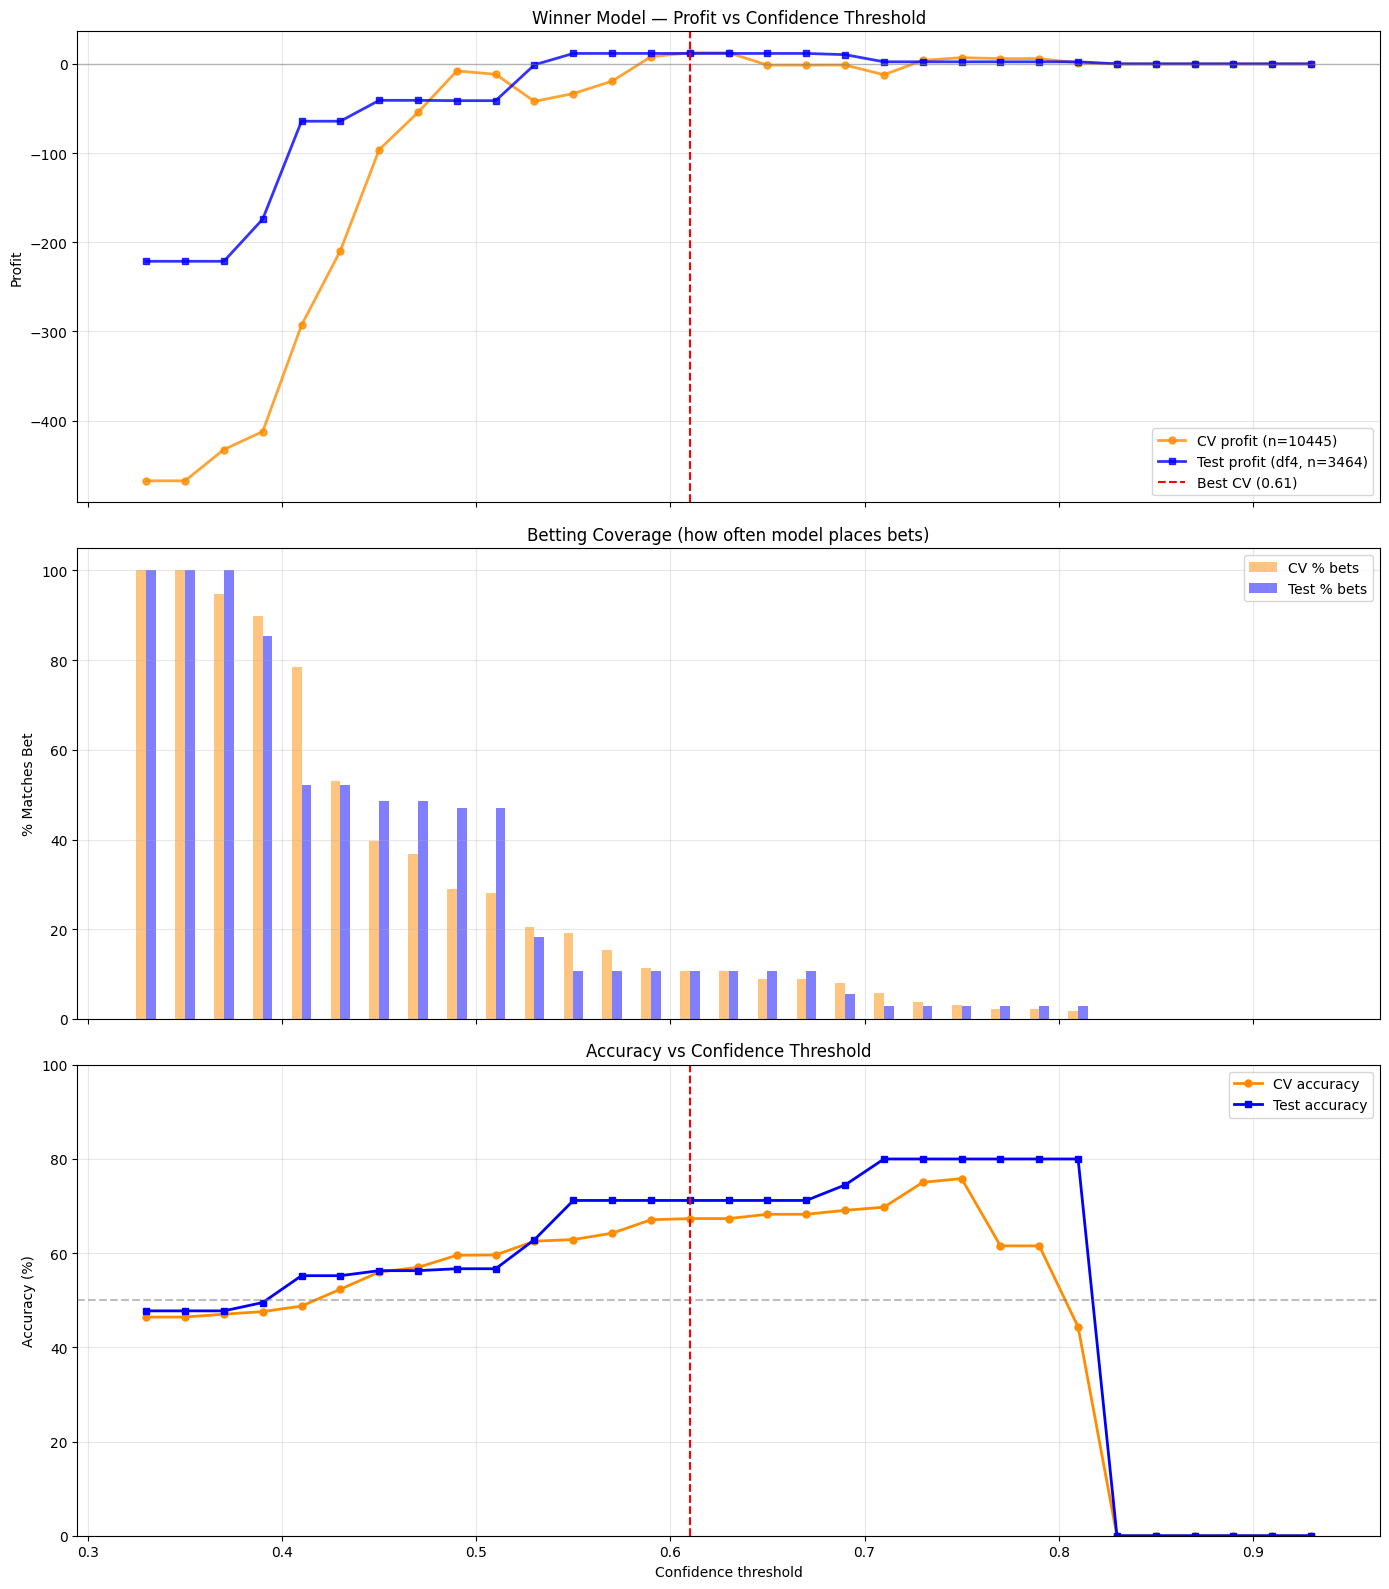

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, roi_cv,marker='o', markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train_full)})',alpha=0.8)
ax.plot(confidences_test, roi_test,marker='s', markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test_full)})',alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Winner Model — ROI vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. % OBSTAWIONYCH (BAR)
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')
ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')
ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

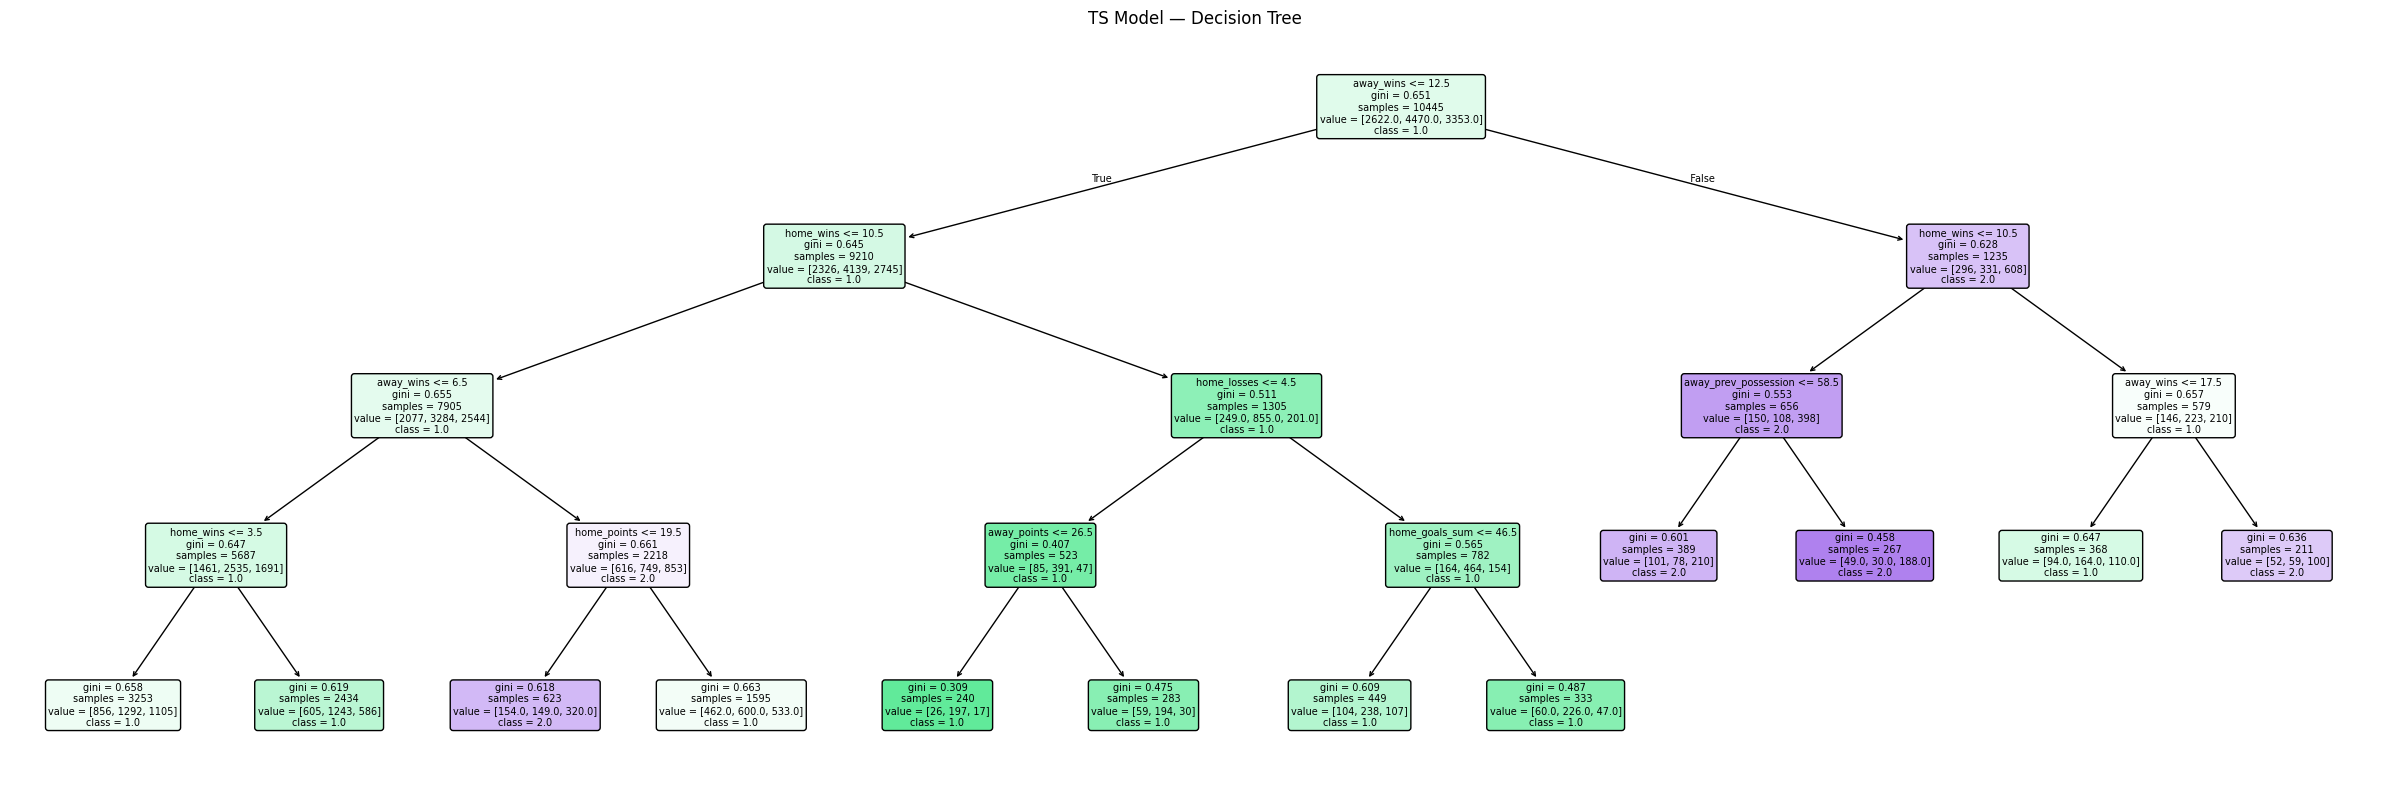

|--- away_wins <= 12.50
|   |--- home_wins <= 10.50
|   |   |--- away_wins <= 6.50
|   |   |   |--- home_wins <= 3.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- home_wins >  3.50
|   |   |   |   |--- class: 1.0
|   |   |--- away_wins >  6.50
|   |   |   |--- home_points <= 19.50
|   |   |   |   |--- class: 2.0
|   |   |   |--- home_points >  19.50
|   |   |   |   |--- class: 1.0
|   |--- home_wins >  10.50
|   |   |--- home_losses <= 4.50
|   |   |   |--- away_points <= 26.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- away_points >  26.50
|   |   |   |   |--- class: 1.0
|   |   |--- home_losses >  4.50
|   |   |   |--- home_goals_sum <= 46.50
|   |   |   |   |--- class: 1.0
|   |   |   |--- home_goals_sum >  46.50
|   |   |   |   |--- class: 1.0
|--- away_wins >  12.50
|   |--- home_wins <= 10.50
|   |   |--- away_prev_possession <= 58.50
|   |   |   |--- class: 2.0
|   |   |--- away_prev_possession >  58.50
|   |   |   |--- class: 2.0
|   |--- home_wins >  10.50
|   |   |-

In [17]:
# ── WIZUALIZACJA DRZEWA ────────────────────────────────────────────────────────

plt.figure(figsize=(24, 8))
plot_tree(model_ts.clf_, feature_names=feature_cols,
          class_names=[str(c) for c in model_ts.classes_],
          filled=True, rounded=True, fontsize=7)
plt.title("TS Model — Decision Tree")
plt.tight_layout()
plt.savefig("ts_model_tree.png", dpi=300)
plt.show()

print(export_text(model_ts.clf_, feature_names=feature_cols))

## Random forest

### RF run

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# KONFIGURACJA
# ═══════════════════════════════════════════════════════════════════════════
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'
TARGET_G = ['goals_1', 'goals_2']
META_COLS = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2', 'league']
NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8', 'uint16', 'uint32', 'uint64']
EXCLUDE_FROM_FEATURES = ['formation']  # już pominięte w build_training_rows

# ═══════════════════════════════════════════════════════════════════════════
# ENKODOWANIE LIGI (ONE-HOT)
# ═══════════════════════════════════════════════════════════════════════════
df_all = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].unique()


for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_').replace('-', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name] = (df_test_ts['league'] == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_').replace('-', '_')}" for l in all_leagues]

In [20]:
# ═══════════════════════════════════════════════════════════════════════════
# PRZYGOTOWANIE CECH (BEZ KURSÓW)
# ═══════════════════════════════════════════════════════════════════════════
feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype in NUMERIC_DTYPES
]

X_train_feats = df_train_ts[feature_cols].fillna(0)
X_test_feats = df_test_ts[feature_cols].fillna(0)

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full = df_test_ts[feature_cols + BET_COLS].fillna(0)

y_train = df_train_ts[TARGET_W]
y_test = df_test_ts[TARGET_W]

print(f"\nX_train_feats shape (bez kursów): {X_train_feats.shape}")
print(f"X_train_full shape (z kursami):   {X_train_full.shape}")
print(f"y_train shape:                     {y_train.shape}")



X_train_feats shape (bez kursów): (10445, 74)
X_train_full shape (z kursami):   (10445, 77)
y_train shape:                     (10445,)


In [21]:
X_train_full.columns

Index(['home_gk_rating', 'home_def_rating', 'home_mid_rating',
       'home_att_rating', 'away_gk_rating', 'away_def_rating',
       'away_mid_rating', 'away_att_rating', 'home_xg_proxy',
       'home_conversion_rate', 'home_shot_quality',
       'home_finishing_efficiency', 'home_attack_pressure',
       'home_danger_ratio', 'home_possession_efficiency',
       'home_discipline_cost', 'home_defensive_noise', 'away_xg_proxy',
       'away_conversion_rate', 'away_shot_quality',
       'away_finishing_efficiency', 'away_attack_pressure',
       'away_danger_ratio', 'away_possession_efficiency',
       'away_discipline_cost', 'away_defensive_noise', 'home_prev_attacks',
       'home_prev_goal_chances', 'home_prev_shots_off_target',
       'home_prev_shots', 'home_prev_dangerous_attacks', 'home_prev_red_cards',
       'home_prev_shots_on_target', 'home_prev_goals', 'home_prev_possession',
       'home_prev_fouls', 'home_prev_goalkeeper_saves', 'home_prev_offsides',
       'away_prev_attack

In [22]:
# ═══════════════════════════════════════════════════════════════════════════
# CUSTOM CLASSIFIER - TRENUJE BEZ KURSÓW
# ═══════════════════════════════════════════════════════════════════════════
class BettingForestClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, feature_cols, n_estimators=300, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols = feature_cols
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state
    
    def fit(self, X, y):
        self.clf_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state,
            n_jobs=-1
        )
        # Trenuj tylko na feature_cols (bez kursów)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self
    
    def predict(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)
    
    def predict_proba(self, X):
        check_is_fitted(self, 'clf_')
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

In [30]:
# ═══════════════════════════════════════════════════════════════════════════
# FUNKCJA EWALUACJI (dla całego datasetu)
# ═══════════════════════════════════════════════════════════════════════════
def evaluate_winner_predictions(model, X, y, confidence_threshold):
    """
    Ewaluuje model na całym zbiorze danych.
    Zwraca: profit, liczba_zakładów, procent_obstawionych, skuteczność
    """
    proba = model.predict_proba(X)
    classes = model.classes_
    confidence = proba.max(axis=1)
    predicted = classes[proba.argmax(axis=1)]
    
    X_reset = X.reset_index(drop=True)
    y_reset = np.array(y)
    
    profits = []
    placed = 0
    won = 0
    
    for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
        if conf < confidence_threshold:
            continue
        
        placed += 1
        
        bet_col = {1.0: 'bet_1', 0.0: 'bet_x', 2.0: 'bet_2'}[pred]
        
        if bet_col not in X_reset.columns:
            continue
        
        odds = X_reset.iloc[i][bet_col]
        
        if pred == true:
            profits.append(odds - 1)
            won += 1
        else:
            profits.append(-1)
    
    total = len(y)
    profit = sum(profits)
    pct = placed / total * 100 if total > 0 else 0
    acc = won / placed * 100 if placed > 0 else 0
    
    return profit, placed, pct, acc, won


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# MODEL
# ═══════════════════════════════════════════════════════════════════════════
model_ts = BettingForestClassifier(
    feature_cols=feature_cols,
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=300,
    random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ═══════════════════════════════════════════════════════════════════════════
# ITERACJA PO CONFIDENCE THRESHOLDS - CROSS VALIDATION
# ═══════════════════════════════════════════════════════════════════════════
confidence_thresholds = np.round(np.arange(0.33, 0.75, 0.02), 2)
results = []

print("\n" + "="*90)
print("CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION")
print("="*90)
print(f"{'Confidence':>11} | {'CV profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:

    cv_profit = []
    cv_placed = []
    cv_won = []

    for train_idx, val_idx in cv.split(X_train_full, y_train):
        X_tr, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        m = clone(model_ts)
        m.fit(X_tr, y_tr)

        profit, placed, pct, acc, won = evaluate_winner_predictions(
            m, X_val, y_val, conf_threshold
        )

        cv_profit.append(profit)
        cv_placed.append(placed)
        cv_won.append(won)

    # agregacja CV
    total_matches = len(y_train)
    total_placed = np.sum(cv_placed)
    total_won = np.sum(cv_won)

    acc_total = total_won / total_placed * 100 if total_placed > 0 else 0

    pct_total = total_placed / total_matches * 100

    results.append({
        'confidence': conf_threshold,
        'cv_profit_sum': np.sum(cv_profit),
        'cv_profit_avg': np.mean(cv_profit),
        'placed': total_placed,
        'pct': pct_total,
        'acc': np.mean(acc_total),
    })

    print(f"{conf_threshold:>11.2f} | {np.sum(cv_profit):>12.2f} | "
          f"{total_placed:>8} | {pct_total:>7.1f}% | {np.mean(acc_total):>9.1f}%")

# Najlepszy threshold z CV
best_cv = max(results, key=lambda x: x['cv_profit_sum'])
BEST_CONFIDENCE_CV = best_cv['confidence']
print(f"\n✓ Najlepszy confidence threshold (CV): {BEST_CONFIDENCE_CV}  (profit: {best_cv['cv_profit_sum']:.2f})")

# Trenuj finalny model
model_ts.fit(X_train_full, y_train)  # ✅ X_train_full


CROSS-VALIDATION (5-fold) - TIME SERIES MODEL - WINNER CLASSIFICATION
 Confidence |    CV profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -500.91 |    10445 |   100.0% |      48.1%
       0.35 |      -500.91 |    10445 |   100.0% |      48.1%
       0.37 |      -489.46 |    10402 |    99.6% |      48.1%
       0.39 |      -327.47 |     8941 |    85.6% |      50.1%
       0.41 |      -206.54 |     7153 |    68.5% |      52.6%
       0.43 |      -102.60 |     5514 |    52.8% |      55.4%
       0.45 |       -82.51 |     3983 |    38.1% |      58.6%
       0.47 |       -51.99 |     2765 |    26.5% |      62.4%
       0.49 |        18.31 |     1897 |    18.2% |      66.7%
       0.51 |        16.12 |     1278 |    12.2% |      69.3%
       0.53 |         4.07 |      895 |     8.6% |      71.6%
       0.55 |         6.57 |      639 |     6.1% |      73.7%
       0.57 |        -3.52 |    

BettingForestClassifier(feature_cols=['home_gk_rating', 'home_def_rating',
                                      'home_mid_rating', 'home_att_rating',
                                      'away_gk_rating', 'away_def_rating',
                                      'away_mid_rating', 'away_att_rating',
                                      'home_xg_proxy', 'home_conversion_rate',
                                      'home_shot_quality',
                                      'home_finishing_efficiency',
                                      'home_attack_pressure',
                                      'home_danger_ratio',
                                      'home_possession_efficiency',
                                      'home_disci...
                                      'home_defensive_noise', 'away_xg_proxy',
                                      'away_conversion_rate',
                                      'away_shot_quality',
                                      'away_finishing_efficiency',
                                      'away_attack_pressure',
                                      'away_danger_ratio',
                                      'away_possession_efficiency',
                                      'away_discipline_cost',
                                      'away_defensive_noise',
                                      'home_prev_attacks',
                                      'home_prev_goal_chances',
                                      'home_prev_shots_off_target',
                                      'home_prev_shots', ...],
                        max_depth=10, min_samples_leaf=300, n_estimators=100)

In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# EWALUACJA NA DANYCH TESTOWYCH
# ═══════════════════════════════════════════════════════════════════════════
test_results = []

print("\n" + "="*90)
print(f"TEST DATA - {len(X_test_full)} matches - TIME SERIES MODEL")
print("="*90)
print(f"{'Confidence':>11} | {'Profit':>12} | {'Placed':>8} | {'% Bet':>8} | {'Accuracy':>10}")
print("-" * 90)

for conf_threshold in confidence_thresholds:
    profit, placed, pct, acc, won = evaluate_winner_predictions(model_ts, X_test_full, y_test, conf_threshold)
    
    test_results.append({
        'confidence': conf_threshold,
        'profit': profit,
        'placed': placed,
        'won': won,
        'pct': pct,
        'acc': acc,
    })

    print(f"{conf_threshold:>11.2f} | {profit:>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>9.1f}%")

# Najlepszy threshold na teście
best_test = max(test_results, key=lambda x: x['profit'])
BEST_CONFIDENCE_TEST = best_test['confidence']
print(f"\n✓ Najlepszy confidence threshold (TEST): {BEST_CONFIDENCE_TEST}  (profit: {best_test['profit']:.2f})")
print(f"  Confidence threshold z CV był:          {BEST_CONFIDENCE_CV}")

print("\n" + "="*90)
print("PORÓWNANIE MODELI")
print("="*90)
print(f"Model na KURSACH (poprzedni):    Best CV profit: [tu wstaw wynik]")
print(f"Model na TIME SERIES (ten):      Best CV profit: {best_cv['cv_profit_sum']:.2f}")
print("="*90)


TEST DATA - 3464 matches - TIME SERIES MODEL
 Confidence |       Profit |   Placed |    % Bet |   Accuracy
------------------------------------------------------------------------------------------
       0.33 |      -154.47 |     3464 |   100.0% |      49.0%
       0.35 |      -154.47 |     3464 |   100.0% |      49.0%
       0.37 |      -150.06 |     3410 |    98.4% |      49.1%
       0.39 |       -83.16 |     2839 |    82.0% |      51.7%
       0.41 |        -9.13 |     2196 |    63.4% |      55.4%
       0.43 |        16.45 |     1651 |    47.7% |      58.8%
       0.45 |        26.78 |     1175 |    33.9% |      62.6%
       0.47 |        20.02 |      822 |    23.7% |      66.1%
       0.49 |        -1.25 |      590 |    17.0% |      67.1%
       0.51 |         2.09 |      405 |    11.7% |      70.4%
       0.53 |        -2.40 |      283 |     8.2% |      71.7%
       0.55 |        -0.73 |      208 |     6.0% |      74.0%
       0.57 |        -4.57 |      135 |     3.9% |      7

In [44]:
# Dane do wykresów
confidences_cv = [r['confidence'] for r in results]
profits_cv     = [r['cv_profit_sum'] for r in results]
pct_cv         = [r['pct'] for r in results]
acc_cv         = [r['acc'] for r in results]

confidences_test = [r['confidence'] for r in test_results]
profits_test = [r['profit'] for r in test_results]
pct_test = [r['pct'] for r in test_results]
acc_test = [r['acc'] for r in test_results]

roi_cv = [
    (r['cv_profit_sum'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in results
]

roi_test = [
    (r['profit'] / r['placed'] * 100) if r['placed'] > 0 else 0
    for r in test_results
]

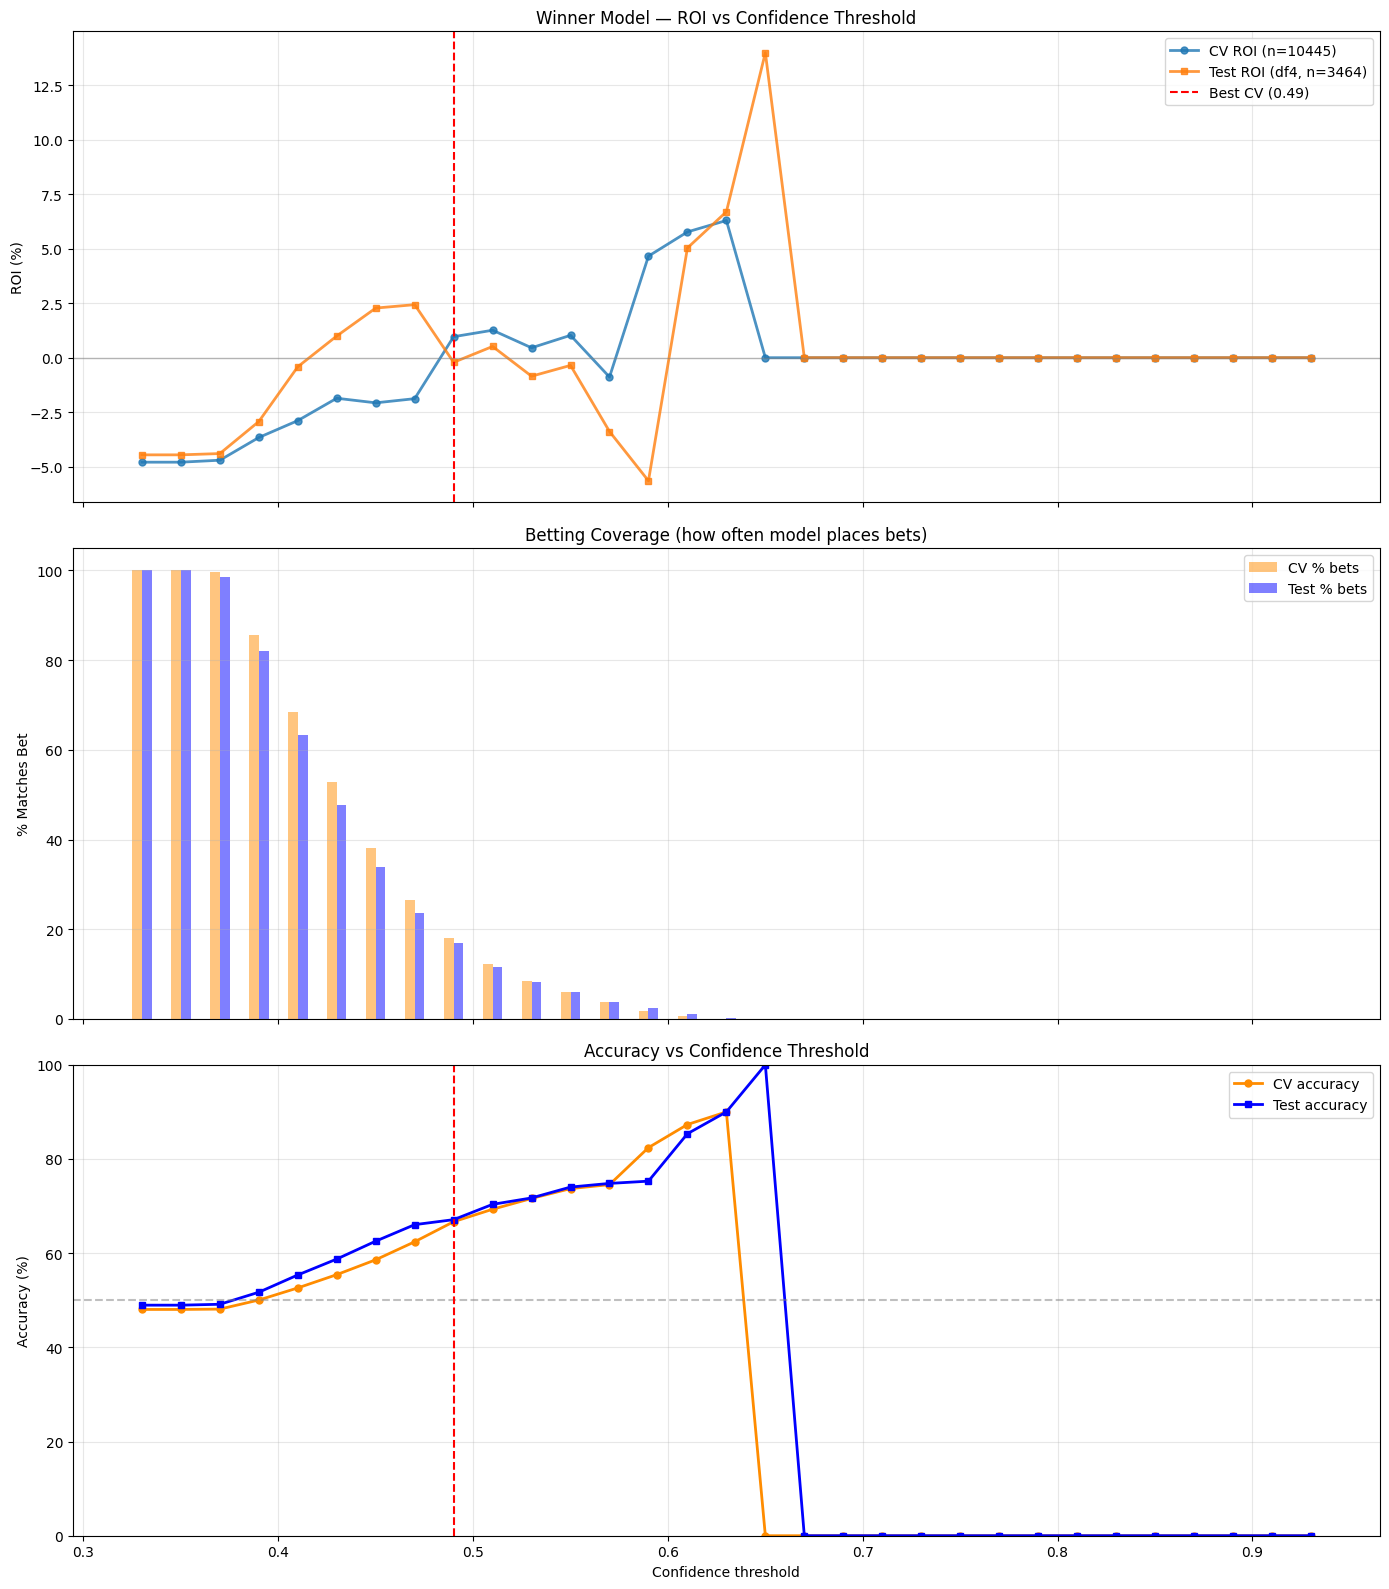

In [45]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16), sharex=True)

# ─────────────────────────────────────────────────────────────
# 1. PROFIT: CV vs TEST
# ─────────────────────────────────────────────────────────────
ax = axes[0]

ax.plot(confidences_cv, roi_cv,marker='o', markersize=5,linewidth=2,label=f'CV ROI (n={len(X_train_full)})',alpha=0.8)
ax.plot(confidences_test, roi_test,marker='s', markersize=5,linewidth=2,label=f'Test ROI (df4, n={len(X_test_full)})',alpha=0.8)

ax.axhline(0, color='gray', linewidth=1, alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',linewidth=1.5, label=f'Best CV ({BEST_CONFIDENCE_CV})')

ax.set_ylabel("ROI (%)")
ax.set_title("Winner Model — ROI vs Confidence Threshold")
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 2. % OBSTAWIONYCH (BAR)
# ─────────────────────────────────────────────────────────────
ax = axes[1]

width = 0.005

ax.bar(np.array(confidences_cv) - width/2,pct_cv,width=width,color='darkorange',alpha=0.5,label='CV % bets')
ax.bar(np.array(confidences_test) + width/2,pct_test,width=width,color='blue',alpha=0.5,label='Test % bets')

ax.set_ylabel("% Matches Bet")
ax.set_title("Betting Coverage (how often model places bets)")
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3)
ax.legend()


# ─────────────────────────────────────────────────────────────
# 3. ACCURACY
# ─────────────────────────────────────────────────────────────
ax = axes[2]

ax.plot(confidences_cv, acc_cv,marker='o', markersize=5,color='darkorange', linewidth=2,label='CV accuracy')
ax.plot(confidences_test, acc_test,marker='s', markersize=5,color='blue', linewidth=2,label='Test accuracy')

ax.axhline(50, color='gray', linestyle='--', alpha=0.5)
ax.axvline(BEST_CONFIDENCE_CV, color='red', linestyle='--',
           linewidth=1.5)

ax.set_xlabel("Confidence threshold")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Confidence Threshold")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.show()

### Column selection

In [35]:
# ── STAŁE ─────────────────────────────────────────────────────────────────────

season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']

EXCLUDE_FROM_FEATURES = [
    'formation'
]

BET_COLS  = ['bet_1', 'bet_x', 'bet_2']
TARGET_W  = 'winner'
TARGET_G  = ['goals_1', 'goals_2']

# ── REKONSTRUKCJA DANYCH TRENINGOWYCH ─────────────────────────────────────────
def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)

    for _, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']

        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue
        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        hist_1 = pd.DataFrame(ts_data[team_1])
        hist_2 = pd.DataFrame(ts_data[team_2])
        prev_idx_1, prev_idx_2 = idx_1 - 1, idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        for col in prev_1.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]  # ← surowa wartość, bez float()

        for col in prev_2.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]  # ← surowa wartość, bez float()

        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W]  = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        row['league']  = match['league']
        row['team_1']  = team_1
        row['team_2']  = team_2
        row['date']    = match['date']

        rows.append(row)

    return pd.DataFrame(rows)

In [36]:
# ── BUDOWA ZBIORU TRENINGOWEGO ─────────────────────────────────────────────────

train_dfs = []
for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    ts_data = load_time_series(label)
    built   = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    print(f"[{label}] wiersze: {len(built)}, team_1 uniq: {built['team_1'].nunique()}")

df_train_ts = pd.concat(train_dfs, ignore_index=True)

ts_data_test = load_time_series('2023_24')
df_test_ts   = build_training_rows(df4, ts_data_test)

print(f"\nTrain łącznie: {len(df_train_ts)} wierszy")
print(f"Test  (df4):   {len(df_test_ts)} wierszy")

[2020_21] wiersze: 3453, team_1 uniq: 201
[2021_22] wiersze: 3469, team_1 uniq: 202
[2022_23] wiersze: 3435, team_1 uniq: 201

Train łącznie: 10357 wierszy
Test  (df4):   3430 wierszy


In [37]:
# ── ENKODOWANIE LIGI (podmień poprzedni blok enkodowania) ─────────────────────

df_all = pd.concat([df_train_ts, df_test_ts], ignore_index=True)

# one-hot dla ligi — explicite dtype=int żeby uniknąć bool
all_leagues = df_all['league'].unique()

for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name]  = (df_test_ts['league']  == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_')}" for l in all_leagues]
print(f"Kolumny ligi: {league_feature_cols}")

Kolumny ligi: ['league_Primeira_Liga', 'league_LaLiga', 'league_Premiership', 'league_Eredivisie', 'league_Premier_Liga', 'league_Super_League', 'league_Jupiler_League', 'league_Super_Lig', 'league_Serie_A', 'league_Ligue_1', 'league_PKO_BP_Ekstraklasa', 'league_Tipico_Bundesliga', 'league_Liga_Portugal']


In [38]:
# ── PRZYGOTOWANIE CECH ────────────────────────────────────────────────────────

META_COLS = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2', 'league']

NUMERIC_DTYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8']

feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype in NUMERIC_DTYPES
]

print(f"Liczba cech modelu: {len(feature_cols)}")
print(f"Cechy ligi:         {[c for c in feature_cols if c.startswith('league_')]}")

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full  = df_test_ts[feature_cols + BET_COLS].fillna(0)

y_train = df_train_ts[TARGET_W]
y_test  = df_test_ts[TARGET_W]

print(f"\nX_train: {X_train_full.shape}")
print(f"X_test:  {X_test_full.shape}")

Liczba cech modelu: 59
Cechy ligi:         ['league_Primeira_Liga', 'league_LaLiga', 'league_Premiership', 'league_Eredivisie', 'league_Premier_Liga', 'league_Super_League', 'league_Jupiler_League', 'league_Super_Lig', 'league_Serie_A', 'league_Ligue_1', 'league_PKO_BP_Ekstraklasa', 'league_Tipico_Bundesliga', 'league_Liga_Portugal']

X_train: (10357, 62)
X_test:  (3430, 62)



[TS Model] Iteracja po threshold:
 Threshold | CV profit suma | Avg per fold
---------------------------------------------
      0.30 |        -394.99 |       -79.00
      0.35 |        -399.96 |       -79.99
      0.40 |        -347.79 |       -69.56
      0.45 |        -184.74 |       -36.95
      0.50 |         -93.60 |       -18.72
      0.55 |         -17.36 |        -3.47
      0.60 |         -20.06 |        -4.01
      0.65 |          -9.33 |        -1.87
      0.70 |           9.14 |         1.83
      0.75 |          -0.27 |        -0.05
      0.80 |          -3.59 |        -0.72
      0.85 |           0.00 |         0.00
      0.90 |           0.00 |         0.00
      0.95 |           0.00 |         0.00

✓ Najlepszy threshold: 0.7  (profit CV: 9.14)


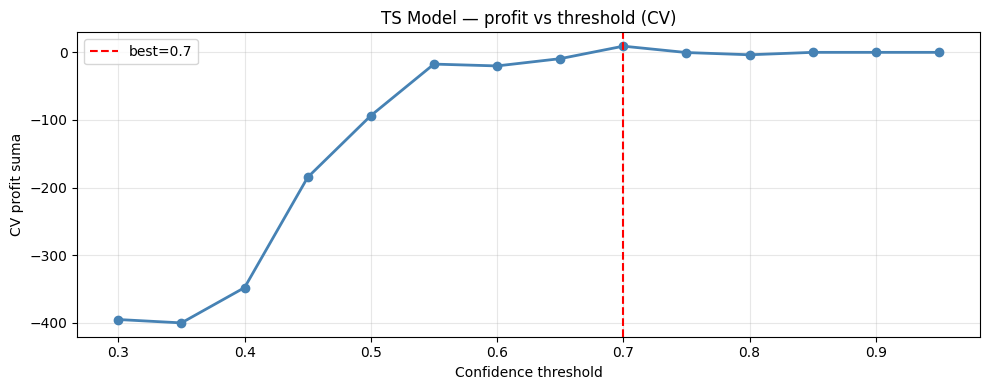

In [39]:
# ── MODEL ─────────────────────────────────────────────────────────────────────

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

class BettingTreeClassifier(BaseEstimator, ClassifierMixin):
    """DecisionTree który trenuje na feature_cols, ignoruje kolumny kursów."""
    def __init__(self, feature_cols, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols     = feature_cols
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state     = random_state

    def fit(self, X, y):
        self.clf_ = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state
        )
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)

    def predict_proba(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

feature_cols_with_bets = feature_cols

model_ts = BettingTreeClassifier(feature_cols=feature_cols_with_bets, max_depth=4,
                                  min_samples_leaf=20, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# iteracja po threshold — analogicznie do model_winner
ts_threshold_results = []
print("\n[TS Model] Iteracja po threshold:")
print(f"{'Threshold':>10} | {'CV profit suma':>14} | {'Avg per fold':>12}")
print("-" * 45)

for t in np.arange(0.30, 0.96, 0.05):
    t = round(t, 2)
    scorer = make_winner_scorer(t)
    scores = cross_val_score(model_ts, X_train_full, y_train, cv=cv, scoring=scorer)
    ts_threshold_results.append({
        'threshold': t,
        'cv_profit_sum': scores.sum(),
        'cv_profit_avg': scores.mean(),
    })
    print(f"{t:>10.2f} | {scores.sum():>14.2f} | {scores.mean():>12.2f}")

best_ts = max(ts_threshold_results, key=lambda x: x['cv_profit_sum'])
BEST_TS_THRESHOLD = best_ts['threshold']
print(f"\n✓ Najlepszy threshold: {BEST_TS_THRESHOLD}  (profit CV: {best_ts['cv_profit_sum']:.2f})")

model_ts.fit(X_train_full, y_train)

# wykres
plt.figure(figsize=(10, 4))
plt.plot([r['threshold'] for r in ts_threshold_results],
         [r['cv_profit_sum'] for r in ts_threshold_results],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(BEST_TS_THRESHOLD, color='red', linestyle='--',
            label=f'best={BEST_TS_THRESHOLD}')
plt.xlabel('Confidence threshold')
plt.ylabel('CV profit suma')
plt.title('TS Model — profit vs threshold (CV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ts_model_threshold_curve.png", dpi=150)
plt.show()

In [40]:
# diagnostyczny model z większą głębokością
model_deep = BettingTreeClassifier(
    feature_cols=feature_cols_with_bets,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)
model_deep.fit(X_train_full, y_train)

importances_deep = model_deep.clf_.feature_importances_
importance_deep_df = pd.DataFrame({
    'feature':    feature_cols_with_bets,
    'importance': importances_deep
}).sort_values('importance', ascending=False)

# print("\n[Diagnostyka max_depth=10] Cechy z importance > 0:")
# used_deep = importance_deep_df[importance_deep_df['importance'] > 0]
# print(f"Używanych cech: {len(used_deep)} / {len(feature_cols_with_bets)}")
# print(used_deep.to_string(index=False))

# cechy bezwartościowe — importance < 0.01 przy max_depth=10
worthless = importance_deep_df[importance_deep_df['importance'] < 0.01]
worthless_base = sorted(set(
    c.replace('home_prev_', '').replace('away_prev_', '')
    for c in worthless['feature']
    if c.startswith('home_prev_') or c.startswith('away_prev_')
))

print(f"\n[Bezwartościowe < 0.01] Cechy: {len(worthless)} / {len(feature_cols_with_bets)}")
print(f"{'Cecha':>35} | {'Importance':>10}")
print("-" * 50)
for _, row in worthless.iterrows():
    print(f"{row['feature']:>35} | {row['importance']:>10.6f}")

print(f"\nBazy (pary home/away) gdzie OBE < 0.01:")
for base in worthless_base:
    home_val = importance_deep_df.loc[
        importance_deep_df['feature'] == f'home_prev_{base}', 'importance'
    ].values
    away_val = importance_deep_df.loc[
        importance_deep_df['feature'] == f'away_prev_{base}', 'importance'
    ].values
    home_imp = home_val[0] if len(home_val) else None
    away_imp = away_val[0] if len(away_val) else None
    both_low = (home_imp is not None and home_imp < 0.001 and
                away_imp is not None and away_imp < 0.001)
    marker = ' ← OBE NISKIE' if both_low else ''
    print(f"  {base:<25} home={home_imp:.6f}  away={away_imp:.6f}{marker}")


[Bezwartościowe < 0.01] Cechy: 23 / 59
                              Cecha | Importance
--------------------------------------------------
                 home_prev_player_3 |   0.009867
         home_prev_goalkeeper_saves |   0.009718
                  home_match_number |   0.009668
         away_prev_shots_off_target |   0.009103
         home_prev_shots_off_target |   0.008659
                away_prev_red_cards |   0.005783
                 away_prev_player_5 |   0.005586
                 away_prev_offsides |   0.003176
                league_Super_League |   0.000000
           league_Tipico_Bundesliga |   0.000000
          league_PKO_BP_Ekstraklasa |   0.000000
                     league_Ligue_1 |   0.000000
                     league_Serie_A |   0.000000
                   league_Super_Lig |   0.000000
              league_Jupiler_League |   0.000000
                  league_Eredivisie |   0.000000
                league_Premier_Liga |   0.000000
                 league_Pre

Na tej podstawie, jednoznacznymi parami do usunięcia są:
- red_cards
- shots_off_target

Mimo niskich wartości:
- goalkeeper_saves koreluje z jakością bramkarza
- player_3/5 - bo użyjemy do agregacji zespołu
- offsides (0.014 home i 0.003) bo gospodarz ma jakiś sygnał
- ligi - przy zwykłej statystyce mają wpływ - część lig ma niższe odchylenia standardowe wyników od innych

### Column agregation + modification - bez średnich z 2+ ostatnich meczy

#### Dodanie kolumn na timeseries (time=-1), potrzebna redukcja przed timeseries z ostatnich 3/5/7/10meczy

In [46]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 5 — RÓŻNICE HOME vs AWAY
# ═══════════════════════════════════════════════════════════════════════════════

DIFF_COLS = [
    'goals', 'attacks', 'dangerous_attacks', 'possession',
    'shots_on_target', 'shots_off_target', 'goal_chances',
    'attack_efficiency', 'attack_pressure', 'danger_ratio',
    'shot_accuracy', 'offensive_aggression',
]

def add_diff_features(row):
    """Dodaje różnice home - away dla kluczowych cech."""
    for col in DIFF_COLS:
        h = row.get(f'home_prev_{col}')
        a = row.get(f'away_prev_{col}')
        if h is not None and a is not None:
            try:
                row[f'diff_{col}'] = float(h) - float(a)
            except (ValueError, TypeError):
                row[f'diff_{col}'] = np.nan
        else:
            row[f'diff_{col}'] = np.nan

    # różnica rankingu i punktów
    for col in ['rank', 'points', 'gd']:
        h = row.get(f'home_prev_{col}')
        a = row.get(f'away_prev_{col}')
        if h is not None and a is not None:
            row[f'diff_{col}'] = float(h) - float(a)
        else:
            row[f'diff_{col}'] = np.nan

    return row

In [ ]:
# podgląd wierszy 400:405
sample = df_train_ts.iloc[400:405]

# kolumny pogrupowane dla czytelności
groups = {
    'META':       ['team_1', 'team_2', 'league', 'date'],
    'SUROWE':     [c for c in sample.columns if 'prev_goals' in c or 'prev_attacks' in c or 'prev_possession' in c],
    'RANKING':    [c for c in sample.columns if 'rank' in c or 'points' in c or 'gd' in c],
    'EFEKTYWNOŚĆ':[c for c in sample.columns if 'efficiency' in c or 'pressure' in c or 'ratio' in c or 'accuracy' in c],
    'OCENY':      [c for c in sample.columns if 'rating' in c],
    'DIFF':       [c for c in sample.columns if c.startswith('diff_')],
    'TARGET':     [TARGET_W, 'goals_1', 'goals_2'],
}

for group_name, cols in groups.items():
    existing = [c for c in cols if c in sample.columns]
    if not existing:
        continue
    print(f"\n{'='*60}")
    print(f"  {group_name}")
    print('='*60)
    print(sample[existing].to_string())

#### Analiza cehc przed redukcją

In [54]:
# ── ANALIZA CECH PRZED REDUKCJĄ ───────────────────────────────────────────────

model_diag = BettingTreeClassifier(
    feature_cols=feature_cols,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)
model_diag.fit(X_train_full, y_train)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_diag.clf_.feature_importances_
}).sort_values('importance', ascending=False)

used     = importance_df[importance_df['importance'] >  0.001]
marginal = importance_df[(importance_df['importance'] > 0) &
                          (importance_df['importance'] <= 0.001)]
zero     = importance_df[importance_df['importance'] == 0]

print(f"Cechy z importance > 0.001:  {len(used)}")
print(f"Cechy marginalne (0, 0.001]: {len(marginal)}")
print(f"Cechy zerowe:                {len(zero)}")

print(f"\n{'Cecha':>40} | {'Importance':>10}")
print("-" * 55)
print("── UŻYWANE (> 0.001) ──")
for _, row in used.iterrows():
    print(f"{row['feature']:>40} | {row['importance']:>10.6f}")

print("\n── MARGINALNE (0 < x <= 0.001) ──")
for _, row in marginal.iterrows():
    print(f"{row['feature']:>40} | {row['importance']:>10.6f}")

print(f"\n── ZEROWE ({len(zero)} cech) ──")
print([r for r in zero['feature'].tolist()])

# ── ANALIZA PAR HOME/AWAY ─────────────────────────────────────────────────────

# wyciągnij bazy (bez home_prev_ / away_prev_ prefixu)
imp_map = dict(zip(importance_df['feature'], importance_df['importance']))

pair_bases = sorted(set(
    c.replace('home_prev_', '').replace('away_prev_', '')
    for c in feature_cols
    if c.startswith('home_prev_') or c.startswith('away_prev_')
))

print(f"\n[Analiza par home/away]")
print(f"{'Baza':>35} | {'home imp':>10} | {'away imp':>10} | {'suma':>8} | {'Decyzja':>15}")
print("-" * 85)

pairs_to_remove = []
pairs_to_keep   = []

for base in pair_bases:
    h_col = f'home_prev_{base}'
    a_col = f'away_prev_{base}'
    h_imp = imp_map.get(h_col, None)
    a_imp = imp_map.get(a_col, None)

    h_str = f"{h_imp:.6f}" if h_imp is not None else "  brak "
    a_str = f"{a_imp:.6f}" if a_imp is not None else "  brak "

    both_exist = h_imp is not None and a_imp is not None
    if both_exist:
        suma = h_imp + a_imp
        both_zero = h_imp <= 0.001 and a_imp <= 0.001
        one_zero  = (h_imp <= 0.001) != (a_imp <= 0.001)  # XOR
        decision  = '✗ USUŃ PARĘ' if both_zero else ('⚠ asymetria' if one_zero else '✓ zostaw')
        if both_zero:
            pairs_to_remove.append(base)
        else:
            pairs_to_keep.append(base)
    else:
        suma     = (h_imp or 0) + (a_imp or 0)
        decision = '? brak pary'

    print(f"{base:>35} | {h_str:>10} | {a_str:>10} | {suma:>8.6f} | {decision:>15}")

# ── DIFF BEZ PARY — zerowe ────────────────────────────────────────────────────

diff_cols  = [c for c in feature_cols if c.startswith('diff_')]
diff_zero  = [c for c in diff_cols if imp_map.get(c, 0) <= 0.001]
diff_used  = [c for c in diff_cols if imp_map.get(c, 0) >  0.001]

print(f"\n[Diff — zerowe/marginalne do usunięcia]")
for c in diff_zero:
    print(f"  {c}: {imp_map.get(c, 0):.6f}")

# ── POJEDYNCZE (liga, formacja) ───────────────────────────────────────────────

single_zero = [
    c for c in feature_cols
    if not c.startswith('home_prev_')
    and not c.startswith('away_prev_')
    and not c.startswith('diff_')
    and imp_map.get(c, 0) <= 0.001
]

print(f"\n[Pojedyncze kolumny zerowe (liga, formacja, itp.)]")
for c in single_zero:
    print(f"  {c}: {imp_map.get(c, 0):.6f}")

# ── PODSUMOWANIE DO USUNIĘCIA ─────────────────────────────────────────────────

cols_to_remove = (
    [f'home_prev_{b}' for b in pairs_to_remove] +
    [f'away_prev_{b}' for b in pairs_to_remove] +
    diff_zero +
    single_zero
)

print(f"\n{'='*55}")
print(f"Pary (bazy) do usunięcia:      {len(pairs_to_remove)}  → {len(pairs_to_remove)*2} kolumn")
print(f"Diff do usunięcia:             {len(diff_zero)}")
print(f"Pojedyncze do usunięcia:       {len(single_zero)}")
print(f"Łącznie do usunięcia:          {len(cols_to_remove)}")
print(f"Pozostanie:                    {len(feature_cols) - len(cols_to_remove)} cech")

print(f"\nPary do usunięcia: {pairs_to_remove}")
print(f"Diff do usunięcia: {diff_zero}")
print(f"Inne do usunięcia: {single_zero}")

# grupy wg kategorii
categories = {
    'surowe_stat':   [c for c in feature_cols if ('home_prev_' in c or 'away_prev_' in c)
                      and not any(x in c for x in ['rating', 'rank', 'points', 'gd',
                      'efficiency', 'pressure', 'ratio', 'accuracy',
                      'aggression', 'ineffective', 'formation', 'player_'])],
    'gracze':        [c for c in feature_cols if 'player_' in c],
    'oceny_pozycji': [c for c in feature_cols if 'rating' in c],
    'ranking':       [c for c in feature_cols if any(x in c for x in ['rank', 'points', 'gd'])],
    'efektywnosc':   [c for c in feature_cols if any(x in c for x in
                      ['efficiency', 'pressure', 'ratio', 'accuracy', 'aggression', 'ineffective'])],
    'diff':          [c for c in feature_cols if c.startswith('diff_')],
    'formacja':      [c for c in feature_cols if 'formation' in c],
    'liga':          [c for c in feature_cols if c.startswith('league_')],
    'match_number':  [c for c in feature_cols if 'match_number' in c],
}

print(f"\n[Podsumowanie wg kategorii]")
print(f"{'Kategoria':>20} | {'Łącznie':>8} | {'Używane':>8} | {'% użytych':>10} | {'Do usunięcia':>13}")
print("-" * 70)
for cat, cols in categories.items():
    used_n   = sum(1 for c in cols if imp_map.get(c, 0) > 0.001)
    remove_n = sum(1 for c in cols if c in cols_to_remove)
    print(f"{cat:>20} | {len(cols):>8} | {used_n:>8} | "
          f"{used_n/len(cols)*100 if cols else 0:>9.1f}% | {remove_n:>13}")



Cechy z importance > 0.001:  78
Cechy marginalne (0, 0.001]: 0
Cechy zerowe:                27

                                   Cecha | Importance
-------------------------------------------------------
── UŻYWANE (> 0.001) ──
                                 diff_gd |   0.311150
                            home_prev_gd |   0.029484
                          away_prev_rank |   0.027888
                    away_prev_def_rating |   0.020181
                    home_prev_att_rating |   0.019007
                  diff_dangerous_attacks |   0.018499
                      diff_shot_accuracy |   0.017654
                  away_prev_danger_ratio |   0.017324
                       away_prev_attacks |   0.017317
                               diff_rank |   0.016600
                       diff_danger_ratio |   0.015677
                    home_prev_mid_rating |   0.015491
                  away_prev_goal_chances |   0.015234
                        away_prev_points |   0.015147
              

In [56]:
# ── PRZEGLĄD IMPORTANCE — SKRÓCONY ───────────────────────────────────────────

model_diag = BettingTreeClassifier(
    feature_cols=feature_cols,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)
model_diag.fit(X_train_full, y_train)

imp_map = dict(zip(feature_cols, model_diag.clf_.feature_importances_))

# kategorie
categories = {
    'surowe_stat':   [c for c in feature_cols if ('home_prev_' in c or 'away_prev_' in c)
                      and not any(x in c for x in ['rating', 'rank', 'points', 'gd',
                      'efficiency', 'pressure', 'ratio', 'accuracy',
                      'aggression', 'ineffective', 'formation', 'player_'])],
    'gracze':        [c for c in feature_cols if 'player_' in c],
    'oceny_pozycji': [c for c in feature_cols if 'rating' in c],
    'ranking':       [c for c in feature_cols if any(x in c for x in ['rank', 'points', 'gd'])],
    'efektywnosc':   [c for c in feature_cols if any(x in c for x in
                      ['efficiency', 'pressure', 'ratio', 'accuracy', 'aggression', 'ineffective'])],
    'diff':          [c for c in feature_cols if c.startswith('diff_')],
    'liga':          [c for c in feature_cols if c.startswith('league_')],
    'match_number':  [c for c in feature_cols if 'match_number' in c],
}

print(f"{'='*65}")
print(f"  PODSUMOWANIE IMPORTANCE WG KATEGORII")
print(f"{'='*65}")
print(f"{'Kategoria':>20} | {'Cech':>5} | {'Suma imp':>10} | {'Avg imp':>10} | {'Top cecha':<35}")
print("-" * 90)

category_summary = []
for cat, cols in categories.items():
    if not cols:
        continue
    imps        = [imp_map.get(c, 0) for c in cols]
    total_imp   = sum(imps)
    avg_imp     = total_imp / len(cols)
    top_col     = max(cols, key=lambda c: imp_map.get(c, 0))
    top_imp     = imp_map.get(top_col, 0)
    top_short   = top_col.replace('home_prev_', 'h:').replace('away_prev_', 'a:').replace('diff_', 'd:')
    category_summary.append((cat, total_imp))
    print(f"{cat:>20} | {len(cols):>5} | {total_imp:>10.4f} | {avg_imp:>10.4f} | {top_short:<35} ({top_imp:.4f})")

# ranking kategorii wg łącznej importance
print(f"\n{'='*65}")
print(f"  RANKING KATEGORII (wg łącznej importance)")
print(f"{'='*65}")
for i, (cat, imp) in enumerate(sorted(category_summary, key=lambda x: x[1], reverse=True), 1):
    bar = '█' * int(imp * 200)
    print(f"  {i}. {cat:<20} {imp:.4f}  {bar}")

# top 15 cech globalnie
print(f"\n{'='*65}")
print(f"  TOP 15 CECH GLOBALNIE")
print(f"{'='*65}")
top15 = sorted(imp_map.items(), key=lambda x: x[1], reverse=True)[:15]
for i, (col, imp) in enumerate(top15, 1):
    short = col.replace('home_prev_', 'h:').replace('away_prev_', 'a:').replace('diff_', 'd:')
    bar   = '█' * int(imp * 300)
    print(f"  {i:>2}. {short:<40} {imp:.4f}  {bar}")

# bazy statystyczne posortowane wg sumy home+away importance
print(f"\n{'='*65}")
print(f"  BAZY STATYSTYCZNE (suma home+away) — kandydaci do agregacji")
print(f"{'='*65}")
print(f"{'Baza':>30} | {'home':>8} | {'away':>8} | {'suma':>8} | {'priorytet':>10}")
print("-" * 70)

pair_bases = sorted(set(
    c.replace('home_prev_', '').replace('away_prev_', '')
    for c in feature_cols
    if c.startswith('home_prev_') or c.startswith('away_prev_')
))

pair_summary = []
for base in pair_bases:
    h_imp = imp_map.get(f'home_prev_{base}', 0)
    a_imp = imp_map.get(f'away_prev_{base}', 0)
    suma  = h_imp + a_imp
    pair_summary.append((base, h_imp, a_imp, suma))

for base, h, a, s in sorted(pair_summary, key=lambda x: x[3], reverse=True):
    if s < 0.001:
        continue
    priority = '⭐⭐⭐' if s > 0.05 else ('⭐⭐' if s > 0.02 else '⭐')
    print(f"{base:>30} | {h:>8.4f} | {a:>8.4f} | {s:>8.4f} | {priority:>10}")

print(f"\n(pominięto bazy z sumą < 0.001)")

  PODSUMOWANIE IMPORTANCE WG KATEGORII
           Kategoria |  Cech |   Suma imp |    Avg imp | Top cecha                          
------------------------------------------------------------------------------------------
         surowe_stat |    20 |     0.1253 |     0.0063 | a:attacks                           (0.0173)
              gracze |    22 |     0.1490 |     0.0068 | a:player_6                          (0.0123)
       oceny_pozycji |     8 |     0.0722 |     0.0090 | a:def_rating                        (0.0202)
             ranking |     9 |     0.4406 |     0.0490 | d:gd                                (0.3111)
         efektywnosc |    19 |     0.1535 |     0.0081 | d:shot_accuracy                     (0.0177)
                diff |    12 |     0.4271 |     0.0356 | d:gd                                (0.3111)
                liga |    13 |     0.0061 |     0.0005 | league_Super_League                 (0.0038)
        match_number |     2 |     0.0176 |     0.0088 | away_m

#### dodawanie nowych danych / time series last 3/5/10 meczy - wymagane puszczenie wcześniejszej części

In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 7 — HISTORIA WYNIKÓW PER ZESPÓŁ (z df_raw)
# ═══════════════════════════════════════════════════════════════════════════════

def build_team_results_history(df_raw: pd.DataFrame) -> dict:
    """
    Buduje historię wyników per zespół w kolejności chronologicznej.
    Zwraca dict: {team: [{points, gd, won, draw, lost}, ...]}
    Indeks listy odpowiada match_idx (jak w ts_data i team_match_counter).
    """
    df_sorted    = df_raw.sort_values('date').reset_index(drop=True)
    team_counter = {}
    history      = {}  # {team: [{'points_earned', 'gd', 'won', 'draw', 'lost'}, ...]}

    for _, match in df_sorted.iterrows():
        t1     = match['team_1']
        t2     = match['team_2']
        winner = match['winner']

        try:
            g1 = int(match['goals_1'])
            g2 = int(match['goals_2'])
        except (ValueError, TypeError):
            g1, g2 = 0, 0

        for t in [t1, t2]:
            if t not in team_counter:
                team_counter[t] = 0
            if t not in history:
                history[t] = []

        # wynik dla team_1
        if winner == 1:
            r1 = {'points_earned': 3, 'gd': g1 - g2, 'won': 1, 'draw': 0, 'lost': 0}
            r2 = {'points_earned': 0, 'gd': g2 - g1, 'won': 0, 'draw': 0, 'lost': 1}
        elif winner == 0:
            r1 = {'points_earned': 1, 'gd': g1 - g2, 'won': 0, 'draw': 1, 'lost': 0}
            r2 = {'points_earned': 1, 'gd': g2 - g1, 'won': 0, 'draw': 1, 'lost': 0}
        else:
            r1 = {'points_earned': 0, 'gd': g1 - g2, 'won': 0, 'draw': 0, 'lost': 1}
            r2 = {'points_earned': 3, 'gd': g2 - g1, 'won': 1, 'draw': 0, 'lost': 0}

        history[t1].append(r1)
        history[t2].append(r2)
        team_counter[t1] += 1
        team_counter[t2] += 1

    return history


# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 8 — AGREGACJE FORMY (last3, last5) I PUNKTÓW (last10)
# ═══════════════════════════════════════════════════════════════════════════════

def get_form_aggregates(history: list, prev_idx: int) -> dict:
    """
    Liczy agregaty z ostatnich N wyników PRZED tym meczem (kończy na prev_idx).
    history = lista słowników [{points_earned, gd, won, draw, lost}, ...]
    prev_idx = indeks ostatniego dostępnego meczu (włącznie)
    """
    agg = {}

    # historia do prev_idx włącznie
    available = history[:prev_idx + 1]

    for n, keys in [(3, ['points', 'gd', 'wins', 'draws', 'losses']),
                    (5, ['points', 'gd', 'wins', 'draws', 'losses']),
                    (10, ['points'])]:

        window = available[-n:]  # ostatnie N wyników

        if not window:
            for k in keys:
                agg[f'last{n}_{k}'] = np.nan
            continue

        agg[f'last{n}_points'] = sum(r['points_earned'] for r in window)

        if n <= 5:
            agg[f'last{n}_gd']     = sum(r['gd']   for r in window)
            agg[f'last{n}_wins']   = sum(r['won']   for r in window)
            agg[f'last{n}_draws']  = sum(r['draw']  for r in window)
            agg[f'last{n}_losses'] = sum(r['lost']  for r in window)

    return agg


# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 9 — AGREGACJE STATYSTYK MECZOWYCH (last3, last5)
# ═══════════════════════════════════════════════════════════════════════════════

# kolumny do agregacji — tylko te z sumą importance > 0.02
STATS_TO_AGG = [
    'attacks', 'dangerous_attacks', 'goal_chances', 'possession',
    'shot_accuracy', 'attack_efficiency', 'danger_ratio', 'ineffective_attacks',
]

# oceny pozycji — agregowane osobno
RATINGS_TO_AGG = ['gk_rating', 'def_rating', 'mid_rating', 'att_rating']

def get_stats_aggregates(hist_df: pd.DataFrame, prev_idx: int) -> dict:
    """
    Liczy średnie z ostatnich 3 i 5 meczów dla statystyk i ocen pozycji.
    hist_df = pd.DataFrame(ts_data[team])
    prev_idx = indeks ostatniego dostępnego meczu
    """
    agg = {}
    available = hist_df.iloc[:prev_idx + 1]

    for n in [3, 5]:
        window = available.iloc[-n:]

        # statystyki meczowe
        for col in STATS_TO_AGG:
            if col in window.columns:
                vals = pd.to_numeric(window[col], errors='coerce')
                agg[f'avg{n}_{col}'] = vals.mean()
            else:
                agg[f'avg{n}_{col}'] = np.nan

        # oceny pozycji
        for col in RATINGS_TO_AGG:
            if col in window.columns:
                vals = pd.to_numeric(window[col], errors='coerce')
                agg[f'avg{n}_{col}'] = vals.mean()
            else:
                # próba wyliczenia z player_* jeśli brak gotowej kolumny
                agg[f'avg{n}_{col}'] = np.nan

    return agg


# ═══════════════════════════════════════════════════════════════════════════════
# AKTUALIZACJA build_training_rows — dodanie bloków 7, 8, 9
# ═══════════════════════════════════════════════════════════════════════════════

def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    df_sorted  = df_raw.sort_values('date').reset_index(drop=True)
    rankings   = build_season_rankings(df_raw)       # blok 2
    results_h  = build_team_results_history(df_raw)  # blok 7

    for _, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']

        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue
        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        hist_1 = pd.DataFrame(ts_data[team_1])
        hist_2 = pd.DataFrame(ts_data[team_2])
        prev_idx_1, prev_idx_2 = idx_1 - 1, idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # statystyki surowe z poprzedniego meczu
        for col in prev_1.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        for col in prev_2.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        # blok 1 — oceny graczy wg pozycji
        row = add_position_ratings(row, hist_1, prev_idx_1, 'home_prev')
        row = add_position_ratings(row, hist_2, prev_idx_2, 'away_prev')

        # blok 2 — ranking
        rank_1 = rankings.get((team_1, idx_1), {})
        rank_2 = rankings.get((team_2, idx_2), {})
        for k, v in rank_1.items():
            row[f'home_prev_{k}'] = v
        for k, v in rank_2.items():
            row[f'away_prev_{k}'] = v

        # blok 3 — efektywność
        row = add_efficiency_features(row, prev_1, 'home_prev')
        row = add_efficiency_features(row, prev_2, 'away_prev')

        # blok 4 — styl gry
        row = add_style_features(row, prev_1, 'home_prev')
        row = add_style_features(row, prev_2, 'away_prev')

        # blok 5 — różnice home vs away
        row = add_diff_features(row)

        # blok 8 — agregaty formy (last3, last5, last10)
        hist_res_1 = results_h.get(team_1, [])
        hist_res_2 = results_h.get(team_2, [])
        form_1 = get_form_aggregates(hist_res_1, prev_idx_1)
        form_2 = get_form_aggregates(hist_res_2, prev_idx_2)
        for k, v in form_1.items():
            row[f'home_{k}'] = v
        for k, v in form_2.items():
            row[f'away_{k}'] = v

        # blok 9 — agregaty statystyk (avg3, avg5)
        stats_1 = get_stats_aggregates(hist_1, prev_idx_1)
        stats_2 = get_stats_aggregates(hist_2, prev_idx_2)
        for k, v in stats_1.items():
            row[f'home_{k}'] = v
        for k, v in stats_2.items():
            row[f'away_{k}'] = v

        # różnice dla nowych agregacji
        for k in form_1:
            h = row.get(f'home_{k}')
            a = row.get(f'away_{k}')
            if h is not None and a is not None:
                try:
                    row[f'diff_{k}'] = float(h) - float(a)
                except (ValueError, TypeError):
                    row[f'diff_{k}'] = np.nan

        for k in stats_1:
            h = row.get(f'home_{k}')
            a = row.get(f'away_{k}')
            if h is not None and a is not None:
                try:
                    row[f'diff_{k}'] = float(h) - float(a)
                except (ValueError, TypeError):
                    row[f'diff_{k}'] = np.nan

        # kursy, targety, meta
        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W]  = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        row['league']  = match['league']
        row['team_1']  = team_1
        row['team_2']  = team_2
        row['date']    = match['date']

        rows.append(row)

    return pd.DataFrame(rows)

In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORÓW
# ═══════════════════════════════════════════════════════════════════════════════

train_dfs = []
for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    ts_data = load_time_series(label)
    built   = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    print(f"[{label}] wiersze: {len(built)}, cechy: {built.shape[1]}")

df_train_ts = pd.concat(train_dfs, ignore_index=True)
ts_data_test = load_time_series('2023_24')
df_test_ts   = build_training_rows(df4, ts_data_test)

print(f"\nTrain łącznie: {len(df_train_ts)} wierszy, {df_train_ts.shape[1]} kolumn")
print(f"Test  (df4):   {len(df_test_ts)} wierszy")

# blok 6 — aplikacja klasyfikacji formacji po zbudowaniu df
for prefix, raw_col in [('home_prev', 'home_prev_formation'),
                         ('away_prev', 'away_prev_formation')]:
    out_col = f'{prefix}_formation_type'
    for df_ in [df_train_ts, df_test_ts]:
        if raw_col in df_.columns:
            df_[out_col] = df_[raw_col].apply(classify_formation)
        else:
            df_[out_col] = np.nan

# różnica stylu formacji home vs away
df_train_ts['diff_formation_type'] = (
    df_train_ts['home_prev_formation_type'] - df_train_ts['away_prev_formation_type']
)
df_test_ts['diff_formation_type'] = (
    df_test_ts['home_prev_formation_type'] - df_test_ts['away_prev_formation_type']
)

# podgląd rozkładu
print("\n[Blok 6] Rozkład typów formacji (train):")
for col in ['home_prev_formation_type', 'away_prev_formation_type']:
    if col in df_train_ts.columns:
        counts = df_train_ts[col].value_counts().sort_index()
        labels = {0: 'defensywna', 1: 'wyważona', 2: 'ofensywna'}
        print(f"\n  {col}:")
        for k, v in counts.items():
            print(f"    {labels.get(k, '?'):>12}: {v:>6} ({v/len(df_train_ts)*100:.1f}%)")

# ── ENKODOWANIE LIGI ──────────────────────────────────────────────────────────

df_all      = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].dropna().unique()

for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name]  = (df_test_ts['league']  == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_')}" for l in all_leagues]
print(f"\nKolumny ligi: {len(league_feature_cols)}")

[2020_21] wiersze: 3453, cechy: 204
[2021_22] wiersze: 3469, cechy: 204
[2022_23] wiersze: 3435, cechy: 204

Train łącznie: 10357 wierszy, 204 kolumn
Test  (df4):   3430 wierszy

[Blok 6] Rozkład typów formacji (train):

  home_prev_formation_type:

  away_prev_formation_type:

Kolumny ligi: 13


In [59]:
# ── PRZYGOTOWANIE CECH ────────────────────────────────────────────────────────

META_COLS     = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2',
                 'league', 'home_prev_formation', 'away_prev_formation']
NUMERIC_TYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8']

feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype.name in NUMERIC_TYPES
]

print(f"Liczba cech modelu: {len(feature_cols)}")
formation_feats = [c for c in feature_cols if 'formation' in c]
print(f"Cechy formacji: {formation_feats}")

new_feat_examples = [c for c in feature_cols if any(x in c for x in
    ['rating', 'rank', 'points', 'efficiency', 'pressure', 'ratio',
     'accuracy', 'aggression', 'diff_', 'ineffective', 'formation'])]
print(f"Przykład nowych cech ({len(new_feat_examples)}):")
for c in new_feat_examples[:25]:
    print(f"  {c}")

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full  = df_test_ts[feature_cols + BET_COLS].fillna(0)
y_train      = df_train_ts[TARGET_W]
y_test       = df_test_ts[TARGET_W]

print(f"\nX_train: {X_train_full.shape}")
print(f"X_test:  {X_test_full.shape}")

Liczba cech modelu: 210
Cechy formacji: ['home_prev_formation_type', 'away_prev_formation_type', 'diff_formation_type']
Przykład nowych cech (117):
  home_prev_gk_rating
  home_prev_def_rating
  home_prev_att_rating
  home_prev_mid_rating
  away_prev_gk_rating
  away_prev_def_rating
  away_prev_att_rating
  away_prev_mid_rating
  home_prev_points
  home_prev_rank
  away_prev_points
  away_prev_rank
  home_prev_attack_efficiency
  home_prev_attack_pressure
  home_prev_danger_ratio
  home_prev_shot_accuracy
  away_prev_attack_efficiency
  away_prev_attack_pressure
  away_prev_danger_ratio
  away_prev_shot_accuracy
  home_prev_ineffective_attacks
  home_prev_offensive_aggression
  home_prev_possession_efficiency
  away_prev_ineffective_attacks
  away_prev_offensive_aggression

X_train: (10357, 213)
X_test:  (3430, 213)



[TS Model] Iteracja po threshold:
 Threshold | CV profit suma | Avg per fold |  Zakłady |  % obst. |  Skuteczność
---------------------------------------------------------------------------
      0.30 |        -283.40 |       -56.68 |    10357 |   100.0% |        50.5%
      0.35 |        -283.40 |       -56.68 |    10357 |   100.0% |        50.5%
      0.40 |         -85.89 |       -17.18 |     7803 |    75.3% |        55.0%
      0.45 |        -116.61 |       -23.32 |     6285 |    60.7% |        57.8%
      0.50 |         -71.66 |       -14.33 |     3617 |    34.9% |        65.1%
      0.55 |         -32.08 |        -6.42 |     3222 |    31.1% |        66.6%
      0.60 |         -16.01 |        -3.20 |     2304 |    22.2% |        70.2%
      0.65 |           4.14 |         0.83 |     2304 |    22.2% |        70.2%
      0.70 |          -2.10 |        -0.42 |      683 |     6.6% |        80.2%
      0.75 |           0.58 |         0.12 |      683 |     6.6% |        80.2%
      0.8

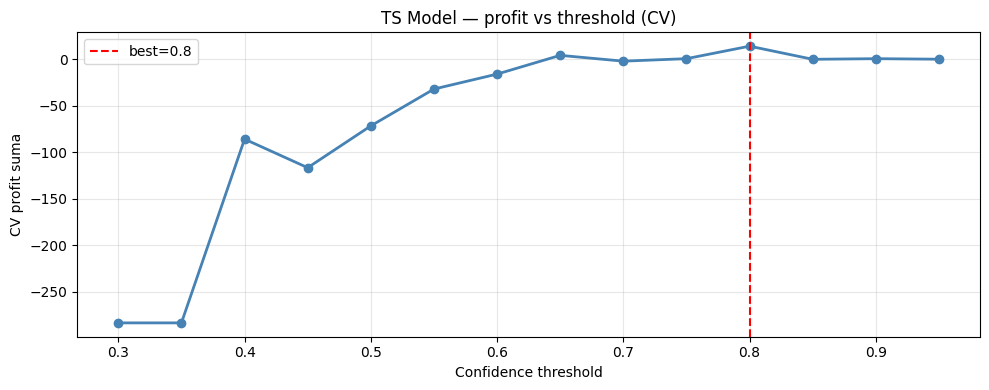

In [60]:
# ── MODEL ─────────────────────────────────────────────────────────────────────

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

class BettingTreeClassifier(BaseEstimator, ClassifierMixin):
    """DecisionTree który trenuje na feature_cols, ignoruje kolumny kursów."""
    def __init__(self, feature_cols, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols     = feature_cols
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state     = random_state

    def fit(self, X, y):
        self.clf_ = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state
        )
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)

    def predict_proba(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

# ── GOLDEN INFO XD ─────────────────────────────────────────────────────────────
feature_cols_with_bets = feature_cols #+ BET_COLS # jak usunąłem z tąd BET_COLS to giga poprawiło wynik :O
                                        # jak coś to skopiowane z poprzednich ale i tak pomaga tutaj wywalenie kursów do treningu
model_ts = BettingTreeClassifier(feature_cols=feature_cols_with_bets, max_depth=4, # tu podmieniłem z 4-> 10
                                  min_samples_leaf=20, random_state=42)             # a tu z 20->30 i giga poprawiło model XD
                                                                                    # ale bardzo pogarsza wynik na df4
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# iteracja po threshold — analogicznie do model_winner
ts_threshold_results = []
print("\n[TS Model] Iteracja po threshold:")
print(f"{'Threshold':>10} | {'CV profit suma':>14} | {'Avg per fold':>12} | {'Zakłady':>8} | {'% obst.':>8} | {'Skuteczność':>12}")
print("-" * 75)

total_train = len(y_train)

for t in np.arange(0.30, 0.96, 0.05):
    t = round(t, 2)
    scorer = make_winner_scorer(t)
    scores = cross_val_score(model_ts, X_train_full, y_train, cv=cv, scoring=scorer)

    # osobno liczymy zakłady/skuteczność na pełnym train (po fitowaniu)
    # używamy tymczasowego modelu żeby nie nadpisać głównego
    m_tmp = BettingTreeClassifier(feature_cols=feature_cols_with_bets,
                                   max_depth=4, min_samples_leaf=20, random_state=42)
    m_tmp.fit(X_train_full, y_train)
    proba_tmp  = m_tmp.predict_proba(X_train_full)
    conf_tmp   = proba_tmp.max(axis=1)
    pred_tmp   = m_tmp.classes_[proba_tmp.argmax(axis=1)]

    profits_tmp = []
    for i in range(len(y_train)):
        if conf_tmp[i] < t:
            continue
        pred = pred_tmp[i]
        true = y_train.iloc[i]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = X_train_full.iloc[i][bet_col]
        profits_tmp.append((odds - 1) if pred == true else -1)

    placed = len(profits_tmp)
    won    = sum(1 for p in profits_tmp if p > 0)
    pct    = placed / total_train * 100
    acc    = won / placed * 100 if placed > 0 else 0

    ts_threshold_results.append({
        'threshold':     t,
        'cv_profit_sum': scores.sum(),
        'cv_profit_avg': scores.mean(),
        'placed':        placed,
        'pct':           pct,
        'acc':           acc,
    })
    print(f"{t:>10.2f} | {scores.sum():>14.2f} | {scores.mean():>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>11.1f}%")

best_ts = max(ts_threshold_results, key=lambda x: x['cv_profit_sum'])
BEST_TS_THRESHOLD = best_ts['threshold']
print(f"\n✓ Najlepszy threshold: {BEST_TS_THRESHOLD}  (profit CV: {best_ts['cv_profit_sum']:.2f})")
model_ts.fit(X_train_full, y_train)

# wykres
plt.figure(figsize=(10, 4))
plt.plot([r['threshold'] for r in ts_threshold_results],
         [r['cv_profit_sum'] for r in ts_threshold_results],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(BEST_TS_THRESHOLD, color='red', linestyle='--',
            label=f'best={BEST_TS_THRESHOLD}')
plt.xlabel('Confidence threshold')
plt.ylabel('CV profit suma')
plt.title('TS Model — profit vs threshold (CV)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ts_model_threshold_curve.png", dpi=150)
plt.show()

In [61]:
# ── EWALUACJA NA DF4 — iteracja po threshold ──────────────────────────────────

proba_ts      = model_ts.predict_proba(X_test_full)
confidence_ts = proba_ts.max(axis=1)
predicted_ts  = model_ts.classes_[proba_ts.argmax(axis=1)]

total = len(df_test_ts)

print(f"\n=== TS MODEL — BENCHMARK df4 ===")
print(f"Łączna liczba meczów: {total}")
print(f"\n{'Threshold':>10} | {'Profit':>10} | {'Zakłady':>8} | {'% obst.':>8} | {'Skuteczność':>12}")
print("-" * 58)

best_test_profit  = -np.inf
best_test_threshold = None

for t in np.arange(0.30, 0.96, 0.05):
    t = round(t, 2)
    profits = []
    for i in range(len(df_test_ts)):
        if confidence_ts[i] < t:
            continue
        pred = predicted_ts[i]
        true = df_test_ts.iloc[i][TARGET_W]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = df_test_ts.iloc[i][bet_col]
        profits.append((odds - 1) if pred == true else -1)

    placed = len(profits)
    won    = sum(1 for p in profits if p > 0)
    profit = sum(profits)
    pct    = placed / total * 100
    acc    = won / placed * 100 if placed > 0 else 0

    if profit > best_test_profit:
        best_test_profit    = profit
        best_test_threshold = t

    print(f"{t:>10.2f} | {profit:>10.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>11.1f}%")

print(f"\n✓ Najlepszy threshold na df4: {best_test_threshold}  (profit: {best_test_profit:.2f})")
print(f"  Threshold z CV:             {BEST_TS_THRESHOLD}")


=== TS MODEL — BENCHMARK df4 ===
Łączna liczba meczów: 3430

 Threshold |     Profit |  Zakłady |  % obst. |  Skuteczność
----------------------------------------------------------
      0.30 |    -123.01 |     3430 |   100.0% |        50.1%
      0.35 |    -123.01 |     3430 |   100.0% |        50.1%
      0.40 |      27.92 |     2458 |    71.7% |        56.2%
      0.45 |      66.93 |     1965 |    57.3% |        59.4%
      0.50 |      41.19 |     1099 |    32.0% |        64.6%
      0.55 |      24.84 |      983 |    28.7% |        65.6%
      0.60 |      24.84 |      746 |    21.7% |        67.7%
      0.65 |      24.84 |      746 |    21.7% |        67.7%
      0.70 |      -3.02 |      213 |     6.2% |        75.6%
      0.75 |      -3.02 |      213 |     6.2% |        75.6%
      0.80 |      -4.56 |       33 |     1.0% |        63.6%
      0.85 |       0.00 |        0 |     0.0% |         0.0%
      0.90 |       0.00 |        0 |     0.0% |         0.0%
      0.95 |       0.00 |

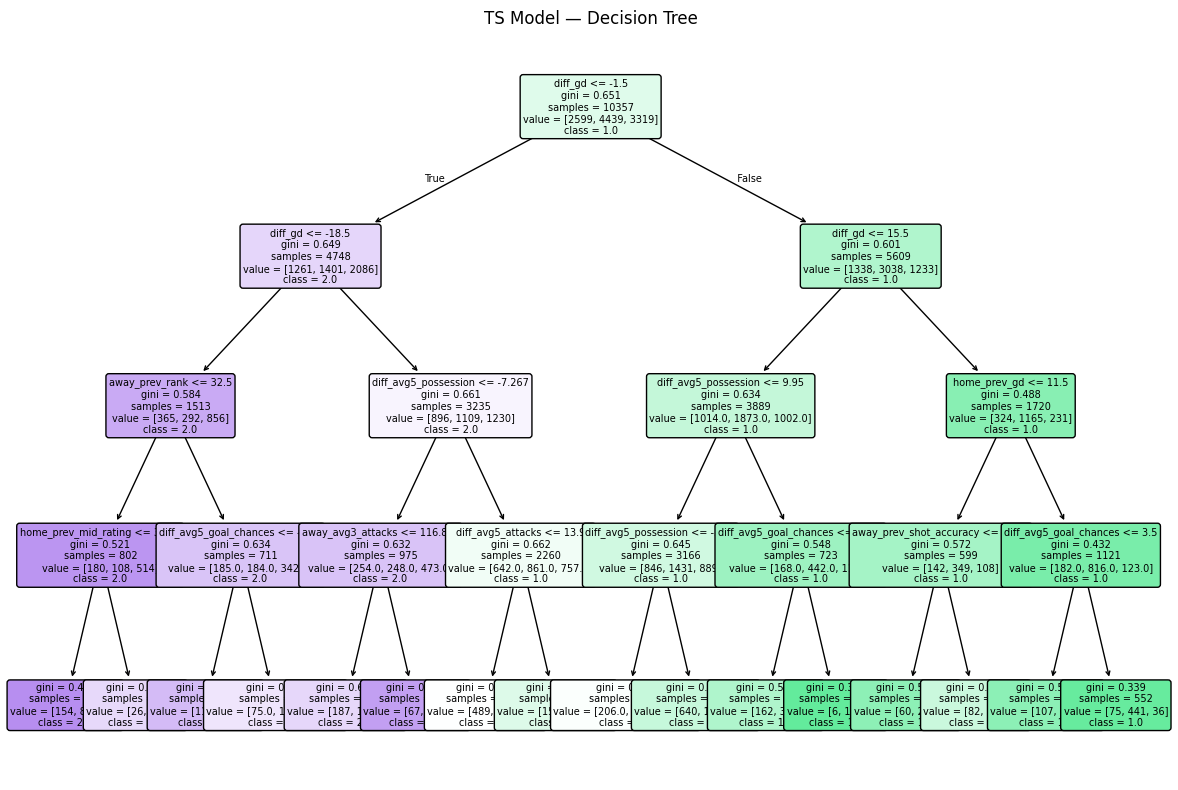

|--- diff_gd <= -1.50
|   |--- diff_gd <= -18.50
|   |   |--- away_prev_rank <= 32.50
|   |   |   |--- home_prev_mid_rating <= 37.85
|   |   |   |   |--- class: 2.0
|   |   |   |--- home_prev_mid_rating >  37.85
|   |   |   |   |--- class: 2.0
|   |   |--- away_prev_rank >  32.50
|   |   |   |--- diff_avg5_goal_chances <= -1.85
|   |   |   |   |--- class: 2.0
|   |   |   |--- diff_avg5_goal_chances >  -1.85
|   |   |   |   |--- class: 2.0
|   |--- diff_gd >  -18.50
|   |   |--- diff_avg5_possession <= -7.27
|   |   |   |--- away_avg3_attacks <= 116.83
|   |   |   |   |--- class: 2.0
|   |   |   |--- away_avg3_attacks >  116.83
|   |   |   |   |--- class: 2.0
|   |   |--- diff_avg5_possession >  -7.27
|   |   |   |--- diff_avg5_attacks <= 13.90
|   |   |   |   |--- class: 1.0
|   |   |   |--- diff_avg5_attacks >  13.90
|   |   |   |   |--- class: 1.0
|--- diff_gd >  -1.50
|   |--- diff_gd <= 15.50
|   |   |--- diff_avg5_possession <= 9.95
|   |   |   |--- diff_avg5_possession <= -5.45
|

In [63]:
# ── WIZUALIZACJA DRZEWA ────────────────────────────────────────────────────────

plt.figure(figsize=(12, 8))
plot_tree(model_ts.clf_, feature_names=feature_cols,
          class_names=[str(c) for c in model_ts.classes_],
          filled=True, rounded=True, fontsize=7)
plt.title("TS Model — Decision Tree")
plt.tight_layout()
plt.savefig("ts_model_tree.png", dpi=600)
plt.show()

print(export_text(model_ts.clf_, feature_names=feature_cols))

### Few plots of reaserch summary

In [ ]:
# ── ANALIZA CECH PRZED REDUKCJĄ ───────────────────────────────────────────────

model_diag = BettingTreeClassifier(
    feature_cols=feature_cols,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)
model_diag.fit(X_train_full, y_train)

importance_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': model_diag.clf_.feature_importances_
}).sort_values('importance', ascending=False)

used     = importance_df[importance_df['importance'] >  0.001]
marginal = importance_df[(importance_df['importance'] > 0) &
                          (importance_df['importance'] <= 0.001)]
zero     = importance_df[importance_df['importance'] == 0]

print(f"Cechy z importance > 0.001:  {len(used)}")
print(f"Cechy marginalne (0, 0.001]: {len(marginal)}")
print(f"Cechy zerowe:                {len(zero)}")

print(f"\n{'Cecha':>40} | {'Importance':>10}")
print("-" * 55)
print("── UŻYWANE (> 0.001) ──")
for _, row in used.iterrows():
    print(f"{row['feature']:>40} | {row['importance']:>10.6f}")

print("\n── MARGINALNE (0 < x <= 0.001) ──")
for _, row in marginal.iterrows():
    print(f"{row['feature']:>40} | {row['importance']:>10.6f}")

print(f"\n── ZEROWE ({len(zero)} cech) ──")
print([r for r in zero['feature'].tolist()])

# ── ANALIZA PAR HOME/AWAY ─────────────────────────────────────────────────────

# wyciągnij bazy (bez home_prev_ / away_prev_ prefixu)
imp_map = dict(zip(importance_df['feature'], importance_df['importance']))

pair_bases = sorted(set(
    c.replace('home_prev_', '').replace('away_prev_', '')
    for c in feature_cols
    if c.startswith('home_prev_') or c.startswith('away_prev_')
))

print(f"\n[Analiza par home/away]")
print(f"{'Baza':>35} | {'home imp':>10} | {'away imp':>10} | {'suma':>8} | {'Decyzja':>15}")
print("-" * 85)

pairs_to_remove = []
pairs_to_keep   = []

for base in pair_bases:
    h_col = f'home_prev_{base}'
    a_col = f'away_prev_{base}'
    h_imp = imp_map.get(h_col, None)
    a_imp = imp_map.get(a_col, None)

    h_str = f"{h_imp:.6f}" if h_imp is not None else "  brak "
    a_str = f"{a_imp:.6f}" if a_imp is not None else "  brak "

    both_exist = h_imp is not None and a_imp is not None
    if both_exist:
        suma = h_imp + a_imp
        both_zero = h_imp <= 0.001 and a_imp <= 0.001
        one_zero  = (h_imp <= 0.001) != (a_imp <= 0.001)  # XOR
        decision  = '✗ USUŃ PARĘ' if both_zero else ('⚠ asymetria' if one_zero else '✓ zostaw')
        if both_zero:
            pairs_to_remove.append(base)
        else:
            pairs_to_keep.append(base)
    else:
        suma     = (h_imp or 0) + (a_imp or 0)
        decision = '? brak pary'

    print(f"{base:>35} | {h_str:>10} | {a_str:>10} | {suma:>8.6f} | {decision:>15}")

# ── DIFF BEZ PARY — zerowe ────────────────────────────────────────────────────

diff_cols  = [c for c in feature_cols if c.startswith('diff_')]
diff_zero  = [c for c in diff_cols if imp_map.get(c, 0) <= 0.001]
diff_used  = [c for c in diff_cols if imp_map.get(c, 0) >  0.001]

print(f"\n[Diff — zerowe/marginalne do usunięcia]")
for c in diff_zero:
    print(f"  {c}: {imp_map.get(c, 0):.6f}")

# ── POJEDYNCZE (liga, formacja) ───────────────────────────────────────────────

single_zero = [
    c for c in feature_cols
    if not c.startswith('home_prev_')
    and not c.startswith('away_prev_')
    and not c.startswith('diff_')
    and imp_map.get(c, 0) <= 0.001
]

print(f"\n[Pojedyncze kolumny zerowe (liga, formacja, itp.)]")
for c in single_zero:
    print(f"  {c}: {imp_map.get(c, 0):.6f}")

# ── PODSUMOWANIE DO USUNIĘCIA ─────────────────────────────────────────────────

cols_to_remove = (
    [f'home_prev_{b}' for b in pairs_to_remove] +
    [f'away_prev_{b}' for b in pairs_to_remove] +
    diff_zero +
    single_zero
)

print(f"\n{'='*55}")
print(f"Pary (bazy) do usunięcia:      {len(pairs_to_remove)}  → {len(pairs_to_remove)*2} kolumn")
print(f"Diff do usunięcia:             {len(diff_zero)}")
print(f"Pojedyncze do usunięcia:       {len(single_zero)}")
print(f"Łącznie do usunięcia:          {len(cols_to_remove)}")
print(f"Pozostanie:                    {len(feature_cols) - len(cols_to_remove)} cech")

print(f"\nPary do usunięcia: {pairs_to_remove}")
print(f"Diff do usunięcia: {diff_zero}")
print(f"Inne do usunięcia: {single_zero}")

# grupy wg kategorii
categories = {
    'raw_data':   [c for c in feature_cols if ('home_prev_' in c or 'away_prev_' in c)
                      and not any(x in c for x in ['rating', 'rank', 'points', 'gd',
                      'efficiency', 'pressure', 'ratio', 'accuracy',
                      'aggression', 'ineffective', 'formation', 'player_'])],
    'players':        [c for c in feature_cols if 'player_' in c],
    'players_ratings': [c for c in feature_cols if 'rating' in c],
    'ranking':       [c for c in feature_cols if any(x in c for x in ['rank', 'points', 'gd'])],
    'efficiency':   [c for c in feature_cols if any(x in c for x in
                      ['efficiency', 'pressure', 'ratio', 'accuracy', 'aggression', 'ineffective'])],
    'differences':          [c for c in feature_cols if c.startswith('diff_')],
    'formations':      [c for c in feature_cols if 'formation' in c],
    'leagues':          [c for c in feature_cols if c.startswith('league_')],
    'match_number':  [c for c in feature_cols if 'match_number' in c],
}

print(f"\n[Podsumowanie wg kategorii]")
print(f"{'Kategoria':>20} | {'Łącznie':>8} | {'Używane':>8} | {'% użytych':>10} | {'Do usunięcia':>13}")
print("-" * 70)
for cat, cols in categories.items():
    used_n   = sum(1 for c in cols if imp_map.get(c, 0) > 0.001)
    remove_n = sum(1 for c in cols if c in cols_to_remove)
    print(f"{cat:>20} | {len(cols):>8} | {used_n:>8} | "
          f"{used_n/len(cols)*100 if cols else 0:>9.1f}% | {remove_n:>13}")



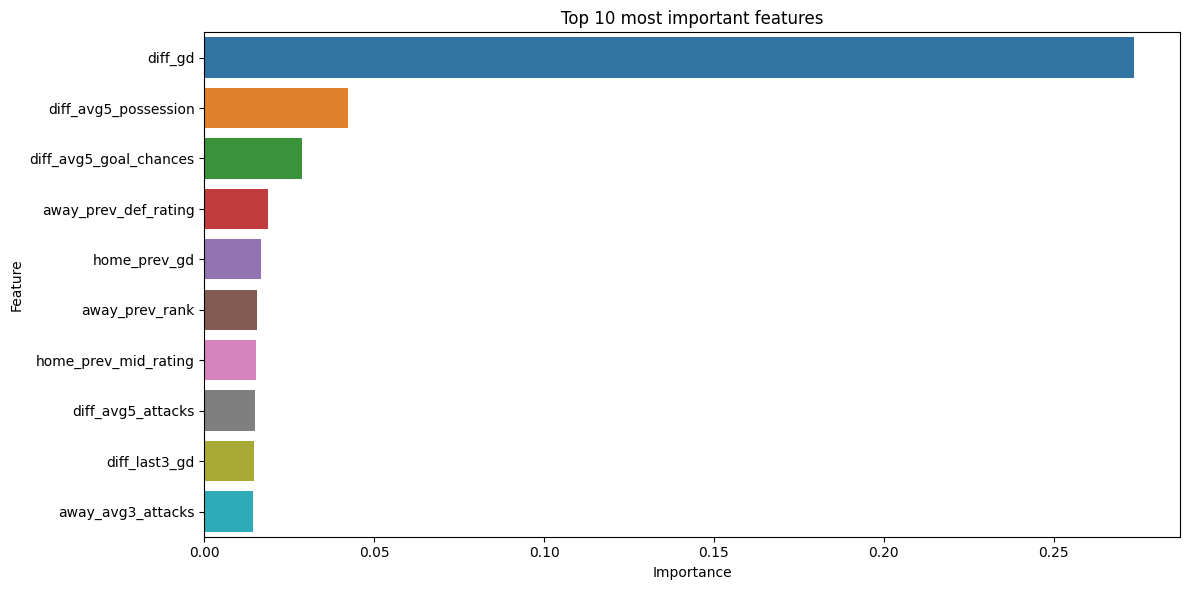

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# ile cech pokazać
TOP_N = 10

top_features = importance_df.head(TOP_N)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_features,
    y='feature',
    x='importance'
)

plt.title(f'Top {TOP_N} most important features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

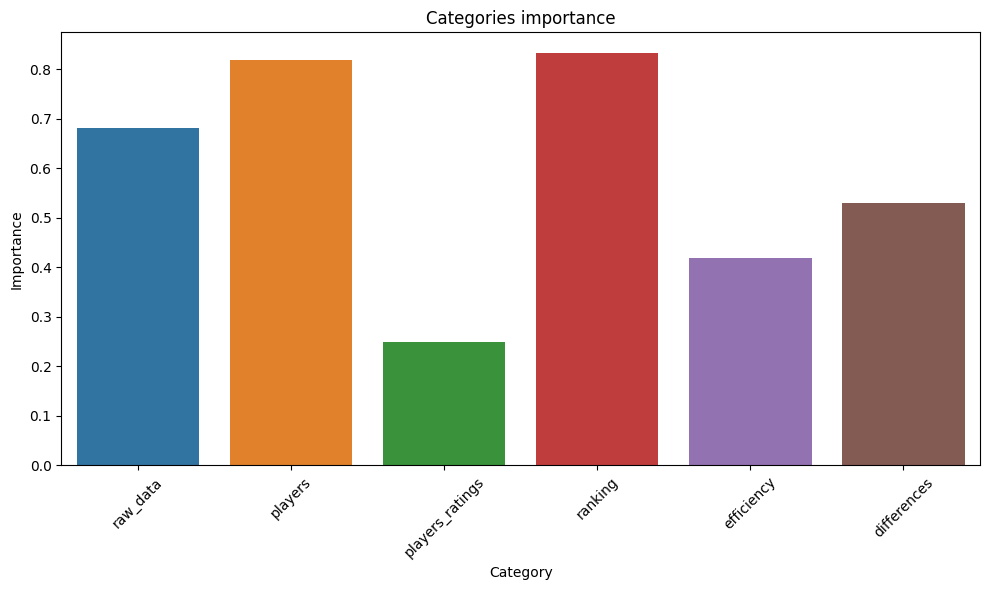

In [78]:
categories = {
    'raw_data':   [c for c in feature_cols if ('home_prev_' in c or 'away_prev_' in c)
                      and not any(x in c for x in ['rating', 'rank', 'points', 'gd',
                      'efficiency', 'pressure', 'ratio', 'accuracy',
                      'aggression', 'ineffective', 'formation', 'player_'])],
    'players':        [c for c in feature_cols if 'player_' in c],
    'players_ratings': [c for c in feature_cols if 'rating' in c],
    'ranking':       [c for c in feature_cols if any(x in c for x in ['rank', 'points', 'gd'])],
    'efficiency':   [c for c in feature_cols if any(x in c for x in
                      ['efficiency', 'pressure', 'ratio', 'accuracy', 'aggression', 'ineffective'])],
    'differences':          [c for c in feature_cols if c.startswith('diff_')]
}

category_stats = []

for cat, cols in categories.items():
    total = len(cols)
    used_n = sum(1 for c in cols if imp_map.get(c, 0) > 0.001)
    
    category_stats.append({
        'category': cat,
        'total': total,
        'used': used_n,
        'used_pct': (used_n / total) if total else 0
    })

cat_df = pd.DataFrame(category_stats)

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_df, x='category', y='used_pct')

plt.title('Categories importance')
plt.ylabel('Importance')
plt.xlabel('Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

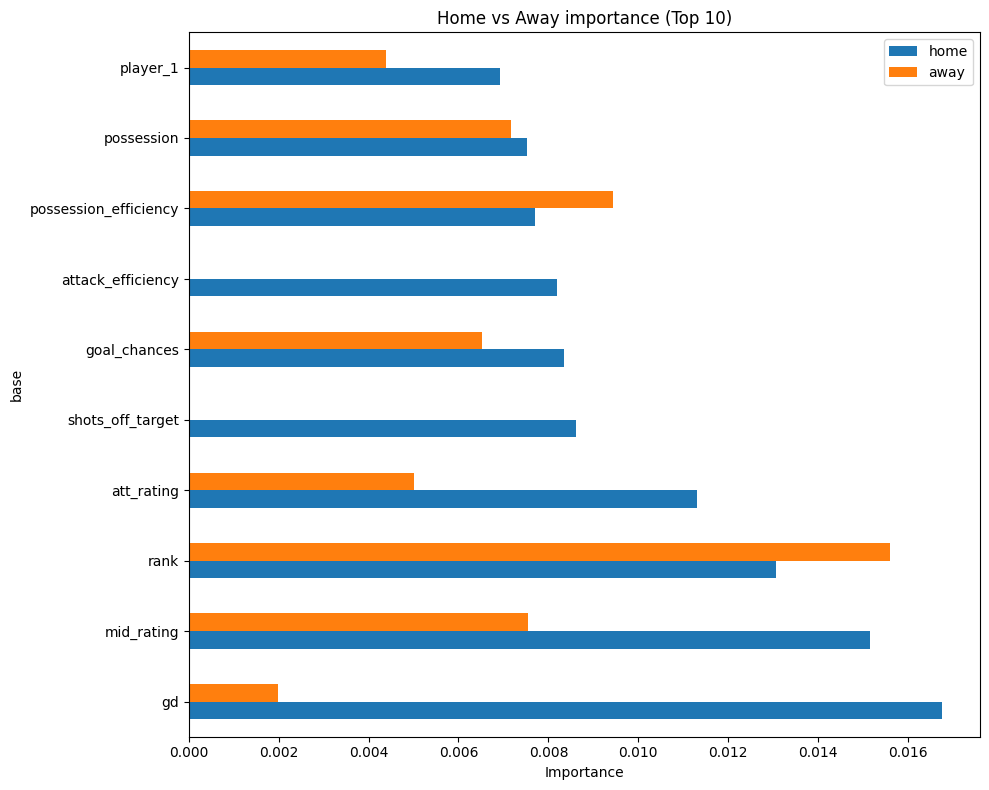

In [76]:
pair_data = []

for base in pair_bases:
    h_col = f'home_prev_{base}'
    a_col = f'away_prev_{base}'
    
    h_imp = imp_map.get(h_col, 0)
    a_imp = imp_map.get(a_col, 0)
    
    pair_data.append({
        'base': base,
        'home': h_imp,
        'away': a_imp
    })

pair_df = pd.DataFrame(pair_data).sort_values('home', ascending=False).head(10)

pair_df.set_index('base')[['home', 'away']].plot(
    kind='barh',
    figsize=(10, 8)
)

plt.title('Home vs Away importance (Top 10)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# 6 Final Betting Strategy and Profitability Analysis - a tu symulacja brania zakładów i robienia ticketów dla najlepszego modelu - jak skończę poprawiać modele

This final step builds upon the previously developed models and focuses on creating betting strategies and evaluating their profitability, now incorporating taxation. Accuracy alone is insufficient; to assess profitability, we must also consider betting odds, match dates, coupon compositions, and models that are trained and tested based on entire seasons rather than random splits—thus simulating real-world scenarios. However, before progressing to this stage, it is essential to complete the `5 Models` section, including feature engineering and revising the model-building methodology.

# 7 Offtop - codes for visualizations & graphics

## Tree complexity and results

### Data preparation

In [1]:
import pandas as pd
import numpy as np
import json
import os
import re
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import StratifiedKFold, KFold, cross_val_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import make_scorer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df1 = pd.read_csv(r"..\data\transformed_data\20_21_transformed.csv")
df2 = pd.read_csv(r"..\data\transformed_data\21_22_transformed.csv")
df3 = pd.read_csv(r"..\data\transformed_data\22_23_transformed.csv")
df4 = pd.read_csv(r"..\data\transformed_data\23_24_transformed.csv")

df_list = [df1, df2, df3, df4]

def make_winner_scorer(threshold):
    def betting_profit_winner(estimator, X, y_true):
        proba      = estimator.predict_proba(X)
        classes    = estimator.classes_
        confidence = proba.max(axis=1)
        predicted  = classes[proba.argmax(axis=1)]

        X_reset = X.reset_index(drop=True)
        y_reset = np.array(y_true)

        profits = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            if conf < threshold:
                continue
            bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
            if bet_col not in X_reset.columns:
                continue  # brak kursu — pomiń zamiast crashować
            odds = X_reset.iloc[i][bet_col]
            profits.append((odds - 1) if pred == true else -1)

        return np.sum(profits) if profits else np.nan  # ← nan zamiast 0.0
    return betting_profit_winner


def betting_profit_goals(estimator, X, y_true):
    """
    Profit scorer dla modelu goli.
    Przewidujemy goals_1 i goals_2, różnica wskazuje typ zakładu:
      goals_1 > goals_2  → typujemy bet_1 (wygrana gospodarza)
      goals_1 < goals_2  → typujemy bet_2 (wygrana gościa)
      goals_1 == goals_2 → typujemy bet_x (remis)
    Zwrot: (kurs - 1) za trafienie, -1 za pudło.
    """
    pred  = np.round(estimator.predict(X)).astype(int)
    y_arr = np.array(y_true)

    profits = []
    for i, (p_row, t_row) in enumerate(zip(pred, y_arr)):
        p1, p2 = p_row[0], p_row[1]
        t1, t2 = t_row[0], t_row[1]

        # decyzja na podstawie przewidywanych goli
        if p1 > p2:
            bet_col      = 'bet_1'
            true_outcome = 1
        elif p1 < p2:
            bet_col      = 'bet_2'
            true_outcome = 2
        else:
            bet_col      = 'bet_x'
            true_outcome = 0

        # prawdziwy wynik
        if t1 > t2:
            actual_outcome = 1
        elif t1 < t2:
            actual_outcome = 2
        else:
            actual_outcome = 0

        odds = X.iloc[i][bet_col]
        profits.append((odds - 1) if true_outcome == actual_outcome else -1)

    return np.sum(profits)

In [2]:
# ── STAŁE ─────────────────────────────────────────────────────────────────────

season_labels = ['2020_21', '2021_22', '2022_23', '2023_24']
EXCLUDE_FROM_FEATURES = ['formation']
BET_COLS = ['bet_1', 'bet_x', 'bet_2']
TARGET_W = 'winner'

def load_time_series(season_label, output_dir="../data/processed"):
    path = os.path.normpath(os.path.join(output_dir, f"season_{season_label}.json"))
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 1 — GRUPOWANIE GRACZY WG POZYCJI
# ═══════════════════════════════════════════════════════════════════════════════

def parse_formation(formation_str):
    """
    Parsuje string formacji np. '4 - 2 - 3 - 1'
    Zwraca (n_def, n_mid, n_att) — bramkarz (player_0) osobno.
    Ostatnia liczba = napastnicy, pierwsza = obrońcy, środkowe = pomocnicy.
    """
    if not isinstance(formation_str, str):
        return None, None, None
    nums = [int(x.strip()) for x in re.findall(r'\d+', formation_str)]
    if len(nums) < 2:
        return None, None, None
    n_def = nums[0]
    n_att = nums[-1]
    n_mid = sum(nums[1:-1])
    return n_def, n_mid, n_att

def add_position_ratings(row, hist, prev_idx, prefix):
    """
    Dodaje do row sumy ocen graczy wg pozycji.
    Gracze: player_0 = bramkarz, player_1..N = pole wg formacji.
    """
    formation = hist.iloc[prev_idx].get('formation', None)
    n_def, n_mid, n_att = parse_formation(formation)

    # oceny wszystkich graczy z poprzedniego meczu
    player_cols = sorted(
        [c for c in hist.columns if re.match(r'player_\d+$', c)],
        key=lambda x: int(x.split('_')[1])
    )
    ratings = []
    for pc in player_cols:
        try:
            ratings.append(float(hist.iloc[prev_idx][pc]))
        except (ValueError, TypeError):
            ratings.append(np.nan)

    if not ratings:
        return row

    row[f'{prefix}_gk_rating'] = ratings[0] if len(ratings) > 0 else np.nan

    field_ratings = ratings[1:]  # bez bramkarza

    if n_def is not None and len(field_ratings) >= n_def:
        row[f'{prefix}_def_rating'] = np.nansum(field_ratings[:n_def])
        remaining = field_ratings[n_def:]
        if n_att is not None and len(remaining) >= n_att:
            row[f'{prefix}_att_rating'] = np.nansum(remaining[-n_att:])
            row[f'{prefix}_mid_rating'] = np.nansum(remaining[:-n_att]) if n_att < len(remaining) else 0
        else:
            row[f'{prefix}_mid_rating'] = np.nan
            row[f'{prefix}_att_rating'] = np.nan
    else:
        row[f'{prefix}_def_rating'] = np.nan
        row[f'{prefix}_mid_rating'] = np.nan
        row[f'{prefix}_att_rating'] = np.nan

    return row

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 2 — RANKING ZESPOŁU W SEZONIE
# ═══════════════════════════════════════════════════════════════════════════════

def build_season_rankings(df_raw):
    """
    Buduje ranking zespołów po każdym meczu w sezonie.
    Zwraca dict: {(team, match_idx): {'points': X, 'rank': Y, 'gd': Z}}
    match_idx = numer meczu tego zespołu w sezonie (0-indexed, przed tym meczem)
    """
    df_sorted = df_raw.sort_values('date').reset_index(drop=True)

    team_stats   = {}  # {team: {'points': 0, 'gd': 0, 'played': 0}}
    rankings     = {}  # {(team, match_idx_before): {'points', 'rank', 'gd'}}
    team_counter = {}

    for _, match in df_sorted.iterrows():
        t1 = match['team_1']
        t2 = match['team_2']

        for t in [t1, t2]:
            if t not in team_stats:
                team_stats[t]   = {'points': 0, 'gd': 0, 'played': 0}
            if t not in team_counter:
                team_counter[t] = 0

        # zapisz ranking PRZED tym meczem
        all_teams = list(team_stats.keys())
        sorted_teams = sorted(all_teams,
                               key=lambda x: (team_stats[x]['points'],
                                              team_stats[x]['gd']),
                               reverse=True)
        rank_map = {t: i+1 for i, t in enumerate(sorted_teams)}

        for t in [t1, t2]:
            idx = team_counter[t]
            rankings[(t, idx)] = {
                'points': team_stats[t]['points'],
                'rank':   rank_map[t],
                'gd':     team_stats[t]['gd'],
            }
            team_counter[t] += 1

        # aktualizuj statystyki PO meczu
        g1, g2   = match['goals_1'], match['goals_2']
        winner   = match['winner']

        if winner == 1:
            team_stats[t1]['points'] += 3
        elif winner == 0:
            team_stats[t1]['points'] += 1
            team_stats[t2]['points'] += 1
        else:
            team_stats[t2]['points'] += 3

        try:
            team_stats[t1]['gd'] += int(g1) - int(g2)
            team_stats[t2]['gd'] += int(g2) - int(g1)
        except (ValueError, TypeError):
            pass

        team_stats[t1]['played'] += 1
        team_stats[t2]['played'] += 1

    return rankings

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 3 — EFEKTYWNOŚĆ ATAKU I OBRONY (z poprzedniego meczu)
# ═══════════════════════════════════════════════════════════════════════════════

def add_efficiency_features(row, prev_row, prefix):
    """Dodaje wskaźniki efektywności wyliczone z poprzedniego meczu."""
    goals     = _f(prev_row, 'goals')
    shots_on  = _f(prev_row, 'shots_on_target')
    shots_off = _f(prev_row, 'shots_off_target')
    attacks   = _f(prev_row, 'attacks')
    dan_att   = _f(prev_row, 'dangerous_attacks')

    total_shots = (shots_on or 0) + (shots_off or 0)

    # ile strzałów celnych na gola
    row[f'{prefix}_attack_efficiency'] = (
        goals / shots_on if shots_on and shots_on > 0 else 0
    )
    # jaki % ataków kończy się strzałem celnym
    row[f'{prefix}_attack_pressure'] = (
        shots_on / attacks if attacks and attacks > 0 else 0
    )
    # jak groźne są ataki
    row[f'{prefix}_danger_ratio'] = (
        dan_att / attacks if attacks and attacks > 0 else 0
    )
    # celność strzałów
    row[f'{prefix}_shot_accuracy'] = (
        shots_on / total_shots if total_shots > 0 else 0
    )
    return row

def _f(prev_row, col):
    """Bezpieczne pobranie float z Series."""
    try:
        return float(prev_row[col])
    except (KeyError, ValueError, TypeError):
        return None

In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 4 — STYL GRY
# ═══════════════════════════════════════════════════════════════════════════════

def add_style_features(row, prev_row, prefix):
    """Dodaje cechy stylu gry z poprzedniego meczu."""
    attacks   = _f(prev_row, 'attacks')
    dan_att   = _f(prev_row, 'dangerous_attacks')
    shots_on  = _f(prev_row, 'shots_on_target')
    gk_saves  = _f(prev_row, 'goalkeeper_saves')
    goals     = _f(prev_row, 'goals')
    possession= _f(prev_row, 'possession')

    # ataki mało groźne — proxy na posiadanie bez efektu
    row[f'{prefix}_ineffective_attacks'] = (
        (attacks - dan_att) if attacks is not None and dan_att is not None else np.nan
    )
    # agresywność ofensywna (strzały na bramkę na atak)
    row[f'{prefix}_offensive_aggression'] = (
        shots_on / attacks if attacks and attacks > 0 else 0
    )
    # skuteczność obrony (uratowane / wszystkie strzały na bramkę przeciwnika)
    # gk_saves / (gk_saves + goals_conceded) — goals tu to gole strzelone przez ten zespół
    # gole stracone = goals przeciwnika — dołączamy później w diff
    row[f'{prefix}_possession_efficiency'] = (
        goals / possession if possession and possession > 0 else 0
    )
    return row

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 5 — RÓŻNICE HOME vs AWAY
# ═══════════════════════════════════════════════════════════════════════════════

DIFF_COLS = [
    'goals', 'attacks', 'dangerous_attacks', 'possession',
    'shots_on_target', 'shots_off_target', 'goal_chances',
    'attack_efficiency', 'attack_pressure', 'danger_ratio',
    'shot_accuracy', 'offensive_aggression',
]

def add_diff_features(row):
    """Dodaje różnice home - away dla kluczowych cech."""
    for col in DIFF_COLS:
        h = row.get(f'home_prev_{col}')
        a = row.get(f'away_prev_{col}')
        if h is not None and a is not None:
            try:
                row[f'diff_{col}'] = float(h) - float(a)
            except (ValueError, TypeError):
                row[f'diff_{col}'] = np.nan
        else:
            row[f'diff_{col}'] = np.nan

    # różnica rankingu i punktów
    for col in ['rank', 'points', 'gd']:
        h = row.get(f'home_prev_{col}')
        a = row.get(f'away_prev_{col}')
        if h is not None and a is not None:
            row[f'diff_{col}'] = float(h) - float(a)
        else:
            row[f'diff_{col}'] = np.nan

    return row

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# GŁÓWNA FUNKCJA BUDOWANIA WIERSZY
# ═══════════════════════════════════════════════════════════════════════════════

def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    df_sorted  = df_raw.sort_values('date').reset_index(drop=True)
    rankings   = build_season_rankings(df_raw)  # blok 2

    for _, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']

        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue
        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        hist_1 = pd.DataFrame(ts_data[team_1])
        hist_2 = pd.DataFrame(ts_data[team_2])
        prev_idx_1, prev_idx_2 = idx_1 - 1, idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # statystyki surowe z poprzedniego meczu
        for col in prev_1.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        for col in prev_2.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        # blok 1 — oceny graczy wg pozycji
        row = add_position_ratings(row, hist_1, prev_idx_1, 'home_prev')
        row = add_position_ratings(row, hist_2, prev_idx_2, 'away_prev')

        # blok 2 — ranking
        rank_1 = rankings.get((team_1, idx_1), {})
        rank_2 = rankings.get((team_2, idx_2), {})
        for k, v in rank_1.items():
            row[f'home_prev_{k}'] = v
        for k, v in rank_2.items():
            row[f'away_prev_{k}'] = v

        # blok 3 — efektywność
        row = add_efficiency_features(row, prev_1, 'home_prev')
        row = add_efficiency_features(row, prev_2, 'away_prev')

        # blok 4 — styl gry
        row = add_style_features(row, prev_1, 'home_prev')
        row = add_style_features(row, prev_2, 'away_prev')

        # blok 5 — różnice home vs away (na końcu bo używa już wyliczonych cech)
        row = add_diff_features(row)

        # kursy, targety, meta
        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W]  = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        row['league']  = match['league']
        row['team_1']  = team_1
        row['team_2']  = team_2
        row['date']    = match['date']

        rows.append(row)

    return pd.DataFrame(rows)

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 6 — KATEGORYZACJA FORMACJI (defensywna / wyważona / ofensywna)
# ═══════════════════════════════════════════════════════════════════════════════

def classify_formation(formation_str):
    """
    Klasyfikuje formację na podstawie liczby napastników (ostatnia liczba):
      0 - defensywna:  1 napastnik  (np. 4-5-1, 5-4-1, 4-1-4-1)
      1 - wyważona:    2 napastników (np. 4-4-2, 4-2-3-1 liczy się jako 1 bo ostatnia=1)
      2 - ofensywna:   3+ napastników (np. 4-3-3, 3-4-3)

    Szczegółowo:
      ostatnia liczba = 1 → defensywna (0)
      ostatnia liczba = 2 → wyważona   (1)
      ostatnia liczba = 3 → ofensywna  (2)
    """
    if not isinstance(formation_str, str):
        return np.nan
    nums = [int(x.strip()) for x in re.findall(r'\d+', formation_str)]
    if not nums:
        return np.nan
    attackers = nums[-1]
    if attackers <= 1:
        return 0   # defensywna
    elif attackers == 2:
        return 1   # wyważona
    else:
        return 2   # ofensywna

In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 7 — HISTORIA WYNIKÓW PER ZESPÓŁ (z df_raw)
# ═══════════════════════════════════════════════════════════════════════════════

def build_team_results_history(df_raw: pd.DataFrame) -> dict:
    """
    Buduje historię wyników per zespół w kolejności chronologicznej.
    Zwraca dict: {team: [{points, gd, won, draw, lost}, ...]}
    Indeks listy odpowiada match_idx (jak w ts_data i team_match_counter).
    """
    df_sorted    = df_raw.sort_values('date').reset_index(drop=True)
    team_counter = {}
    history      = {}  # {team: [{'points_earned', 'gd', 'won', 'draw', 'lost'}, ...]}

    for _, match in df_sorted.iterrows():
        t1     = match['team_1']
        t2     = match['team_2']
        winner = match['winner']

        try:
            g1 = int(match['goals_1'])
            g2 = int(match['goals_2'])
        except (ValueError, TypeError):
            g1, g2 = 0, 0

        for t in [t1, t2]:
            if t not in team_counter:
                team_counter[t] = 0
            if t not in history:
                history[t] = []

        # wynik dla team_1
        if winner == 1:
            r1 = {'points_earned': 3, 'gd': g1 - g2, 'won': 1, 'draw': 0, 'lost': 0}
            r2 = {'points_earned': 0, 'gd': g2 - g1, 'won': 0, 'draw': 0, 'lost': 1}
        elif winner == 0:
            r1 = {'points_earned': 1, 'gd': g1 - g2, 'won': 0, 'draw': 1, 'lost': 0}
            r2 = {'points_earned': 1, 'gd': g2 - g1, 'won': 0, 'draw': 1, 'lost': 0}
        else:
            r1 = {'points_earned': 0, 'gd': g1 - g2, 'won': 0, 'draw': 0, 'lost': 1}
            r2 = {'points_earned': 3, 'gd': g2 - g1, 'won': 1, 'draw': 0, 'lost': 0}

        history[t1].append(r1)
        history[t2].append(r2)
        team_counter[t1] += 1
        team_counter[t2] += 1

    return history


# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 8 — AGREGACJE FORMY (last3, last5) I PUNKTÓW (last10)
# ═══════════════════════════════════════════════════════════════════════════════

def get_form_aggregates(history: list, prev_idx: int) -> dict:
    """
    Liczy agregaty z ostatnich N wyników PRZED tym meczem (kończy na prev_idx).
    history = lista słowników [{points_earned, gd, won, draw, lost}, ...]
    prev_idx = indeks ostatniego dostępnego meczu (włącznie)
    """
    agg = {}

    # historia do prev_idx włącznie
    available = history[:prev_idx + 1]

    for n, keys in [(3, ['points', 'gd', 'wins', 'draws', 'losses']),
                    (5, ['points', 'gd', 'wins', 'draws', 'losses']),
                    (10, ['points'])]:

        window = available[-n:]  # ostatnie N wyników

        if not window:
            for k in keys:
                agg[f'last{n}_{k}'] = np.nan
            continue

        agg[f'last{n}_points'] = sum(r['points_earned'] for r in window)

        if n <= 5:
            agg[f'last{n}_gd']     = sum(r['gd']   for r in window)
            agg[f'last{n}_wins']   = sum(r['won']   for r in window)
            agg[f'last{n}_draws']  = sum(r['draw']  for r in window)
            agg[f'last{n}_losses'] = sum(r['lost']  for r in window)

    return agg


# ═══════════════════════════════════════════════════════════════════════════════
# BLOK 9 — AGREGACJE STATYSTYK MECZOWYCH (last3, last5)
# ═══════════════════════════════════════════════════════════════════════════════

# kolumny do agregacji — tylko te z sumą importance > 0.02
STATS_TO_AGG = [
    'attacks', 'dangerous_attacks', 'goal_chances', 'possession',
    'shot_accuracy', 'attack_efficiency', 'danger_ratio', 'ineffective_attacks',
]

# oceny pozycji — agregowane osobno
RATINGS_TO_AGG = ['gk_rating', 'def_rating', 'mid_rating', 'att_rating']

def get_stats_aggregates(hist_df: pd.DataFrame, prev_idx: int) -> dict:
    """
    Liczy średnie z ostatnich 3 i 5 meczów dla statystyk i ocen pozycji.
    hist_df = pd.DataFrame(ts_data[team])
    prev_idx = indeks ostatniego dostępnego meczu
    """
    agg = {}
    available = hist_df.iloc[:prev_idx + 1]

    for n in [3, 5]:
        window = available.iloc[-n:]

        # statystyki meczowe
        for col in STATS_TO_AGG:
            if col in window.columns:
                vals = pd.to_numeric(window[col], errors='coerce')
                agg[f'avg{n}_{col}'] = vals.mean()
            else:
                agg[f'avg{n}_{col}'] = np.nan

        # oceny pozycji
        for col in RATINGS_TO_AGG:
            if col in window.columns:
                vals = pd.to_numeric(window[col], errors='coerce')
                agg[f'avg{n}_{col}'] = vals.mean()
            else:
                # próba wyliczenia z player_* jeśli brak gotowej kolumny
                agg[f'avg{n}_{col}'] = np.nan

    return agg


# ═══════════════════════════════════════════════════════════════════════════════
# AKTUALIZACJA build_training_rows — dodanie bloków 7, 8, 9
# ═══════════════════════════════════════════════════════════════════════════════

def build_training_rows(df_raw: pd.DataFrame, ts_data: dict) -> pd.DataFrame:
    rows = []
    team_match_counter = {}
    df_sorted  = df_raw.sort_values('date').reset_index(drop=True)
    rankings   = build_season_rankings(df_raw)       # blok 2
    results_h  = build_team_results_history(df_raw)  # blok 7

    for _, match in df_sorted.iterrows():
        team_1 = match['team_1']
        team_2 = match['team_2']

        for team in [team_1, team_2]:
            if team not in team_match_counter:
                team_match_counter[team] = 0

        idx_1 = team_match_counter[team_1]
        idx_2 = team_match_counter[team_2]
        team_match_counter[team_1] += 1
        team_match_counter[team_2] += 1

        if idx_1 == 0 or idx_2 == 0:
            continue
        if team_1 not in ts_data or team_2 not in ts_data:
            continue

        hist_1 = pd.DataFrame(ts_data[team_1])
        hist_2 = pd.DataFrame(ts_data[team_2])
        prev_idx_1, prev_idx_2 = idx_1 - 1, idx_2 - 1

        if prev_idx_1 >= len(hist_1) or prev_idx_2 >= len(hist_2):
            continue

        prev_1 = hist_1.iloc[prev_idx_1]
        prev_2 = hist_2.iloc[prev_idx_2]

        row = {}

        # statystyki surowe z poprzedniego meczu
        for col in prev_1.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'home_prev_{col}'] = prev_1[col]
        for col in prev_2.index:
            if col in EXCLUDE_FROM_FEATURES:
                continue
            row[f'away_prev_{col}'] = prev_2[col]

        row['home_match_number'] = idx_1 + 1
        row['away_match_number'] = idx_2 + 1

        # blok 1 — oceny graczy wg pozycji
        row = add_position_ratings(row, hist_1, prev_idx_1, 'home_prev')
        row = add_position_ratings(row, hist_2, prev_idx_2, 'away_prev')

        # blok 2 — ranking
        rank_1 = rankings.get((team_1, idx_1), {})
        rank_2 = rankings.get((team_2, idx_2), {})
        for k, v in rank_1.items():
            row[f'home_prev_{k}'] = v
        for k, v in rank_2.items():
            row[f'away_prev_{k}'] = v

        # blok 3 — efektywność
        row = add_efficiency_features(row, prev_1, 'home_prev')
        row = add_efficiency_features(row, prev_2, 'away_prev')

        # blok 4 — styl gry
        row = add_style_features(row, prev_1, 'home_prev')
        row = add_style_features(row, prev_2, 'away_prev')

        # blok 5 — różnice home vs away
        row = add_diff_features(row)

        # blok 8 — agregaty formy (last3, last5, last10)
        hist_res_1 = results_h.get(team_1, [])
        hist_res_2 = results_h.get(team_2, [])
        form_1 = get_form_aggregates(hist_res_1, prev_idx_1)
        form_2 = get_form_aggregates(hist_res_2, prev_idx_2)
        for k, v in form_1.items():
            row[f'home_{k}'] = v
        for k, v in form_2.items():
            row[f'away_{k}'] = v

        # blok 9 — agregaty statystyk (avg3, avg5)
        stats_1 = get_stats_aggregates(hist_1, prev_idx_1)
        stats_2 = get_stats_aggregates(hist_2, prev_idx_2)
        for k, v in stats_1.items():
            row[f'home_{k}'] = v
        for k, v in stats_2.items():
            row[f'away_{k}'] = v

        # różnice dla nowych agregacji
        for k in form_1:
            h = row.get(f'home_{k}')
            a = row.get(f'away_{k}')
            if h is not None and a is not None:
                try:
                    row[f'diff_{k}'] = float(h) - float(a)
                except (ValueError, TypeError):
                    row[f'diff_{k}'] = np.nan

        for k in stats_1:
            h = row.get(f'home_{k}')
            a = row.get(f'away_{k}')
            if h is not None and a is not None:
                try:
                    row[f'diff_{k}'] = float(h) - float(a)
                except (ValueError, TypeError):
                    row[f'diff_{k}'] = np.nan

        # kursy, targety, meta
        for bc in BET_COLS:
            row[bc] = match[bc]

        row[TARGET_W]  = match[TARGET_W]
        row['goals_1'] = match['goals_1']
        row['goals_2'] = match['goals_2']
        row['league']  = match['league']
        row['team_1']  = team_1
        row['team_2']  = team_2
        row['date']    = match['date']

        rows.append(row)

    return pd.DataFrame(rows)

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# BUDOWA ZBIORÓW
# ═══════════════════════════════════════════════════════════════════════════════

train_dfs = []
for df_raw, label in zip([df1, df2, df3], ['2020_21', '2021_22', '2022_23']):
    ts_data = load_time_series(label)
    built   = build_training_rows(df_raw, ts_data)
    train_dfs.append(built)
    print(f"[{label}] wiersze: {len(built)}, cechy: {built.shape[1]}")

df_train_ts = pd.concat(train_dfs, ignore_index=True)
ts_data_test = load_time_series('2023_24')
df_test_ts   = build_training_rows(df4, ts_data_test)

# blok 6 — aplikacja klasyfikacji formacji po zbudowaniu df
for prefix, raw_col in [('home_prev', 'home_prev_formation'),
                         ('away_prev', 'away_prev_formation')]:
    out_col = f'{prefix}_formation_type'
    for df_ in [df_train_ts, df_test_ts]:
        if raw_col in df_.columns:
            df_[out_col] = df_[raw_col].apply(classify_formation)
        else:
            df_[out_col] = np.nan

# różnica stylu formacji home vs away
df_train_ts['diff_formation_type'] = (
    df_train_ts['home_prev_formation_type'] - df_train_ts['away_prev_formation_type']
)
df_test_ts['diff_formation_type'] = (
    df_test_ts['home_prev_formation_type'] - df_test_ts['away_prev_formation_type']
)

# podgląd rozkładu
print("\n[Blok 6] Rozkład typów formacji (train):")
for col in ['home_prev_formation_type', 'away_prev_formation_type']:
    if col in df_train_ts.columns:
        counts = df_train_ts[col].value_counts().sort_index()
        labels = {0: 'defensywna', 1: 'wyważona', 2: 'ofensywna'}
        print(f"\n  {col}:")
        for k, v in counts.items():
            print(f"    {labels.get(k, '?'):>12}: {v:>6} ({v/len(df_train_ts)*100:.1f}%)")

# ── ENKODOWANIE LIGI ──────────────────────────────────────────────────────────

df_all      = pd.concat([df_train_ts, df_test_ts], ignore_index=True)
all_leagues = df_all['league'].dropna().unique()

for league in all_leagues:
    col_name = f"league_{league.replace(' ', '_')}"
    df_train_ts[col_name] = (df_train_ts['league'] == league).astype(int)
    df_test_ts[col_name]  = (df_test_ts['league']  == league).astype(int)

league_feature_cols = [f"league_{l.replace(' ', '_')}" for l in all_leagues]
print(f"\nKolumny ligi: {len(league_feature_cols)}")

[2020_21] wiersze: 3453, cechy: 204
[2021_22] wiersze: 3469, cechy: 204
[2022_23] wiersze: 3435, cechy: 204

[Blok 6] Rozkład typów formacji (train):

  home_prev_formation_type:

  away_prev_formation_type:

Kolumny ligi: 13


In [12]:
# ── PRZYGOTOWANIE CECH ────────────────────────────────────────────────────────

META_COLS     = ['team_1', 'team_2', 'date', TARGET_W, 'goals_1', 'goals_2',
                 'league', 'home_prev_formation', 'away_prev_formation']
NUMERIC_TYPES = ['float64', 'int64', 'float32', 'int32', 'uint8', 'int8']

feature_cols = [
    c for c in df_train_ts.columns
    if c not in META_COLS
    and c not in BET_COLS
    and df_train_ts[c].dtype.name in NUMERIC_TYPES
]

print(f"Liczba cech modelu: {len(feature_cols)}")
formation_feats = [c for c in feature_cols if 'formation' in c]
print(f"Cechy formacji: {formation_feats}")

new_feat_examples = [c for c in feature_cols if any(x in c for x in
    ['rating', 'rank', 'points', 'efficiency', 'pressure', 'ratio',
     'accuracy', 'aggression', 'diff_', 'ineffective', 'formation'])]

X_train_full = df_train_ts[feature_cols + BET_COLS].fillna(0)
X_test_full  = df_test_ts[feature_cols + BET_COLS].fillna(0)
y_train      = df_train_ts[TARGET_W]
y_test       = df_test_ts[TARGET_W]

print(f"\nX_train: {X_train_full.shape}")
print(f"X_test:  {X_test_full.shape}")

Liczba cech modelu: 210
Cechy formacji: ['home_prev_formation_type', 'away_prev_formation_type', 'diff_formation_type']

X_train: (10357, 213)
X_test:  (3430, 213)


### Model run + charts


[TS Model] Iteracja po threshold:
 Threshold | CV profit suma | Avg per fold |  Zakłady |  % obst. |  Skuteczność
---------------------------------------------------------------------------
      0.30 |        -283.40 |       -56.68 |    10357 |   100.0% |        50.5%
      0.35 |        -283.40 |       -56.68 |    10357 |   100.0% |        50.5%
      0.40 |         -85.89 |       -17.18 |     7803 |    75.3% |        55.0%
      0.45 |        -116.61 |       -23.32 |     6285 |    60.7% |        57.8%
      0.50 |         -71.66 |       -14.33 |     3617 |    34.9% |        65.1%
      0.55 |         -32.08 |        -6.42 |     3222 |    31.1% |        66.6%
      0.60 |         -16.01 |        -3.20 |     2304 |    22.2% |        70.2%
      0.65 |           4.14 |         0.83 |     2304 |    22.2% |        70.2%
      0.70 |          -2.10 |        -0.42 |      683 |     6.6% |        80.2%
      0.75 |           0.58 |         0.12 |      683 |     6.6% |        80.2%
      0.8

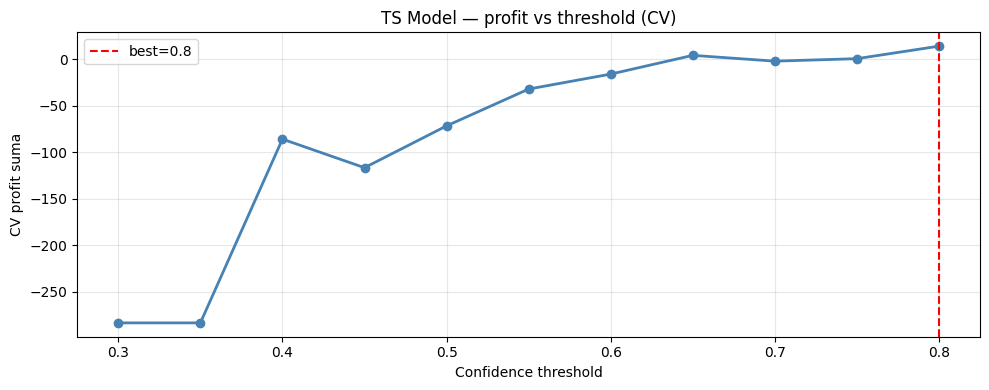

In [ ]:
# ── MODEL ─────────────────────────────────────────────────────────────────────

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted

class BettingTreeClassifier(BaseEstimator, ClassifierMixin):
    """DecisionTree który trenuje na feature_cols, ignoruje kolumny kursów."""
    def __init__(self, feature_cols, max_depth=4, min_samples_leaf=20, random_state=42):
        self.feature_cols     = feature_cols
        self.max_depth        = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state     = random_state

    def fit(self, X, y):
        self.clf_ = DecisionTreeClassifier(
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            random_state=self.random_state
        )
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        self.clf_.fit(X_feats, y)
        self.classes_ = self.clf_.classes_
        return self

    def predict(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict(X_feats)

    def predict_proba(self, X):
        check_is_fitted(self)
        X_feats = X[self.feature_cols] if hasattr(X, 'columns') else X
        return self.clf_.predict_proba(X_feats)

feature_cols_with_bets = feature_cols
model_ts = BettingTreeClassifier(feature_cols=feature_cols_with_bets, max_depth=4, # tu podmieniłem z 4-> 10
                                  min_samples_leaf=20, random_state=42)             # a tu z 20->30 i giga poprawiło model XD
                                                                                    # ale bardzo pogarsza wynik na df4
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# iteracja po threshold — analogicznie do model_winner
ts_threshold_results = []
print("\n[TS Model] Iteracja po threshold:")
print(f"{'Threshold':>10} | {'CV profit suma':>14} | {'Avg per fold':>12} | {'Zakłady':>8} | {'% obst.':>8} | {'Skuteczność':>12}")
print("-" * 75)

total_train = len(y_train)

for t in np.arange(0.30, 0.96, 0.05):
    t = round(t, 2)
    scorer = make_winner_scorer(t)
    scores = cross_val_score(model_ts, X_train_full, y_train, cv=cv, scoring=scorer)

    # osobno liczymy zakłady/skuteczność na pełnym train (po fitowaniu)
    # używamy tymczasowego modelu żeby nie nadpisać głównego
    m_tmp = BettingTreeClassifier(feature_cols=feature_cols_with_bets,
                                   max_depth=4, min_samples_leaf=20, random_state=42)
    m_tmp.fit(X_train_full, y_train)
    proba_tmp  = m_tmp.predict_proba(X_train_full)
    conf_tmp   = proba_tmp.max(axis=1)
    pred_tmp   = m_tmp.classes_[proba_tmp.argmax(axis=1)]

    profits_tmp = []
    for i in range(len(y_train)):
        if conf_tmp[i] < t:
            continue
        pred = pred_tmp[i]
        true = y_train.iloc[i]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = X_train_full.iloc[i][bet_col]
        profits_tmp.append((odds - 1) if pred == true else -1)

    placed = len(profits_tmp)
    won    = sum(1 for p in profits_tmp if p > 0)
    pct    = placed / total_train * 100
    acc    = won / placed * 100 if placed > 0 else 0

    ts_threshold_results.append({
        'threshold':     t,
        'cv_profit_sum': scores.sum(),
        'cv_profit_avg': scores.mean(),
        'placed':        placed,
        'pct':           pct,
        'acc':           acc,
    })
    print(f"{t:>10.2f} | {scores.sum():>14.2f} | {scores.mean():>12.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>11.1f}%")

best_ts = max(ts_threshold_results, key=lambda x: x['cv_profit_sum'])
BEST_TS_THRESHOLD = best_ts['threshold']
print(f"\n✓ Najlepszy threshold: {BEST_TS_THRESHOLD}  (profit CV: {best_ts['cv_profit_sum']:.2f})")
model_ts.fit(X_train_full, y_train)

In [14]:
# ── EWALUACJA NA DF4 — iteracja po threshold ──────────────────────────────────

proba_ts      = model_ts.predict_proba(X_test_full)
confidence_ts = proba_ts.max(axis=1)
predicted_ts  = model_ts.classes_[proba_ts.argmax(axis=1)]

total = len(df_test_ts)

print(f"\n=== TS MODEL — BENCHMARK df4 ===")
print(f"Łączna liczba meczów: {total}")
print(f"\n{'Threshold':>10} | {'Profit':>10} | {'Zakłady':>8} | {'% obst.':>8} | {'Skuteczność':>12}")
print("-" * 58)

best_test_profit  = -np.inf
best_test_threshold = None

for t in np.arange(0.30, 0.96, 0.05):
    t = round(t, 2)
    profits = []
    for i in range(len(df_test_ts)):
        if confidence_ts[i] < t:
            continue
        pred = predicted_ts[i]
        true = df_test_ts.iloc[i][TARGET_W]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = df_test_ts.iloc[i][bet_col]
        profits.append((odds - 1) if pred == true else -1)

    placed = len(profits)
    won    = sum(1 for p in profits if p > 0)
    profit = sum(profits)
    pct    = placed / total * 100
    acc    = won / placed * 100 if placed > 0 else 0

    if profit > best_test_profit:
        best_test_profit    = profit
        best_test_threshold = t

    print(f"{t:>10.2f} | {profit:>10.2f} | {placed:>8} | {pct:>7.1f}% | {acc:>11.1f}%")

print(f"\n✓ Najlepszy threshold na df4: {best_test_threshold}  (profit: {best_test_profit:.2f})")
print(f"  Threshold z CV:             {BEST_TS_THRESHOLD}")


=== TS MODEL — BENCHMARK df4 ===
Łączna liczba meczów: 3430

 Threshold |     Profit |  Zakłady |  % obst. |  Skuteczność
----------------------------------------------------------
      0.30 |    -123.01 |     3430 |   100.0% |        50.1%
      0.35 |    -123.01 |     3430 |   100.0% |        50.1%
      0.40 |      27.92 |     2458 |    71.7% |        56.2%
      0.45 |      66.93 |     1965 |    57.3% |        59.4%
      0.50 |      41.19 |     1099 |    32.0% |        64.6%
      0.55 |      24.84 |      983 |    28.7% |        65.6%
      0.60 |      24.84 |      746 |    21.7% |        67.7%
      0.65 |      24.84 |      746 |    21.7% |        67.7%
      0.70 |      -3.02 |      213 |     6.2% |        75.6%
      0.75 |      -3.02 |      213 |     6.2% |        75.6%
      0.80 |      -4.56 |       33 |     1.0% |        63.6%
      0.85 |       0.00 |        0 |     0.0% |         0.0%
      0.90 |       0.00 |        0 |     0.0% |         0.0%
      0.95 |       0.00 |

In [15]:
# CV profit — scorer z ograniczeniem min_bets
def make_winner_scorer_minbets(threshold, min_bets):
    def scorer(estimator, X, y_true):
        proba      = estimator.predict_proba(X)
        classes    = estimator.classes_
        confidence = proba.max(axis=1)
        predicted  = classes[proba.argmax(axis=1)]
        X_reset    = X.reset_index(drop=True)
        y_reset    = np.array(y_true)
        profits    = []
        for i, (pred, conf, true) in enumerate(zip(predicted, confidence, y_reset)):
            if conf < threshold:
                continue
            bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
            if bet_col not in X_reset.columns:
                continue
            odds = X_reset.iloc[i][bet_col]
            profits.append((odds - 1) if pred == true else -1)
        if len(profits) < min_bets // 5:  # per fold = min_bets / 5 foldów
            return np.nan
        return np.sum(profits)
    return scorer

depth=  2 | leaves=    4 | t=0.56 | CV=    4.34 | df4=25.815827991452963
depth=  3 | leaves=    8 | t=0.60 | CV=   -3.29 | df4=26.100827991452967
depth=  4 | leaves=   16 | t=0.56 | CV=    4.29 | df4=24.835827991452973
depth=  5 | leaves=   32 | t=0.68 | CV=    3.71 | df4=12.571452991452986
depth=  6 | leaves=   60 | t=0.62 | CV=   30.81 | df4=23.945272435897444
depth=  7 | leaves=  102 | t=0.64 | CV=   15.82 | df4=28.31270833333334
depth=  8 | leaves=  154 | t=0.70 | CV=   11.88 | df4=13.862708333333353
depth= 10 | leaves=  256 | t=0.64 | CV=   74.42 | df4=18.679375000000007
depth= 12 | leaves=  320 | t=0.84 | CV=   35.83 | df4=2.1649305555555642
depth= 15 | leaves=  373 | t=0.86 | CV=   54.17 | df4=-4.441111111111115


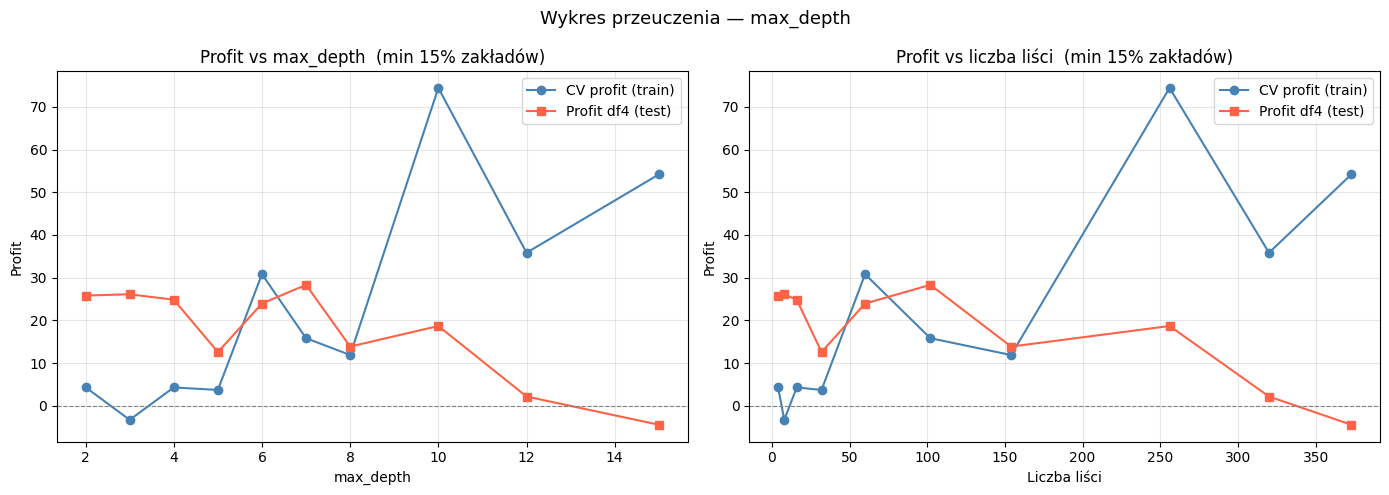

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRAFIKA 1 — CV profit vs df4 profit dla różnych max_depth
# ═══════════════════════════════════════════════════════════════════════════════

depths    = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15]
MIN_PCT   = 0.15  # minimum 15% wszystkich meczów
min_bets_train = int(len(y_train)      * MIN_PCT)
min_bets_test  = int(len(df_test_ts)   * MIN_PCT)
results_d = []

def best_threshold_with_min_bets(model, X, y_df, min_bets, is_test=False):
    """Zwraca najlepszy threshold z ograniczeniem min_bets zakładów."""
    proba = model.predict_proba(X)
    conf  = proba.max(axis=1)
    pred  = model.classes_[proba.argmax(axis=1)]

    best_profit = -np.inf
    best_t      = None
    best_placed = 0

    for t in np.arange(0.30, 0.96, 0.02):  # krok co 0.02
        t = round(t, 2)
        profits = []
        for i in range(len(X)):
            if conf[i] < t:
                continue
            p       = pred[i]
            true    = y_df.iloc[i][TARGET_W] if is_test else None
            bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[p]
            odds    = X.iloc[i][bet_col]
            if is_test:
                profits.append((odds - 1) if p == true else -1)
            else:
                profits.append(odds)  # placeholder — liczymy tylko ile zakładów

        if len(profits) < min_bets:
            continue

        profit = sum(profits) if is_test else len(profits)
        if is_test and profit > best_profit:
            best_profit = profit
            best_t      = t
            best_placed = len(profits)

    return best_t, best_profit, best_placed


for depth in depths:
    m = BettingTreeClassifier(feature_cols=feature_cols_with_bets,
                               max_depth=depth, min_samples_leaf=20, random_state=42)

    # szukaj najlepszego threshold z min_bets
    best_cv_profit = -np.inf
    best_t_for_depth = BEST_TS_THRESHOLD

    for t_cand in np.arange(0.50, 0.96, 0.02): # testowane od 0.3 ale nigdy nie zbierało tych wyników to zmniejszam zasięg
        t_cand = round(t_cand, 2)
        scores = cross_val_score(m, X_train_full, y_train, cv=cv,
                                  scoring=make_winner_scorer_minbets(t_cand, min_bets_train))
        valid  = scores[~np.isnan(scores)]
        if len(valid) < 3:  # min 3 z 5 foldów muszą mieć zakłady
            continue
        cv_sum = np.nansum(scores)
        if cv_sum > best_cv_profit:
            best_cv_profit   = cv_sum
            best_t_for_depth = t_cand

    # df4 profit przy tym samym threshold
    m.fit(X_train_full, y_train)
    proba_d  = m.predict_proba(X_test_full)
    conf_d   = proba_d.max(axis=1)
    pred_d   = m.classes_[proba_d.argmax(axis=1)]
    n_leaves = m.clf_.get_n_leaves()

    profits_test = []
    for i in range(len(df_test_ts)):
        if conf_d[i] < best_t_for_depth:
            continue
        pred    = pred_d[i]
        true    = df_test_ts.iloc[i][TARGET_W]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = df_test_ts.iloc[i][bet_col]
        profits_test.append((odds - 1) if pred == true else -1)

    # sprawdź min_bets na test
    test_profit = sum(profits_test) if len(profits_test) > 0 else 0

    results_d.append({
        'depth': depth, 'cv': best_cv_profit,
        'test': test_profit, 'leaves': n_leaves,
        'threshold': best_t_for_depth,
        'placed_test': len(profits_test)
    })
    print(f"depth={depth:>3} | leaves={n_leaves:>5} | t={best_t_for_depth:.2f} "
          f"| CV={best_cv_profit:>8.2f} | df4={test_profit if not np.isnan(test_profit) else 'za mało':>8}")

# wykres
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

depths_x = [r['depth']  for r in results_d]
cv_y     = [r['cv']     for r in results_d]
test_y   = [r['test']   for r in results_d]
leaves_x = [r['leaves'] for r in results_d]

ax1.plot(depths_x, cv_y,   marker='o', color='steelblue', label='CV profit (train)')
ax1.plot(depths_x, test_y, marker='s', color='tomato',    label='Profit df4 (test)')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_xlabel('max_depth')
ax1.set_ylabel('Profit')
ax1.set_title(f'Profit vs max_depth  (min {MIN_PCT*100:.0f}% zakładów)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(leaves_x, cv_y,   marker='o', color='steelblue', label='CV profit (train)')
ax2.plot(leaves_x, test_y, marker='s', color='tomato',    label='Profit df4 (test)')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_xlabel('Liczba liści')
ax2.set_ylabel('Profit')
ax2.set_title(f'Profit vs liczba liści  (min {MIN_PCT*100:.0f}% zakładów)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Wykres przeuczenia — max_depth', fontsize=13)
plt.tight_layout()
plt.savefig("overfit_depth.png", dpi=150)
plt.show()

leaf=   5 | leaves=   16 | t=0.56 | CV=    7.53 | df4=22.83582799145298 | zakładów=985
leaf=  10 | leaves=   16 | t=0.56 | CV=    5.38 | df4=24.835827991452973 | zakładów=983
leaf=  15 | leaves=   16 | t=0.56 | CV=    5.29 | df4=24.835827991452973 | zakładów=983
leaf=  20 | leaves=   16 | t=0.56 | CV=    4.29 | df4=24.835827991452973 | zakładów=983
leaf=  30 | leaves=   16 | t=0.56 | CV=    7.37 | df4=24.835827991452973 | zakładów=983
leaf=  40 | leaves=   16 | t=0.64 | CV=    5.21 | df4=24.835827991452973 | zakładów=746
leaf=  50 | leaves=   16 | t=0.56 | CV=    5.86 | df4=24.835827991452973 | zakładów=983
leaf=  75 | leaves=   16 | t=0.56 | CV=    9.50 | df4=24.835827991452973 | zakładów=983
leaf= 100 | leaves=   16 | t=0.56 | CV=   16.14 | df4=33.850827991452995 | zakładów=961
leaf= 150 | leaves=   16 | t=0.66 | CV=    7.53 | df4=11.131597222222226 | zakładów=436


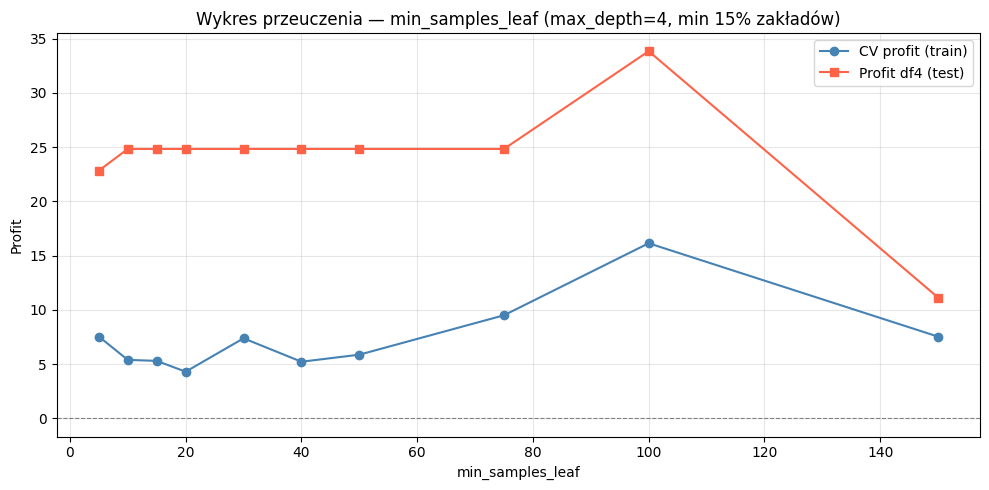

In [22]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRAFIKA 2 — CV profit vs df4 profit dla różnych min_samples_leaf
# ═══════════════════════════════════════════════════════════════════════════════

leaf_sizes = [5, 10, 15, 20, 30, 40, 50, 75, 100, 150]
results_l  = []

for leaf in leaf_sizes:
    m = BettingTreeClassifier(feature_cols=feature_cols_with_bets,
                               max_depth=4, min_samples_leaf=leaf, random_state=42)

    # szukaj najlepszego threshold z min_bets
    best_cv_profit   = -np.inf
    best_t_for_leaf  = BEST_TS_THRESHOLD

    for t_cand in np.arange(0.30, 0.96, 0.02):
        t_cand = round(t_cand, 2)
        scores = cross_val_score(m, X_train_full, y_train, cv=cv,
                                  scoring=make_winner_scorer_minbets(t_cand, min_bets_train))
        valid  = scores[~np.isnan(scores)]
        if len(valid) < 3:
            continue
        cv_sum = np.nansum(scores)
        if cv_sum > best_cv_profit:
            best_cv_profit  = cv_sum
            best_t_for_leaf = t_cand

    # df4 przy najlepszym threshold
    m.fit(X_train_full, y_train)
    proba_l  = m.predict_proba(X_test_full)
    conf_l   = proba_l.max(axis=1)
    pred_l   = m.classes_[proba_l.argmax(axis=1)]
    n_leaves = m.clf_.get_n_leaves()

    profits_test = []
    for i in range(len(df_test_ts)):
        if conf_l[i] < best_t_for_leaf:
            continue
        pred    = pred_l[i]
        true    = df_test_ts.iloc[i][TARGET_W]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = df_test_ts.iloc[i][bet_col]
        profits_test.append((odds - 1) if pred == true else -1)

    test_profit = sum(profits_test) if len(profits_test) > 0 else 0

    results_l.append({
        'leaf':       leaf,
        'cv':         best_cv_profit,
        'test':       test_profit,
        'leaves':     n_leaves,
        'threshold':  best_t_for_leaf,
        'placed_test': len(profits_test)
    })
    print(f"leaf={leaf:>4} | leaves={n_leaves:>5} | t={best_t_for_leaf:.2f} "
          f"| CV={best_cv_profit:>8.2f} | df4={test_profit if not np.isnan(test_profit) else 'za mało':>8} "
          f"| zakładów={len(profits_test)}")

# wykres
fig, ax = plt.subplots(figsize=(10, 5))

leaf_x   = [r['leaf'] for r in results_l]
cv_y     = [r['cv']   for r in results_l]
test_y   = [r['test'] for r in results_l]

ax.plot(leaf_x, cv_y,   marker='o', color='steelblue', label='CV profit (train)')
ax.plot(leaf_x, test_y, marker='s', color='tomato',    label='Profit df4 (test)')
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# oznacz punkty gdzie test był za mało zakładów
for r in results_l:
    if np.isnan(r['test']):
        ax.axvline(r['leaf'], color='orange', linestyle=':', alpha=0.5)

ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Profit')
ax.set_title(f'Wykres przeuczenia — min_samples_leaf (max_depth=4, min {MIN_PCT*100:.0f}% zakładów)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("overfit_leaf.png", dpi=150)
plt.show()

depth=  1 | leaves=    2 | train=0.495 | CV=0.492 | test=0.497 | profit=   0.00 | zakł=0
depth=  2 | leaves=    4 | train=0.495 | CV=0.493 | test=0.497 | profit=   0.00 | zakł=0
depth=  3 | leaves=    8 | train=0.505 | CV=0.501 | test=0.501 | profit=   0.00 | zakł=0
depth=  4 | leaves=   16 | train=0.506 | CV=0.497 | test=0.501 | profit=  -6.56 | zakł=35
depth=  5 | leaves=   31 | train=0.518 | CV=0.494 | test=0.498 | profit=  -7.89 | zakł=57
depth=  6 | leaves=   60 | train=0.531 | CV=0.484 | test=0.491 | profit= -14.28 | zakł=171
depth=  7 | leaves=  110 | train=0.549 | CV=0.474 | test=0.487 | profit=   6.97 | zakł=477
depth=  8 | leaves=  177 | train=0.570 | CV=0.463 | test=0.454 | profit= -39.83 | zakł=330
depth=  9 | leaves=  264 | train=0.595 | CV=0.453 | test=0.415 | profit= -53.65 | zakł=599
depth= 10 | leaves=  375 | train=0.635 | CV=0.441 | test=0.424 | profit= -24.01 | zakł=1098
depth= 11 | leaves=  501 | train=0.670 | CV=0.436 | test=0.398 | profit= -40.48 | zakł=1204
depth

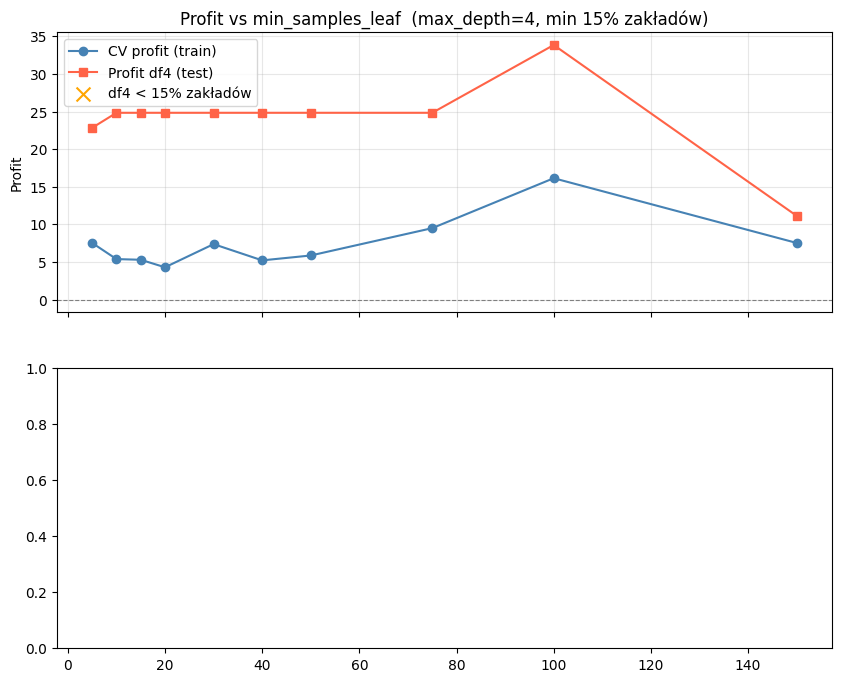

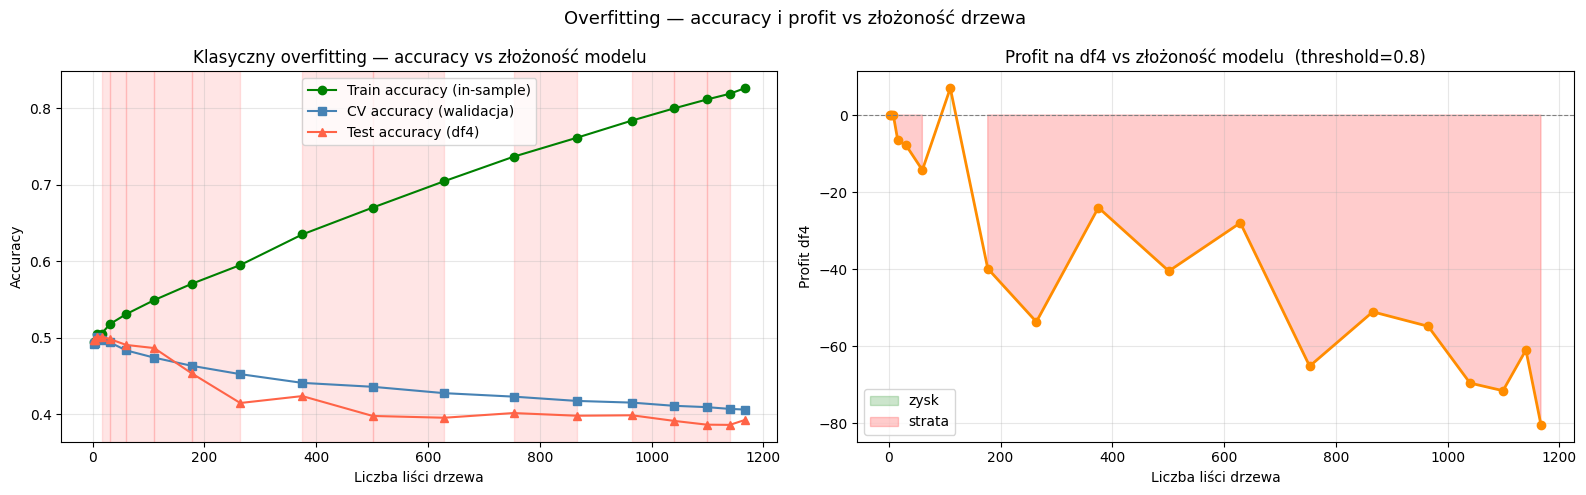

<Figure size 640x480 with 0 Axes>

In [23]:
# wykres — z obsługą nan
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

leaf_x = [r['leaf'] for r in results_l]
cv_y   = [r['cv']   for r in results_l]
test_y = [r['test'] for r in results_l]

# górny — profit
ax1.plot(leaf_x, cv_y, marker='o', color='steelblue', label='CV profit (train)')

# df4 — rozdziel na validne i nan
test_valid_x = [r['leaf'] for r in results_l if not np.isnan(r['test'])]
test_valid_y = [r['test'] for r in results_l if not np.isnan(r['test'])]
test_nan_x   = [r['leaf'] for r in results_l if np.isnan(r['test'])]

ax1.plot(test_valid_x, test_valid_y, marker='s', color='tomato', label='Profit df4 (test)')
ax1.scatter(test_nan_x, [0]*len(test_nan_x), marker='x', color='orange',
            s=100, zorder=5, label=f'df4 < {MIN_PCT*100:.0f}% zakładów')
ax1.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax1.set_ylabel('Profit')
ax1.set_title(f'Profit vs min_samples_leaf  (max_depth=4, min {MIN_PCT*100:.0f}% zakładów)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# dolny — liczba zakładów# ═══════════════════════════════════════════════════════════════════════════════
# GRAFIKA 2b — klasyczny overfitting: accuracy CV vs df4 dla rosnącego max_depth
# używamy accuracy zamiast profit żeby uniknąć szumu kursów
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.metrics import accuracy_score

depths_fine = list(range(1, 20))  # 1 do 19
FIXED_T     = BEST_TS_THRESHOLD   # stały threshold — nie optymalizowany per iteracja
results_acc = []

for depth in depths_fine:
    m = BettingTreeClassifier(feature_cols=feature_cols_with_bets,
                               max_depth=depth, min_samples_leaf=5, random_state=42)

    # CV accuracy (bez threshold — czysta miara przeuczenia)
    cv_acc = cross_val_score(m, X_train_full, y_train, cv=cv, scoring='accuracy')

    # train accuracy (in-sample)
    m.fit(X_train_full, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train_full))

    # df4 accuracy
    test_acc  = accuracy_score(y_test, m.predict(X_test_full))
    n_leaves  = m.clf_.get_n_leaves()

    # profit przy stałym threshold
    proba_d  = m.predict_proba(X_test_full)
    conf_d   = proba_d.max(axis=1)
    pred_d   = m.classes_[proba_d.argmax(axis=1)]

    profits_test = []
    for i in range(len(df_test_ts)):
        if conf_d[i] < FIXED_T:
            continue
        pred    = pred_d[i]
        true    = df_test_ts.iloc[i][TARGET_W]
        bet_col = {1: 'bet_1', 0: 'bet_x', 2: 'bet_2'}[pred]
        odds    = df_test_ts.iloc[i][bet_col]
        profits_test.append((odds - 1) if pred == true else -1)

    results_acc.append({
        'depth':     depth,
        'leaves':    n_leaves,
        'train_acc': train_acc,
        'cv_acc':    cv_acc.mean(),
        'test_acc':  test_acc,
        'test_profit': sum(profits_test) if profits_test else 0,
        'placed':    len(profits_test),
    })
    print(f"depth={depth:>3} | leaves={n_leaves:>5} | "
          f"train={train_acc:.3f} | CV={cv_acc.mean():.3f} | test={test_acc:.3f} | "
          f"profit={sum(profits_test) if profits_test else 0:>7.2f} | zakł={len(profits_test)}")

# ── WYKRES ────────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

leaves_x   = [r['leaves']    for r in results_acc]
train_acc  = [r['train_acc'] for r in results_acc]
cv_acc     = [r['cv_acc']    for r in results_acc]
test_acc   = [r['test_acc']  for r in results_acc]
profits    = [r['test_profit'] for r in results_acc]

# lewy — klasyczny wykres overfitting (accuracy)
ax1.plot(leaves_x, train_acc, marker='o', color='green',
         label='Train accuracy (in-sample)')
ax1.plot(leaves_x, cv_acc,    marker='s', color='steelblue',
         label='CV accuracy (walidacja)')
ax1.plot(leaves_x, test_acc,  marker='^', color='tomato',
         label='Test accuracy (df4)')

# zaznacz strefę overfittingu — gdzie train rośnie a test spada
for i in range(1, len(results_acc)):
    if (train_acc[i] > train_acc[i-1] and test_acc[i] < test_acc[i-1]):
        ax1.axvspan(leaves_x[i-1], leaves_x[i], alpha=0.1, color='red')

ax1.set_xlabel('Liczba liści drzewa')
ax1.set_ylabel('Accuracy')
ax1.set_title('Klasyczny overfitting — accuracy vs złożoność modelu')
ax1.legend()
ax1.grid(True, alpha=0.3)

# prawy — profit na df4 vs złożoność
ax2.plot(leaves_x, profits, marker='o', color='darkorange', linewidth=2)
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.fill_between(leaves_x, profits, 0,
                  where=[p > 0 for p in profits],
                  alpha=0.2, color='green', label='zysk')
ax2.fill_between(leaves_x, profits, 0,
                  where=[p <= 0 for p in profits],
                  alpha=0.2, color='red', label='strata')
ax2.set_xlabel('Liczba liści drzewa')
ax2.set_ylabel('Profit df4')
ax2.set_title(f'Profit na df4 vs złożoność modelu  (threshold={FIXED_T})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Overfitting — accuracy i profit vs złożoność drzewa', fontsize=13)
plt.tight_layout()
plt.savefig("overfit_classic.png", dpi=150)
plt.show()
placed_y    = [r['placed_test'] for r in results_l]
threshold_y = [r['threshold']   for r in results_l]

ax2b = ax2.twinx()  # druga oś Y dla threshold
ax2.bar(leaf_x, placed_y, width=4, color='steelblue', alpha=0.4, label='Zakłady df4')
ax2.axhline(min_bets_test, color='orange', linestyle='--',
            linewidth=1.5, label=f'min {MIN_PCT*100:.0f}% ({min_bets_test})')
ax2b.plot(leaf_x, threshold_y, marker='^', color='green',
          linewidth=1.5, label='Użyty threshold')
ax2.set_xlabel('min_samples_leaf')
ax2.set_ylabel('Liczba zakładów')
ax2b.set_ylabel('Threshold', color='green')
ax2b.tick_params(axis='y', labelcolor='green')

# połącz legendy obu osi
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("overfit_leaf.png", dpi=150)
plt.show()